---
numbering: false
---

# 2.9. Inverses

The big concept introduced in [Chapter 2.8](./rank) was the **rank** of a matrix, $\text{rank}(A)$, which is the number of linearly independent columns of a matrix. The rank of a matrix told us the dimension of its column space, $\text{colsp}(A)$, which is the set of all vectors that can be created with linear combinations of $A$'s columns. 

The ideas of rank, column space, and linear independence are all closely related, and also all apply for matrices of any shape – wide, tall, or square. This is good, because data from the real world is rarely square: we usually have many more observations ($n$) than features ($d$).

The big idea in Chapter 2.9 is that of the **inverse** of a matrix, $A^{-1}$, which **only applies to square matrices**. But, inverses and square matrices can still be useful for our rectangular matrices with real data, since the matrix $A^TA$ is square, no matter the shape of $A$. And, as we discussed in [Chapter 2.8](./rank) and you're seeing in Homework 5, the matrix $A^TA$ has close ties to the correlations between the columns of $A$, which you already know has some connection to linear regression.

---

## Motivation: What is an Inverse?

### Scalar Addition and Multiplication

In "regular" addition and multiplication, you're already familiar with the idea of an inverse. In addition, the inverse of a number $a$ is another number $a'$ that satisfies

$$a + a' = a' + a = 0$$

0 is the "identity" element in addition, since adding it to any number $a$ doesn't change the value of $a$. Of course, $a' = -a$, so $-a$ is the **additive inverse** of $a$. Any number $a$ has an additive inverse; for example, the additive inverse of $2$ is $-2$, and the additive inverse of $-2$ is $2$.

In multiplication, the inverse of a number $a$ is another number $a'$ that satisfies

$$a \cdot a' = a' \cdot a = 1$$

1 is the "identity" element in multiplication, since multiplying it by any number $a$ doesn't change the value of $a$. Most numbers have a **multiplicative inverse** of $a' = \frac{1}{a}$, but 0 does not!

$$0 \cdot a' = 0$$

is not achieved by any $a'$.

When a multiplicative inverse exists, we can use it to solve equations like

$$2x = 5$$

by multiplying both sides by the multiplicative inverse of $2$, which is $\frac{1}{2}$.

$$\frac{1}{2} (2x) = \frac{1}{2} (5) \implies x = \frac{5}{2}$$

### Matrices

If $A$ is an $n \times d$ matrix, its additive inverse is just $-A$, which comes from negating each element of $A$. That part is not all that interesting. What we're more interested in is the **multiplicative inverse** of a matrix, which is just referred to as the **inverse** of the matrix.

Suppose $A$ is some $n \times d$ matrix. We'd like to find an inverse, $A'$, such that when $A$ is multiplied by $A'$ **in any order**, the result is the identity element for matrix multiplication, $I$. Recall, the $n \times n$ identity matrix is a matrix with 1s on the diagonal (moving from the top left to the bottom right), and 0s everywhere else. The $3 \times 3$ identity matrix is

$$I_3 = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

$I_3 \vec x = \vec x$ for any $\vec x \in \mathbb{R}^3$, and $B I_3 = I_3 B = B$ for any $B \in \mathbb{R}^{3 \times 3}$.

$$\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} = \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix}$$

If $A$ is an $n \times d$ matrix, we'd need a single matrix $A'$ that satisfies

$$AA' = A'A = I$$

In $AA'$, $A'$ is the **right inverse** of $A$, and in $A'A$, $A'$ is the **left inverse** of $A$. Right now, we're interested in finding matrices that have both a left and right inverse, that happen to be the same matrix.

In order to evaluate $AA'$, we'd need $A'$ to be of shape $d \times \text{something}$, and in order to evaluate $A'A$, we'd need $A'$ to be of shape $\text{something else} \times n$. The solution to these constraints is to have $A'$ be a $d \times n$ matrix (like $A^T$).

If we try that, then
- $A'A$ has shape $(d \times n) \cdot (n \times d) = d \times d$
- $AA'$ has shape $(n \times d) \cdot (d \times n) = n \times n$

but, we want $A'A$ and $AA'$ to both be **the same matrix**, not just separate valid matrices. So, we need $n = d$, which requires $A$ to be $n \times n$, like its inverse.

:::{attention} Only square matrices have inverses!
The idea of invertibility only makes sense for square matrices. 

Non-square matrices can have left or right inverses, which we'll discuss in Chapter 2.10, but in general they can't be "invertible".
:::

For example, consider the $2 \times 2$ matrix

$$A = \begin{bmatrix} 2 & 4 \\ 3 & 5\end{bmatrix}$$

It turns out that $A$ does have an inverse! Its inverse, denoted by $A^{-1}$, is

$$A^{-1} = \begin{bmatrix} -5/2 & 2 \\ 3/2 & -1\end{bmatrix}$$

Because $A^{-1}$ is the matrix that satisfies **both**

$$AA^{-1} = \begin{bmatrix} 2 & 4 \\ 3 & 5\end{bmatrix} \begin{bmatrix} -5/2 & 2 \\ 3/2 & -1\end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1\end{bmatrix} = I$$

and

$$A^{-1}A = \begin{bmatrix} -5/2 & 2 \\ 3/2 & -1\end{bmatrix} \begin{bmatrix} 2 & 4 \\ 3 & 5\end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1\end{bmatrix} = I$$

`numpy` is good at finding inverses, when they exist.

In [ ]:
import numpy as np

A = np.array([[2, 4], 
              [3, 5]])
              
np.linalg.inv(A)

array([[-2.5,  2. ],
       [ 1.5, -1. ]])

In [ ]:
# The top-left and bottom-right elements are 1s, 
# and the top-right and bottom-left elements are 0s.
# 4.4408921e-16 is just 0, with some floating point error baked in.
A @ np.linalg.inv(A)

array([[1.0000000e+00, 0.0000000e+00],
       [4.4408921e-16, 1.0000000e+00]])

But, not all square matrices are invertible, just like not all numbers have multiplicative inverses. What happens if we try and invert

$$B = \begin{bmatrix} 1 & 2 \\ 2 & 4\end{bmatrix}$$

In [17]:
B = np.array([[1, 2], 
              [2, 4]])

np.linalg.inv(B)

LinAlgError: Singular matrix

We're told the matrix is **singular**, meaning that it's not invertible.

The point of Chapter 2.9 is to understand **why** some square matrices are invertible and others are not, and what the inverse of an invertible matrix really means.

### What's the Point?

In general, suppose $A$ is an $n \times d$ matrix and $\vec b \in \mathbb{R}^n$. Then, the equation

$$A \vec x = \vec b$$

is a system of $n$ equations in $d$ unknowns. 

$$\underbrace{\begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1d} \\ a_{21} & a_{22} & \cdots & a_{2d} \\ \vdots & \vdots & \ddots & \vdots \\ a_{n1} & a_{n2} & \cdots & a_{nd} \end{bmatrix}}_{A} \underbrace{\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_d \end{bmatrix}}_{\vec x} = \underbrace{\begin{bmatrix} b_1 \\ b_2 \\ \vdots \\ b_n \end{bmatrix}}_{\vec b}$$

There may be no solution, a unique solution, or infinitely many solutions for the vector $\vec x$ that satisfies the system, depending on $\text{rank}(A)$ and whether $\vec b$ is in $\text{colsp}(A)$.

If we assume $A$ is square, i.e. $n = d$, then $A \vec x = \vec b$ is a system of $n$ equations in $n$ unknowns. If $A$ is invertible (which, remember, only square matrices can be), then there is a unique solution to the system, and we can find it by multiplying both sides by $A^{-1}$ on the left.

$$A \vec x = \vec b \implies A^{-1} A \vec x = A^{-1} \vec b \implies \vec x = A^{-1} \vec b$$

$\vec x = A^{-1} \vec b$ is the unique solution to the system of equations, and we can find it without having to manually solve the system. Thinking back to the example above, we used `numpy` to find that the inverse of


$$A = \begin{bmatrix} 2 & 4 \\ 3 & 5\end{bmatrix}$$

is

$$A^{-1} = \begin{bmatrix} -5/2 & 2 \\ 3/2 & -1\end{bmatrix}$$

We can use $A^{-1}$ to solve the system

$$\begin{align*} 2x_1 + 4x_2 &= b_1 \\ 3x_1 + 5x_2 &= b_2 \end{align*}$$

For any $b_1, b_2 \in \mathbb{R}$, the unique solution for $x_1$ and $x_2$ is

$$\begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} -5/2 & 2 \\ 3/2 & -1\end{bmatrix} \begin{bmatrix} b_1 \\ b_2 \end{bmatrix} = \begin{bmatrix} -5/2 b_1 + 2 b_2 \\ 3/2 b_1 - b_2 \end{bmatrix}$$

That said, as we'll discuss at the bottom of this section, actually finding the inverse of a matrix is very computationally intensive, so usually we don't actually compute $A^{-1}$. Knowing that it exists, and understanding the properties it satisfies, is the important part.

---

## Linear Transformations

But first, I want us to think about matrix-vector multiplication as something more than just number crunching.

In [Chapter 2.8](./rank), the running example was the matrix

$$A = \begin{bmatrix} 5 & 3 & 2 \\ 0 & -1 & 1 \\ 3 & 4 & -1 \\ 6 & 2 & 4 \\ 1 & 0 & 1 \end{bmatrix}$$

To multiply $A$ by a vector on the right, that vector must be in $\mathbb{R}^3$, and the result will be a vector in $\mathbb{R}^5$.

Put another way, if we consider the function $T(\vec x) = A \vec x$, $T$ maps elements of $\mathbb{R}^3$ to elements of $\mathbb{R}^5$, i.e.

$$T: \mathbb{R}^3 \to \mathbb{R}^5$$

I've chosen the letter $T$ to denote that $T$ is a **linear transformation**.

:::{note} Definition: Linear Transformation
A function $T: \mathbb{R}^d \to \mathbb{R}^n$ is a **linear transformation** if for any $\vec x, \vec y \in \mathbb{R}^d$ and any $c \in \mathbb{R}$,

1. $T(\vec x + \vec y) = T(\vec x) + T(\vec y)$
2. $T(c \vec x) = c T(\vec x)$

$\mathbb{R}^d$ is the **domain** of $T$, and $\mathbb{R}^n$ is the **codomain** of $T$.
:::

Every linear transformation is of the form $T(\vec x) = A \vec x$. For our purposes, linear transformations and matrix-vector multiplication are the same thing, though in general linear transformations are a more abstract concept (just like how vector spaces can be made up of functions, for example).

For example, the function

$$f(\vec x) = f\left( \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} \right) = \begin{bmatrix} 2x_1 + 3x_2 \\ x_1 \\ x_2 \end{bmatrix}$$

is a linear transformation from $\mathbb{R}^2$ to $\mathbb{R}^3$, and is equivalent to

$$f(\vec x) = \begin{bmatrix} 2x_1 + 3x_2 \\ x_1 \\ x_2 \end{bmatrix} = \underbrace{\begin{bmatrix} 2 & 3 \\ 1 & 0 \\ 0 & 1 \end{bmatrix}}_{\text{matrix}\:  A} \underbrace{\begin{bmatrix} x_1 \\ x_2 \end{bmatrix}}_{\vec x}$$

The function $g(x) = 3x$ is also a linear transformation, from $\mathbb{R}$ to $\mathbb{R}$.

A non-example of a linear transformation is

$$h(\vec x) = \begin{bmatrix} x_1^2 \\ x_2^2 \end{bmatrix}$$

because no matrix multiplied by $\vec x$ will produce $\begin{bmatrix} x_1^2 \\ x_2^2 \end{bmatrix}$.

Another non-example, perhaps surprisingly, is

$$k(x) = -2x + 5$$

This is the equation of a line in $\mathbb{R}^2$, which is linear in some sense, but it's not a linear transformation, since it doesn't satisfy the two properties of linearity. For $k(x)$ to be a linear transformation, we'd need

$$k(cx) = ck(x)$$

for any $c, x \in \mathbb{R}$. But, if we consider $c = 3$ and $x = 1$ as an example, we get

$$k(cx) = k(3 \cdot 1) = k(3) = -2 \cdot 3 + 5 = -1 \\ ck(x) = 3 k(1) = 3 (-2 \cdot 1 + 5) = 3(3) = 9$$

which are not equal. $k(x) = -2x + 5$ is an example of an **affine transformation**, which in general is any function $f: \mathbb{R}^d \to \mathbb{R}^n$ that can be written as $f(\vec x) = A \vec x + \vec b$, where $A$ is an $n \times d$ matrix and $\vec b \in \mathbb{R}^n$.

:::{tip} Activity 1
:class: dropdown

**Activity 1.1**

True or false: if $T$ is a linear transformation, then $T(\vec 0) = \vec 0$.

**Activity 1.2**

For each of the following functions, determine whether it is a linear transformation. If it is, write it in the form $T(\vec x) = A \vec x$. If it is not, explain why not.

1. $T(\vec x) = \begin{bmatrix} x_1 + x_2 \\ x_1 - x_2 \end{bmatrix}$
1. $T(\vec x) = \begin{bmatrix} 3 x_3 - x_1 \\ x_2 + 2 x_3 \\ 5x_1 + 7x_2 \end{bmatrix}$
1. $T(\vec x) = \begin{bmatrix} 3x_3 - 5 \\ x_2 + 2 x_3 \\ 5x_1 + 7x_2 \end{bmatrix}$
1. $T(\vec x) = \vec x + \begin{bmatrix} 1 \\ 2 \end{bmatrix}$
1. $T$ takes $\vec x$, multiplies the first component by 2 and second component by 3, and returns the difference between the two, as a scalar.

:::{seealso} Solutions
:class: dropdown

**Activity 1.1**

True or false: if $T$ is a linear transformation, then $T(\vec 0) = \vec 0$.

True. Since $T$ is a linear transformation, we have

$$T(c \vec x) = c T(\vec x)$$

for any $c \in \mathbb{R}$ and $\vec x \in \mathbb{R}^d$. Plugging in $c = 0$, we get

$$T(0 \vec x) = 0 T(\vec x) \implies T(\vec 0) = \vec 0$$

**Activity 1.2**

1. $T(\vec x) = \begin{bmatrix} x_1 + x_2 \\ x_1 - x_2 \end{bmatrix}$ **is** a linear transformation.
    $$T(\vec x) = \begin{bmatrix} x_1 + x_2 \\ x_1 - x_2 \end{bmatrix} = \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$$

2. $T(\vec x) = \begin{bmatrix} 3 x_3 - x_1 \\ x_2 + 2 x_3 \\ 5x_1 + 7x_2 \end{bmatrix}$ **is** a linear transformation.
    $$T(\vec x) = \begin{bmatrix} 3 x_3 - x_1 \\ x_2 + 2 x_3 \\ 5x_1 + 7x_2 \end{bmatrix} = \begin{bmatrix} -1 & 0 & 3 \\ 0 & 1 & 2 \\ 5 & 7 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix}$$

3. $T(\vec x) = \begin{bmatrix} 3x_3 - 5 \\ x_2 + 2 x_3 \\ 5x_1 + 7x_2 \end{bmatrix}$ **is not** a linear transformation. Notice the constant term of $-5$ in the first component! This is instead an affine transformation.

4. $T(\vec x) = \vec x + \begin{bmatrix} 1 \\ 2 \end{bmatrix}$ is **not** a linear transformation once again; it's an affine transformation. If you don't believe that it's not a linear transformation, plug in both $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 2 \end{bmatrix}$; if $T$ were a linear transformation, the latter output would be exactly double the former output.

5. This description tells us that $T(\vec x) = 2x_1 - 3x_2$, and this **is** a perfectly valid linear transformation, from $\mathbb{R}^2$ to $\mathbb{R}$.
    $$T(\vec x) = \begin{bmatrix} 2 & -3 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$$
:::

### From $\mathbb{R}^n$ to $\mathbb{R}^n$

While linear transformations exist from $\mathbb{R}^2$ to $\mathbb{R}^5$ or $\mathbb{R}^{99}$ to $\mathbb{R}^4$, it's in some ways easiest to think about linear transformations with the same domain and codomain, i.e. transformations of the form $T: \mathbb{R}^n \to \mathbb{R}^n$. This will allow us to explore how transformations stretch, rotate, and reflect vectors in the same space. Linear transformations with the same domain ($\mathbb{R}^n$) and codomain ($\mathbb{R}^n$) are represented by $n \times n$ matrices, which gives us a useful setting to think about the invertibility of square matrices, beyond just looking at a bunch of numbers.

To start, let's consider the linear transformation defined by the matrix

$$A = \begin{bmatrix} 2 & 0 \\ 0 & -1/3 \end{bmatrix}$$

What happens to a vector in $\mathbb{R}^2$ when we multiply it by $A$? Let's visualize the effect of $A$ on several vectors in $\mathbb{R}^2$.

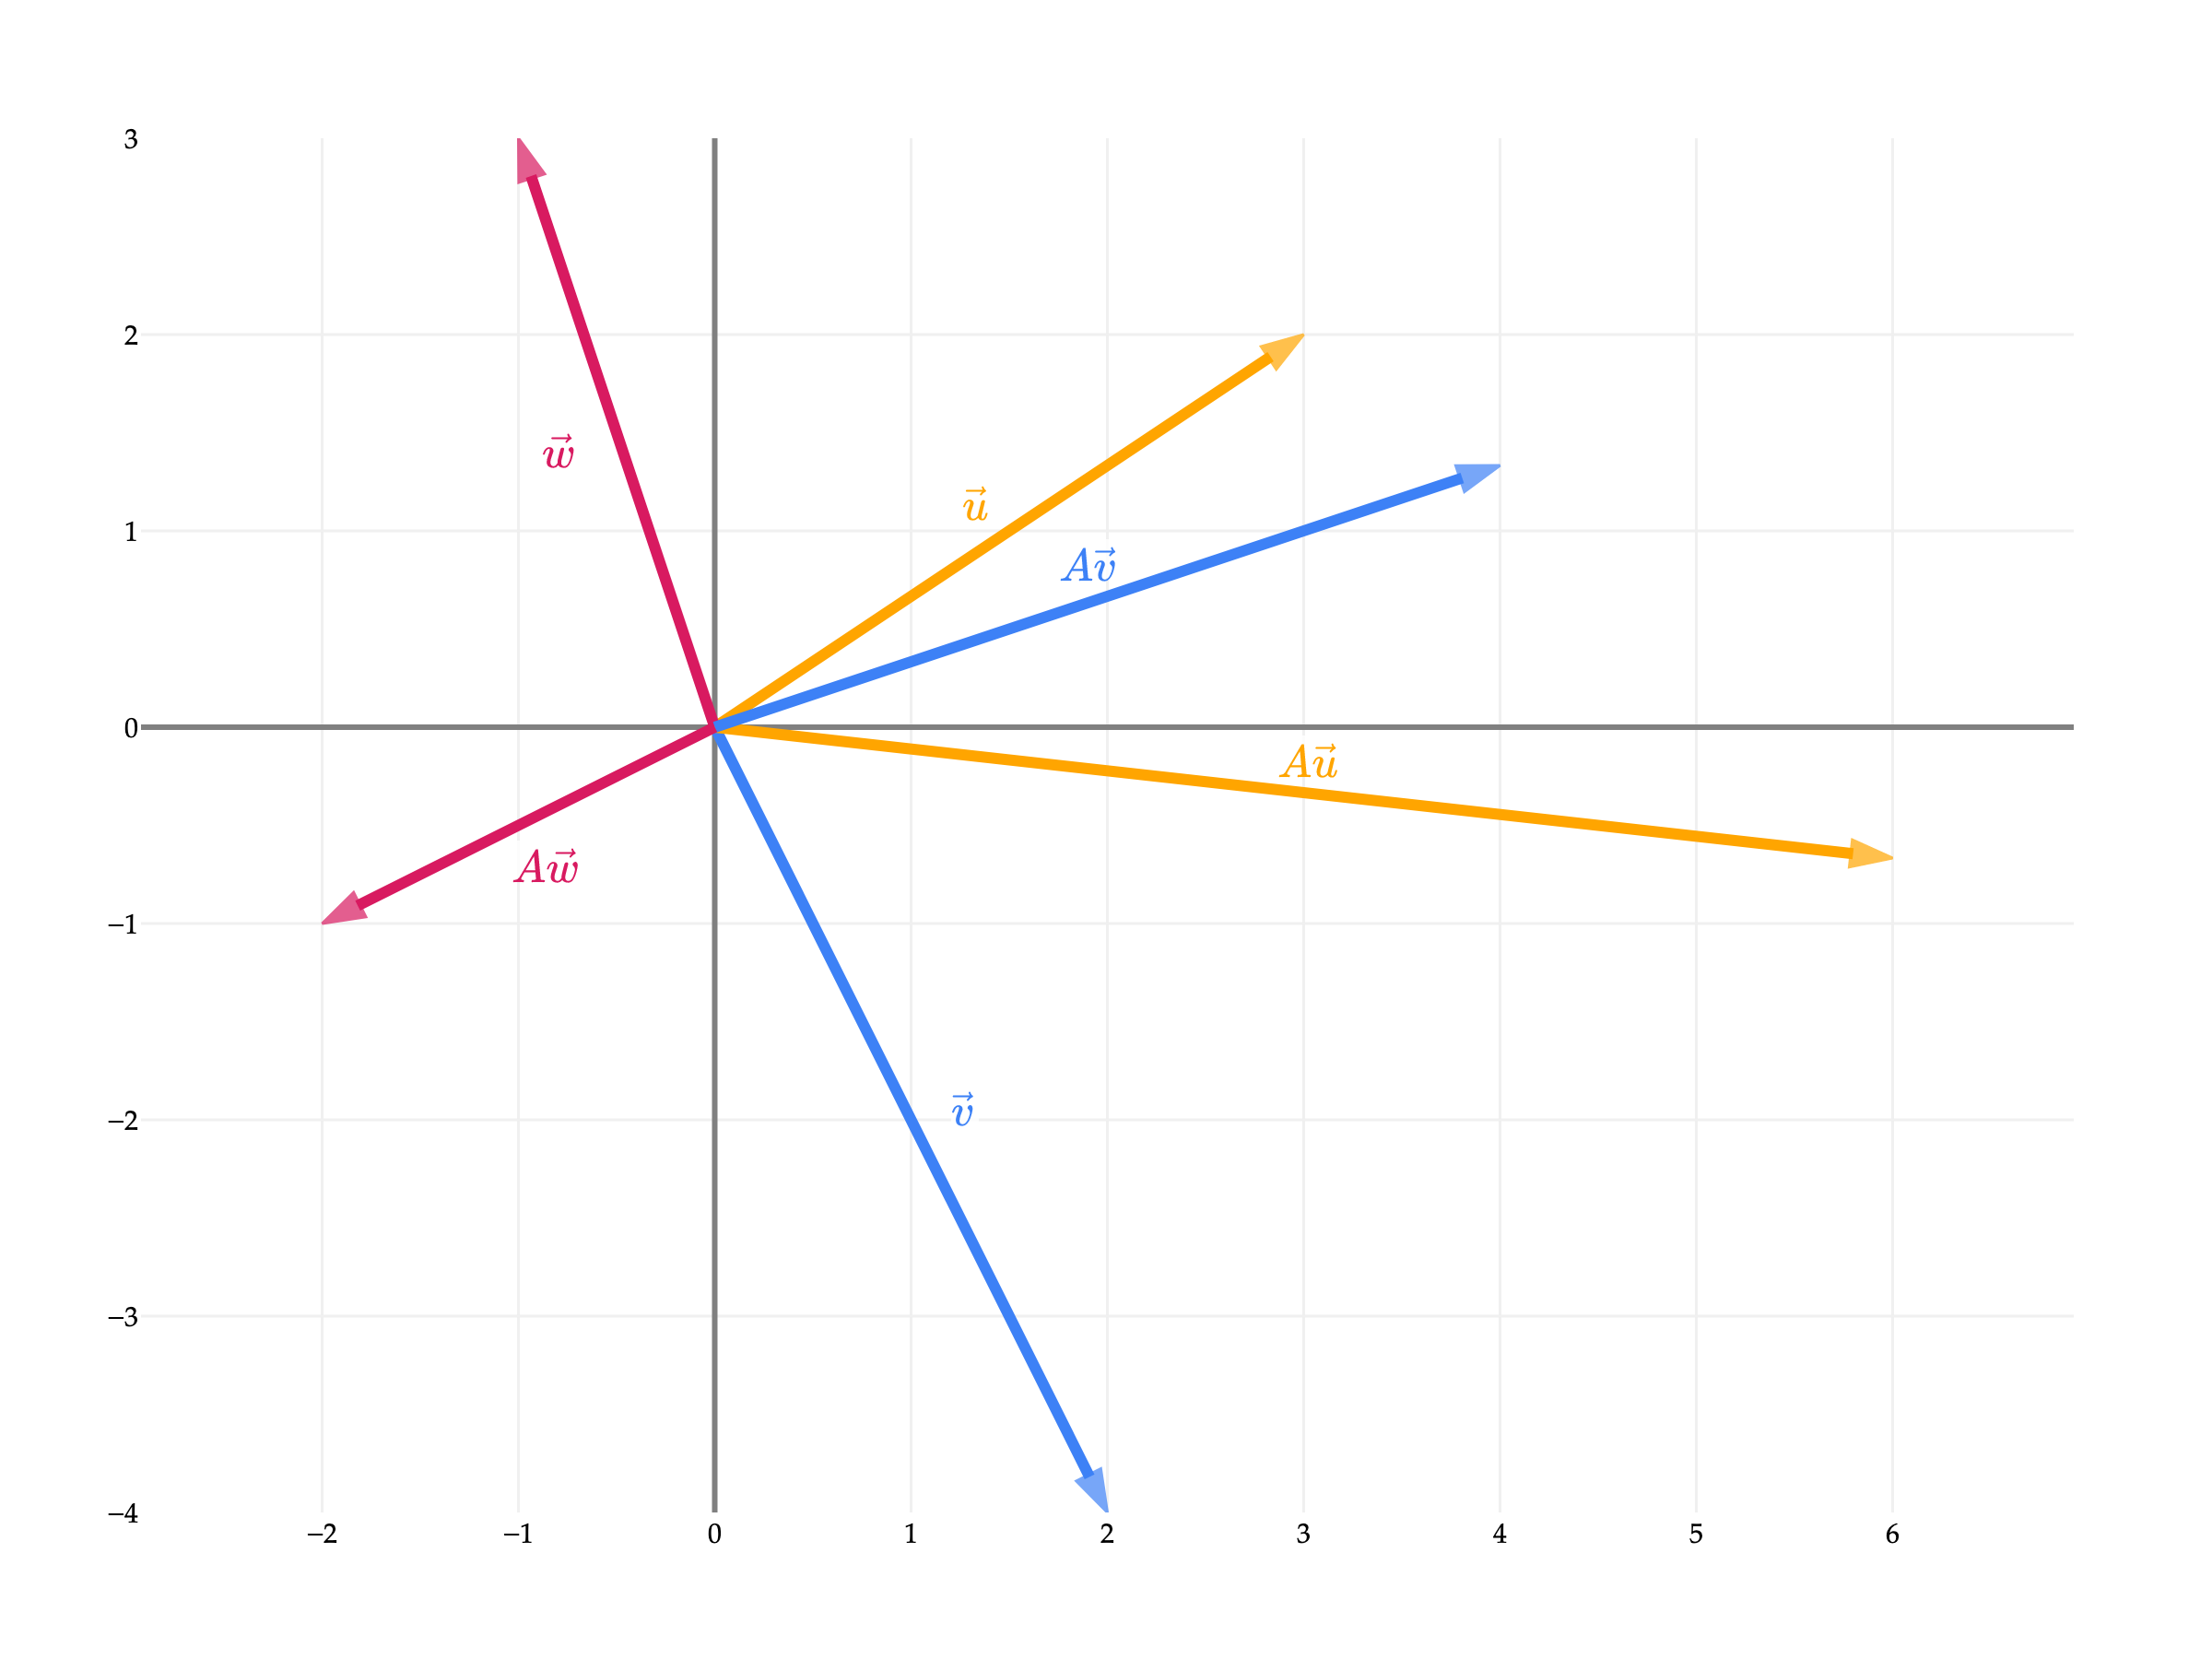

In [51]:
from utils import plot_vectors
import numpy as np

A = np.array([[2, 0], [0, - 1 / 3]])
u = np.array([3, 2])
v = np.array([2, -4])
w = np.array([-1, 3])

Au = A @ u
Av = A @ v
Aw = A @ w

fig = plot_vectors(
    [
        (tuple(u), 'orange', r'$\vec u$'),
        (tuple(v), '#3d81f6', r'$\vec v$'),
        (tuple(w), '#d81a60', r'$\vec w$'),
        (tuple(Au), 'orange', r'$A \vec u$'),
        (tuple(Av), '#3d81f6', r'$A \vec v$'),
        (tuple(Aw), '#d81a60', r'$A \vec w$')
    ],
    vdeltay=0.2
)

# Fix aspect ratio: set both axes to be equal using 'constrain'
fig.update_layout(
    xaxis=dict(range=[-2, 6], dtick=1),
    yaxis=dict(scaleanchor="x", range=[-4, 3], dtick=1)
)

fig.show(scale=3, renderer='png')

$A$ scales, or stretches, the input space by a factor of $2$ in the $x$-direction and a factor of $-1/3$ in the $y$-direction.

### Scaling

Another way of visualizing $A$ is to think about how it transforms the two standard basis vectors of $\mathbb{R}^2$, which are $${\color{#3d81f6}{\vec u_x = \begin{bmatrix} 1 \\ 0 \end{bmatrix}}}, \quad \color{#3d81f6}{\vec u_y = \begin{bmatrix} 0 \\ 1 \end{bmatrix}}$$ (In the past I've called these $\vec e_1$ and $\vec e_2$, but I'll use $\color{#3d81f6}{\vec u_x}$ and $\color{#3d81f6}{\vec u_y}$ here since I'll also use $E$ to represent a matrix shortly.)

Note that $\color{orange}{A \vec u_x} = \begin{bmatrix} 2 \\ 0 \end{bmatrix}$ is just the first column of $A$, and similarly $\color{orange}{A \vec u_y} = \begin{bmatrix} 0 \\ -1/3 \end{bmatrix}$ is the second column of $A$.

$$A = \begin{bmatrix} 2 & 0 \\ 0 & -1/3 \end{bmatrix}$$

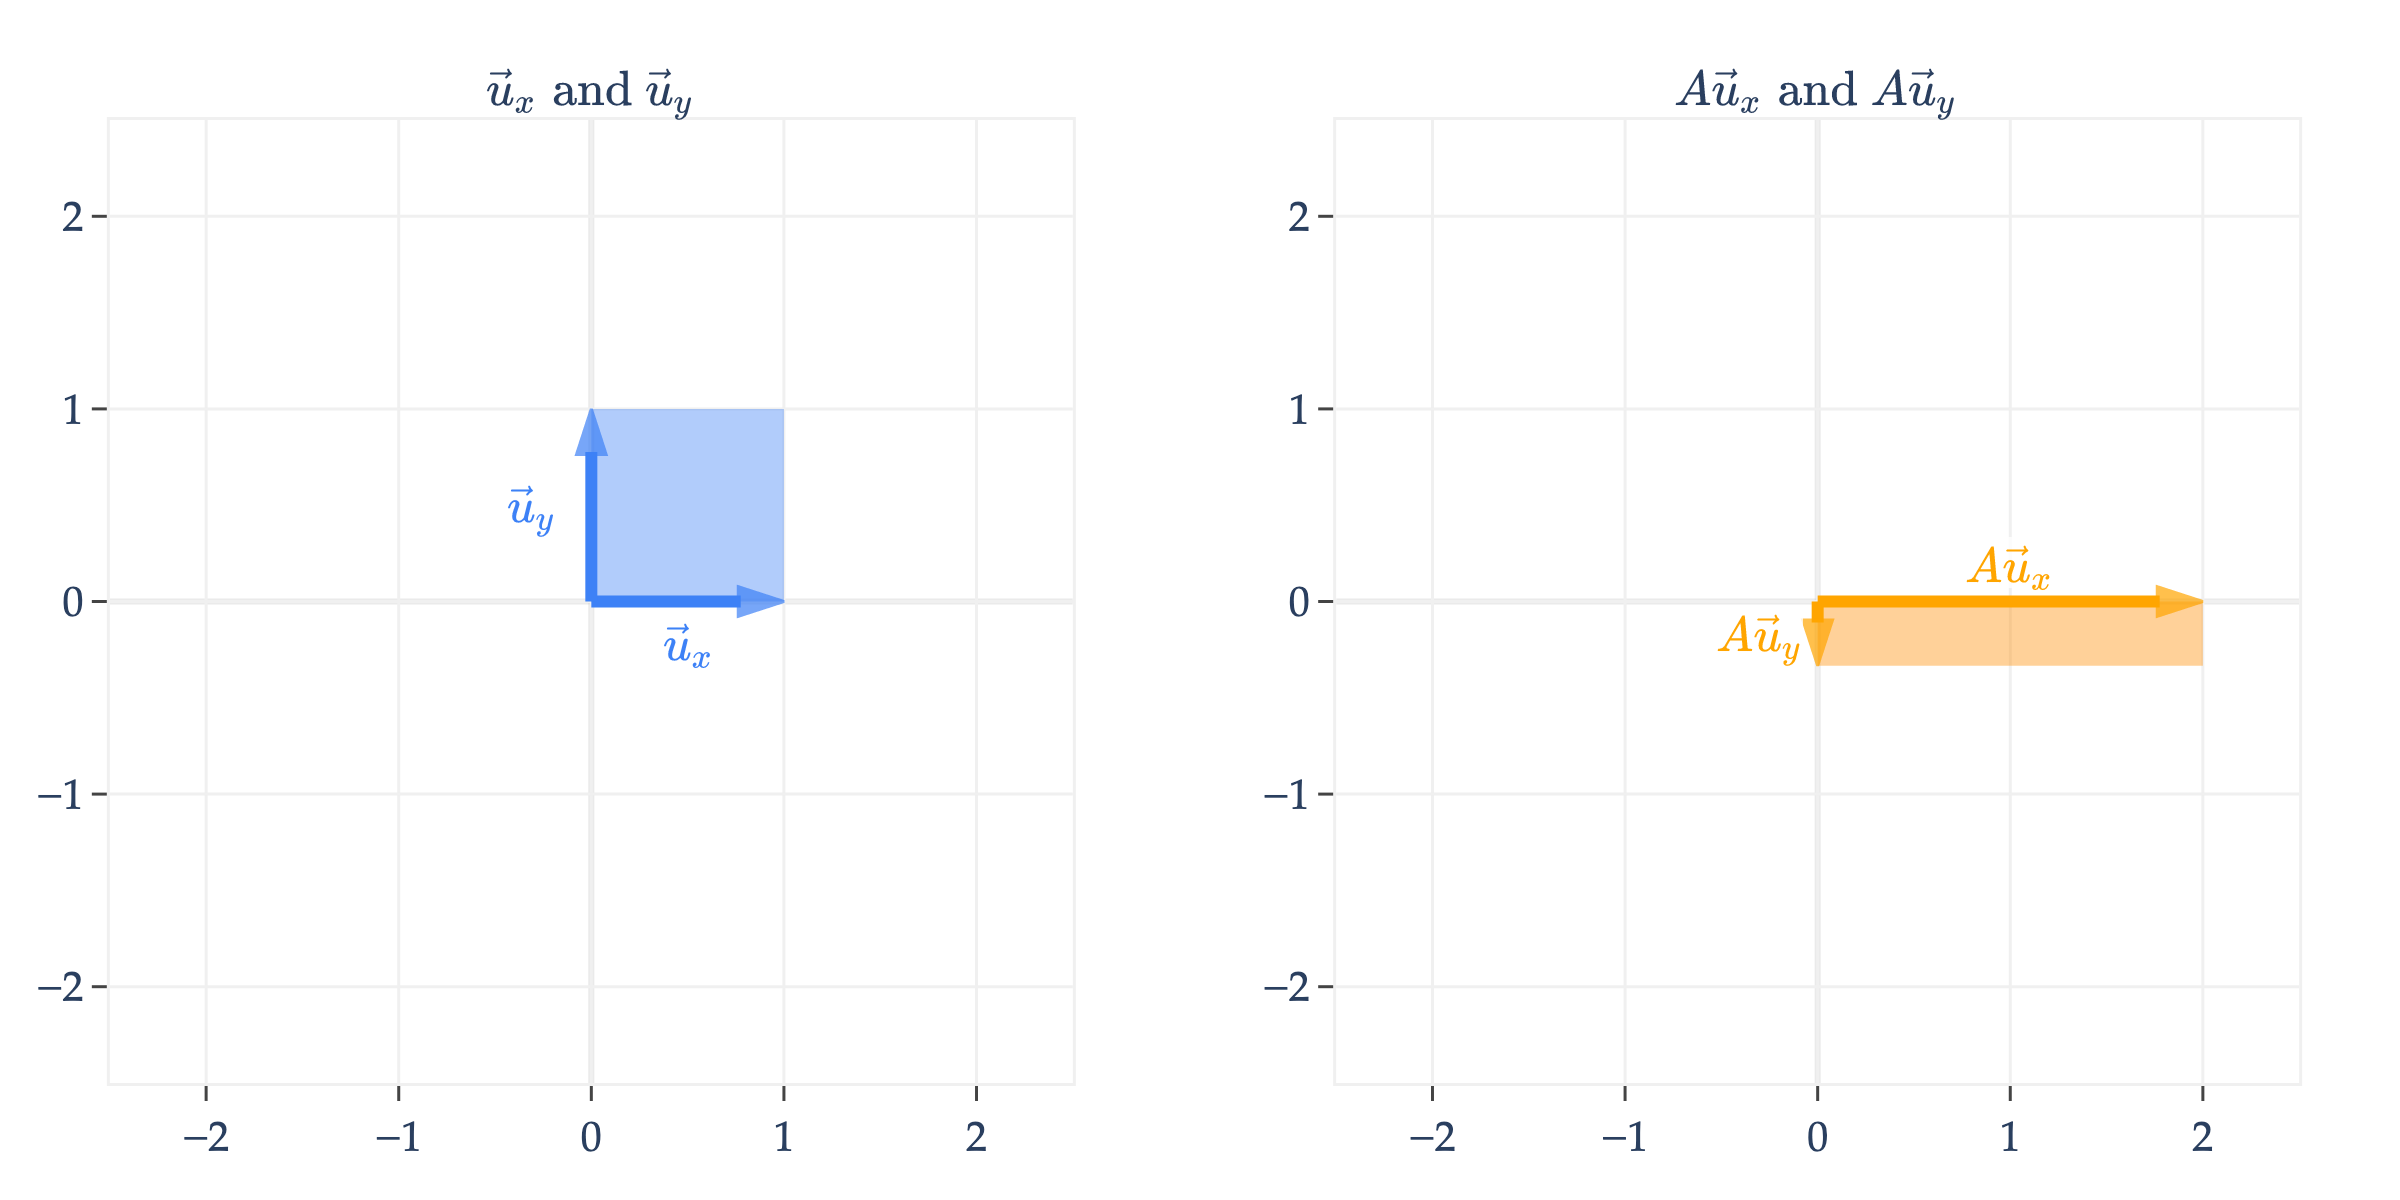

In [3]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from utils import plot_vectors

def plot_unit_square_and_transform(S, name="Matrix", vdeltax=-0.3, vdeltay=0.2, return_fig=False):
    # Vertices of the unit square
    square = np.array([
        [0, 0],  # A
        [1, 0],  # B
        [1, 1],  # C
        [0, 1],  # D
        [0, 0]   # A (to close the square)
    ])
    # Transformed square
    square_trans = (S @ square.T).T

    # Create subplot figure
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(r"$$\vec u_x \text{  and } \vec u_y$$", fr"$${name}" + r"\vec u_x \text{  and }" + fr"{name} \vec u_y$$"),
        horizontal_spacing=0.08
    )

    # Common axis settings
    axis_style = dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=False,  # We'll add our own zero lines
        showline=True,
        linecolor="#f0f0f0",
        mirror=True,
        ticks="outside",
        showticklabels=True,
        tickfont=dict(family="Palatino, serif", size=14),
    )

    # Set axis ranges to [-2.5, 2.5] for both subplots
    for i in [1, 2]:
        fig.update_xaxes(
            range=[-2.5, 2.5],
            constrain="domain",
            dtick=1,
            **axis_style,
            row=1, col=i
        )
        fig.update_yaxes(
            range=[-2.5, 2.5],
            scaleanchor=f"x{i}",
            dtick=1,
            **axis_style,
            row=1, col=i
        )

    # --- Draw faint 0 grid lines underneath everything else ---
    for i in [1, 2]:
        # Horizontal y=0
        fig.add_shape(
            type="line",
            x0=-2.5, x1=2.5, y0=0, y1=0,
            line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
            row=1, col=i,
            layer="below"
        )
        # Vertical x=0
        fig.add_shape(
            type="line",
            x0=0, x1=0, y0=-2.5, y1=2.5,
            line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
            row=1, col=i,
            layer="below"
        )

    # Plot original unit square (no perimeter, low opacity)
    fig.add_trace(
        go.Scatter(
            x=square[:,0], y=square[:,1],
            fill="toself",
            fillcolor="rgba(61,129,246,0.4)",
            line=dict(color="rgba(0,0,0,0)", width=0),  # No perimeter
            name="Unit Square",
            showlegend=False
        ),
        row=1, col=1
    )

    # Plot transformed square (no perimeter, low opacity)
    fig.add_trace(
        go.Scatter(
            x=square_trans[:,0], y=square_trans[:,1],
            fill="toself",
            fillcolor="rgba(255,140,0,0.4)",
            line=dict(color="rgba(0,0,0,0)", width=0),  # No perimeter
            name="Transformed Square",
            showlegend=False
        ),
        row=1, col=2
    )

    # --- Draw vectors using plot_vectors ---
    # Standard basis vectors
    u_x = np.array([1, 0])
    u_y = np.array([0, 1])
    # Transformed basis vectors
    Su_x = S @ u_x
    Su_y = S @ u_y

    # Left: u_x, u_y in #3d81f6
    left_vecs = [
        (tuple(u_x), '#3d81f6', r'$\vec u_x$'),
        (tuple(u_y), '#3d81f6', r'$\vec u_y$')
    ]
    left_fig = plot_vectors(left_vecs, vdeltay=-0.2)
    # Remove background, axes, and grid from plot_vectors output
    left_fig.update_layout(
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        margin=dict(l=0, r=0, t=0, b=0)
    )
    # Add the vector traces to the left subplot
    for trace in left_fig.data:
        fig.add_trace(trace, row=1, col=1)
    # Add the vector annotations to the left subplot
    for ann in left_fig.layout.annotations:
        # Convert Plotly Annotation object to dict safely
        if hasattr(ann, "to_plotly_json"):
            ann_dict = ann.to_plotly_json()
        else:
            ann_dict = dict(ann)
        # Remove keys that are not valid for add_annotation
        ann_dict = {k: v for k, v in ann_dict.items() if k not in {"xref", "yref", "axref", "ayref"}}
        fig.add_annotation(**ann_dict, row=1, col=1)

    # Right: Su_x, Su_y in orange, with correct labels
    right_vecs = [
        (tuple(Su_x), 'orange', rf'${name} \vec u_x$'),
        (tuple(Su_y), 'orange', rf'${name} \vec u_y$')
    ]
    right_fig = plot_vectors(right_vecs, vdeltax=vdeltax, vdeltay=vdeltay)
    right_fig.update_layout(
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        margin=dict(l=0, r=0, t=0, b=0)
    )
    for trace in right_fig.data:
        fig.add_trace(trace, row=1, col=2)
    for ann in right_fig.layout.annotations:
        # Convert Plotly Annotation object to dict safely
        if hasattr(ann, "to_plotly_json"):
            ann_dict = ann.to_plotly_json()
        else:
            ann_dict = dict(ann)
        # Remove keys that are not valid for add_annotation
        ann_dict = {k: v for k, v in ann_dict.items() if k not in {"xref", "yref", "axref", "ayref"}}
        fig.add_annotation(**ann_dict, row=1, col=2)

    fig.update_layout(
        font=dict(family="Palatino, serif", size=16),
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=20, r=20, t=40, b=20),
        width=800, height=400,
    )

    if return_fig:
        return fig
    fig.show(renderer='png', scale=3)

# Example usage:
A = np.array([[2, 0], [0, -1/3]])
plot_unit_square_and_transform(A, name="A")

In addition to drawing $\color{#3d81f6}\vec u_x$ and $\color{#3d81f6}\vec u_y$ on the left and their transformed counterparts $\color{orange}A \vec u_x$ and $\color{orange}A \vec u_y$ on the right, I've also shaded in how the **unit square**, which is the square containing $\color{#3d81f6}\vec u_x$ and $\color{#3d81f6}\vec u_y$, gets transformed. Here, it gets stretched from a square to a rectangle.

Remember that any vector $\vec v \in \mathbb{R}^2$ is a linear combination of $\color{#3d81f6}\vec u_x$ and $\color{#3d81f6}\vec u_y$. For instance,

$$\begin{bmatrix} 2 \\ -1 \end{bmatrix} = 2 \begin{bmatrix} 1 \\ 0 \end{bmatrix} - \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \underbrace{2 {\color{#3d81f6}{\vec u_x}} - {\color{#3d81f6}{\vec u_y}}}_{\vec v}$$

So, multiplying $A$ by $\vec v$ is equivalent to multiplying $A$ by a linear combination of $\vec u_x$ and $\vec u_y$.

$$A \begin{bmatrix} 2 \\ -1 \end{bmatrix} = A (2 {\color{#3d81f6}{\vec u_x}} - {\color{#3d81f6}{\vec u_y}}) = 2{\color{orange}{A \vec u_x}} - {\color{orange}{A \vec u_y}}$$

and the result is a linear combination of $\color{orange}{A \vec u_x}$ and $\color{orange}{A \vec u_y}$ with the same coefficients! **If this sounds confusing, just remember that $\color{orange} A{\vec u_x}$ and $\color{orange} A{\vec u_y}$ are just the first and second columns of $A$, respectively.**

So, as we move through the following examples, think of the transformed basis vectors $\color{orange}{A \vec u_x}$ and $\color{orange}{A \vec u_y}$ as a new set of "building blocks" that define the transformed space (which is the column space of $A$).

$A$ is a diagonal matrix, which means it **scales** vectors. Note that **any** vector in $\mathbb{R}^2$ can be transformed by $A$, not just vectors on or within the unit square; I'm just using these two basis vectors to visualize the transformation.

### Rotations and Orthogonal Matrices

What might a non-diagonal matrix do? Let's consider

$$B = \begin{bmatrix} \sqrt{2} / 2 & -\sqrt{2} / 2 \\ \sqrt{2} / 2 & \sqrt{2} / 2 \end{bmatrix}$$

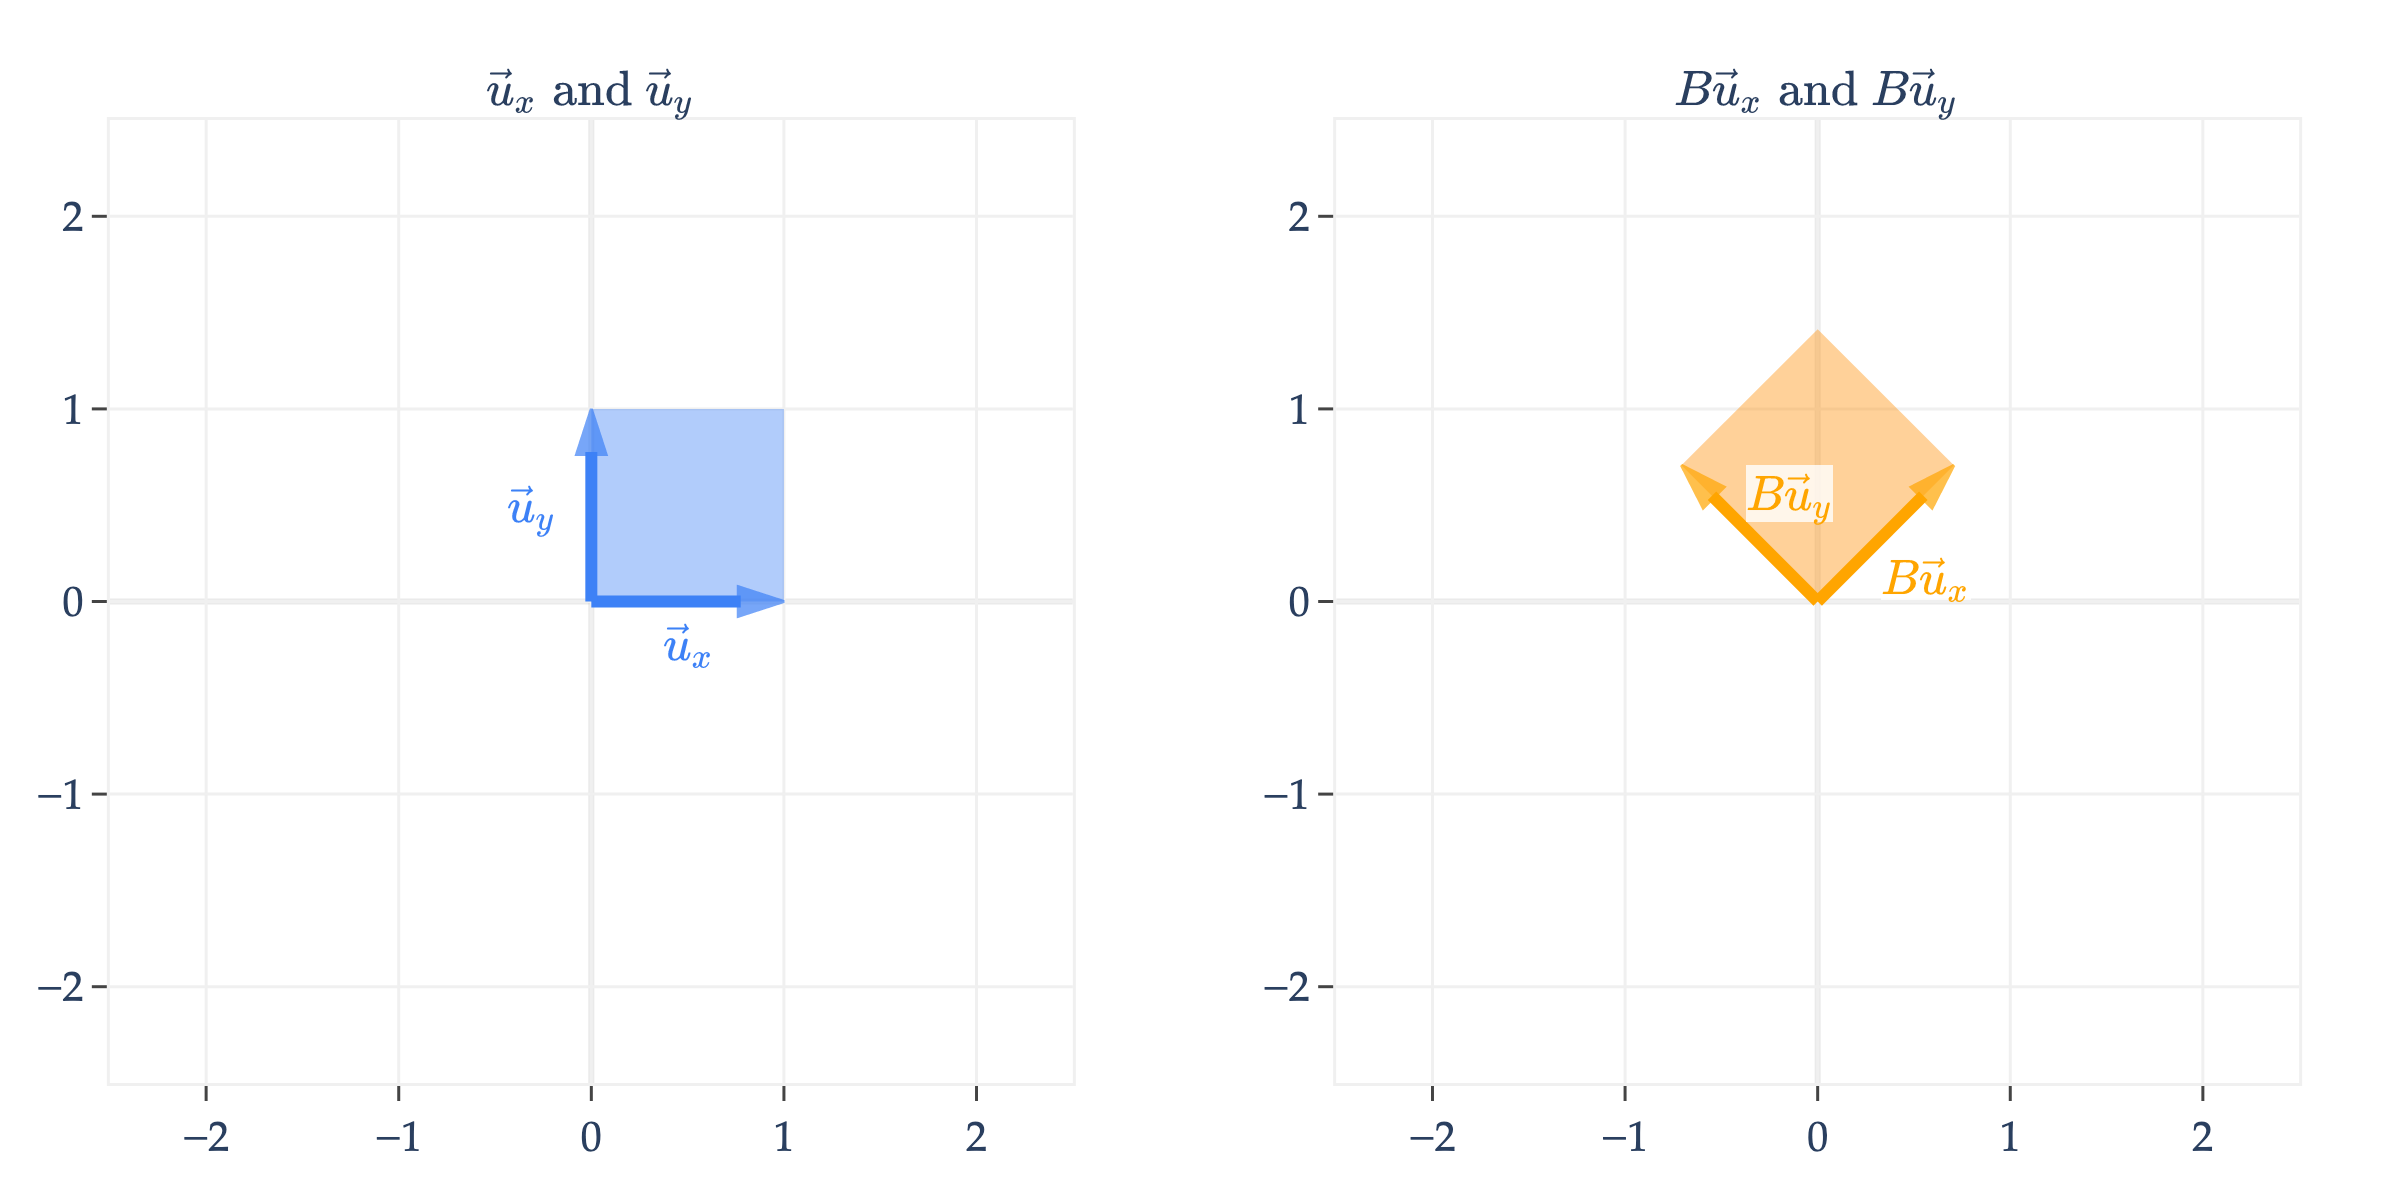

In [4]:
B = np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)], 
              [np.sin(np.pi/4), np.cos(np.pi/4)]])
plot_unit_square_and_transform(B, name="B", vdeltay=-0.3)

Just to continue the previous example, the vector $\begin{bmatrix} 2 \\ -1 \end{bmatrix}$ is transformed into

$$B \begin{bmatrix} 2 \\ -1 \end{bmatrix} = \begin{bmatrix} \sqrt{2} / 2 & -\sqrt{2} / 2 \\ \sqrt{2} / 2 & \sqrt{2} / 2 \end{bmatrix} \begin{bmatrix} 2 \\ -1 \end{bmatrix} = 2 \underbrace{\begin{bmatrix} \sqrt{2} / 2 \\ \sqrt{2} / 2 \end{bmatrix}}_{\color{orange}B \vec u_x} - \underbrace{\begin{bmatrix} -\sqrt{2} / 2 \\ \sqrt{2} / 2 \end{bmatrix}}_{\color{orange} B \vec u_y} = \begin{bmatrix} 3 \sqrt{2} / 2 \\ \sqrt{2} / 2 \end{bmatrix}$$

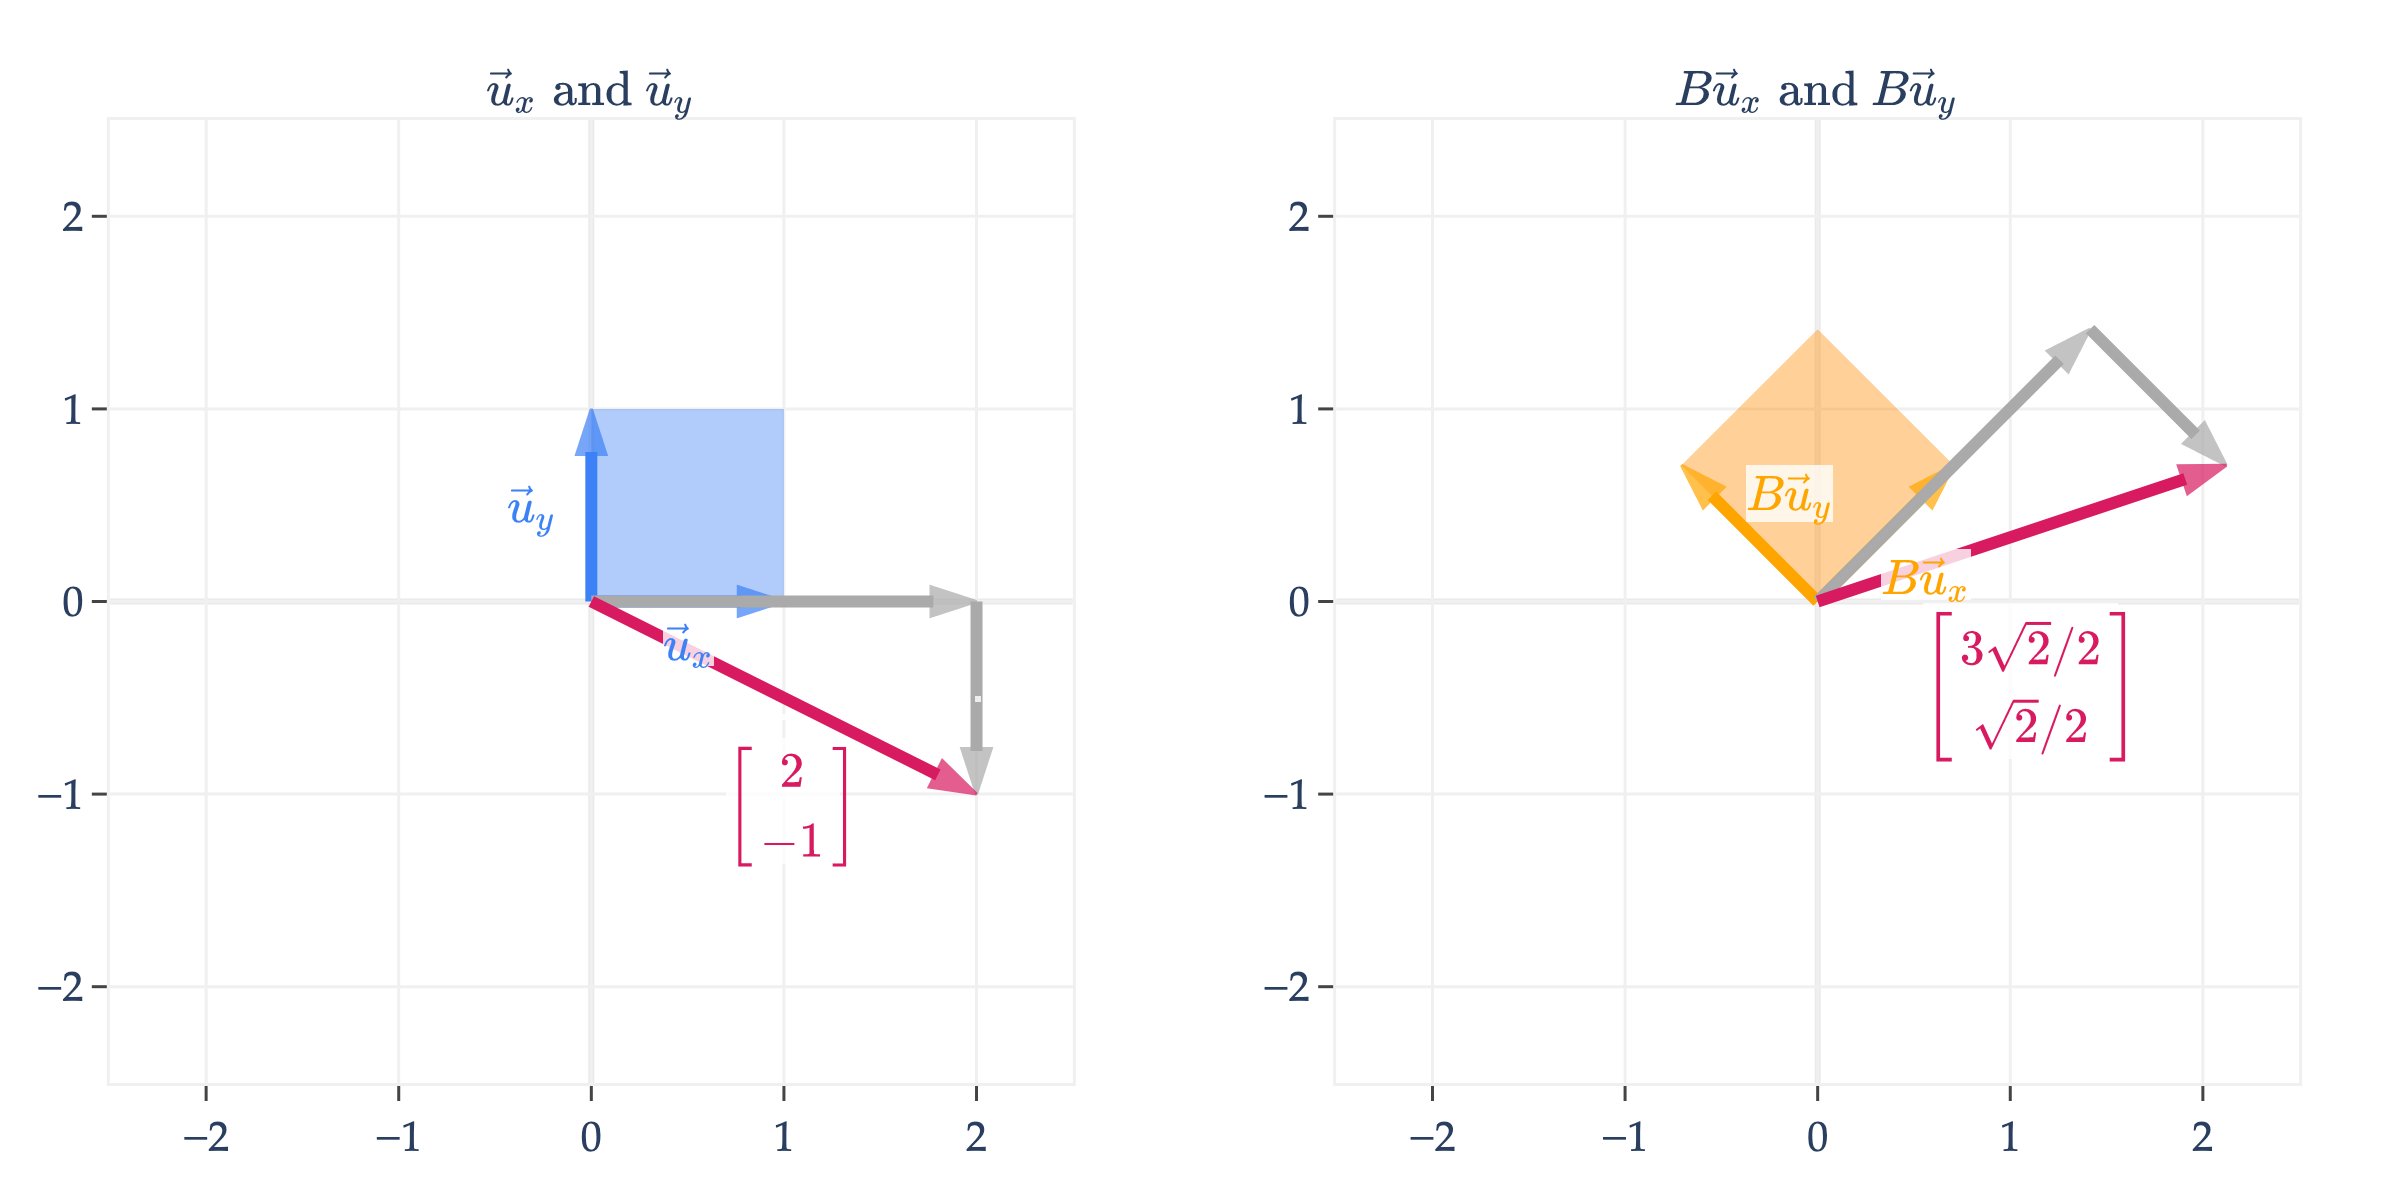

In [28]:
import numpy as np

B = np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)], 
              [np.sin(np.pi/4), np.cos(np.pi/4)]])
fig = plot_unit_square_and_transform(B, name="B", vdeltay=-0.3, return_fig=True)

# Helper function to add plot_vectors traces/annotations
def add_vectors_to_subplot(fig, list_of_vecs, start_points, colors, labels, vdeltax=0, vdeltay=0, row=1, col=1):
    from utils import plot_vectors
    vec_traces = []
    # Start each vector at the specified start; plot_vectors expects (vec, color, label) triples
    triples = []
    for v, clr, lbl in zip(list_of_vecs, colors, labels):
        triples.append((tuple(v), clr, lbl))
    # plot_vectors always starts at (0,0), so to produce origins elsewhere, need to shift result traces
    base_fig = plot_vectors(triples, vdeltax=vdeltax, vdeltay=vdeltay)
    for idx, v in enumerate(list_of_vecs):
        tr = base_fig.data[idx]
        # Compute offset to move trace if needed:
        start = np.asarray(start_points[idx])
        # plot_vectors always [0, v[0]], [0, v[1]]; shift by start
        # Only shift actual vector portions, not markers etc.
        tr_shifted = tr
        # plotly.graph_objs.Scatter are immutable, so must copy with updated x/y
        tr_shifted = tr_shifted.update(
            x=(start[0] + np.array(tr.x)),
            y=(start[1] + np.array(tr.y)),
            showlegend=False  # never show legend here
        )
        fig.add_trace(tr_shifted, row=row, col=col)
        # Now also add annotation
        ann = base_fig.layout.annotations[idx]
        # The annotation has fields x/y; shift annotation location as well
        if hasattr(ann, "to_plotly_json"):
            ann_dict = ann.to_plotly_json()
        else:
            ann_dict = dict(ann)
        ann_dict = {k: v for k, v in ann_dict.items() if k not in {"xref", "yref", "axref", "ayref"}}
        # The text position should be shifted wrt origin exactly like the trace endpoint
        ann_dict["x"] = start[0] + ann_dict.get("x", 0)
        ann_dict["y"] = start[1] + ann_dict.get("y", 0)
        fig.add_annotation(**ann_dict, row=row, col=col)

# --- Data for both left/right panes ---
ux = np.array([1, 0])
uy = np.array([0, 1])
origin = np.array([0, 0])
vecs_L = [2 * ux, -uy, 2 * ux - uy]
starts_L = [origin, 2 * ux, origin]
colors_L = ["#aaa", "#aaa", "#d81a60"]  # blue, red, purple
labels_L = [r"$$", r"", fr"$\begin{{bmatrix}} 2 \\ -1 \end{{bmatrix}}$"]

Bux = B[:, 0]
Buy = B[:, 1]
vecs_R = [2 * Bux, -Buy, 2 * Bux - Buy]
starts_R = [origin, 2 * Bux, origin]
colors_R = ["#aaa", "#aaa", "#d81a60"]
labels_R = [r"", r"$$", fr"$\begin{{bmatrix}} 3\sqrt{{2}} / 2 \\ \sqrt{{2}} / 2 \end{{bmatrix}}$"]

add_vectors_to_subplot(fig, vecs_L, starts_L, colors_L, labels_L, row=1, col=1, vdeltay=-0.6)
add_vectors_to_subplot(fig, vecs_R, starts_R, colors_R, labels_R, row=1, col=2, vdeltay=-0.8)

fig.show(renderer='png', scale=3)

$B$ is an **orthogonal matrix**, which means that its columns are unit vectors and are orthogonal to one another.

$$\underbrace{B^TB = BB^T = I}_\text{condition for an orthogonal matrix}$$

Orthogonal matrices **rotate** vectors in the input space. In general, a matrix that rotates vectors by $\theta$ (radians) counterclockwise in $\mathbb{R}^2$ is given by

$$R(\theta) = \begin{bmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{bmatrix}$$

$B = R(\frac{\pi}{4})$ rotates vectors by $\frac{\pi}{4}$ radians, i.e. $45^\circ$.

Rotations are more difficult to visualize in $\mathbb{R}^3$ and higher dimensions, but in Homework 5, you'll prove that orthogonal matrices preserve **norms**, i.e. if $Q$ is an $n \times n$ orthogonal matrix and $x \in \mathbb{R}^n$, then $\|Qx\| = \|x\|$. So, even though an orthogonal matrix might be doing something harder to describe in $\mathbb{R}^{15}$, we know that it isn't changing the lengths of the vectors it's multiplying.

To drive home the point I made earlier, any vector $\vec v = \begin{bmatrix} x \\ y \end{bmatrix}$, once multiplied by $B$, ends up transforming into

$$B \underbrace{\begin{bmatrix} x \\ y \end{bmatrix}}_{\vec v} = x ({\color{orange}{B \vec u_x}}) + y ({\color{orange}{B \vec u_y}})$$

### Composing Transformations

We can even apply multiple transformations one after another. This is called **composing** transformations. For instance,

$$C = \begin{bmatrix} \sqrt{2} & -\sqrt{2} \\ -\sqrt{2} / 6 & -\sqrt{2} / 6 \end{bmatrix}$$

is just $$C = AB = \underbrace{\begin{bmatrix} 2 & 0 \\ 0 & -1/3 \end{bmatrix}}_{\text{scale}} \underbrace{\begin{bmatrix} \sqrt{2}/2 & -\sqrt{2}/2 \\ \sqrt{2}/2 & \sqrt{2}/2 \end{bmatrix}}_{\text{rotate}}$$

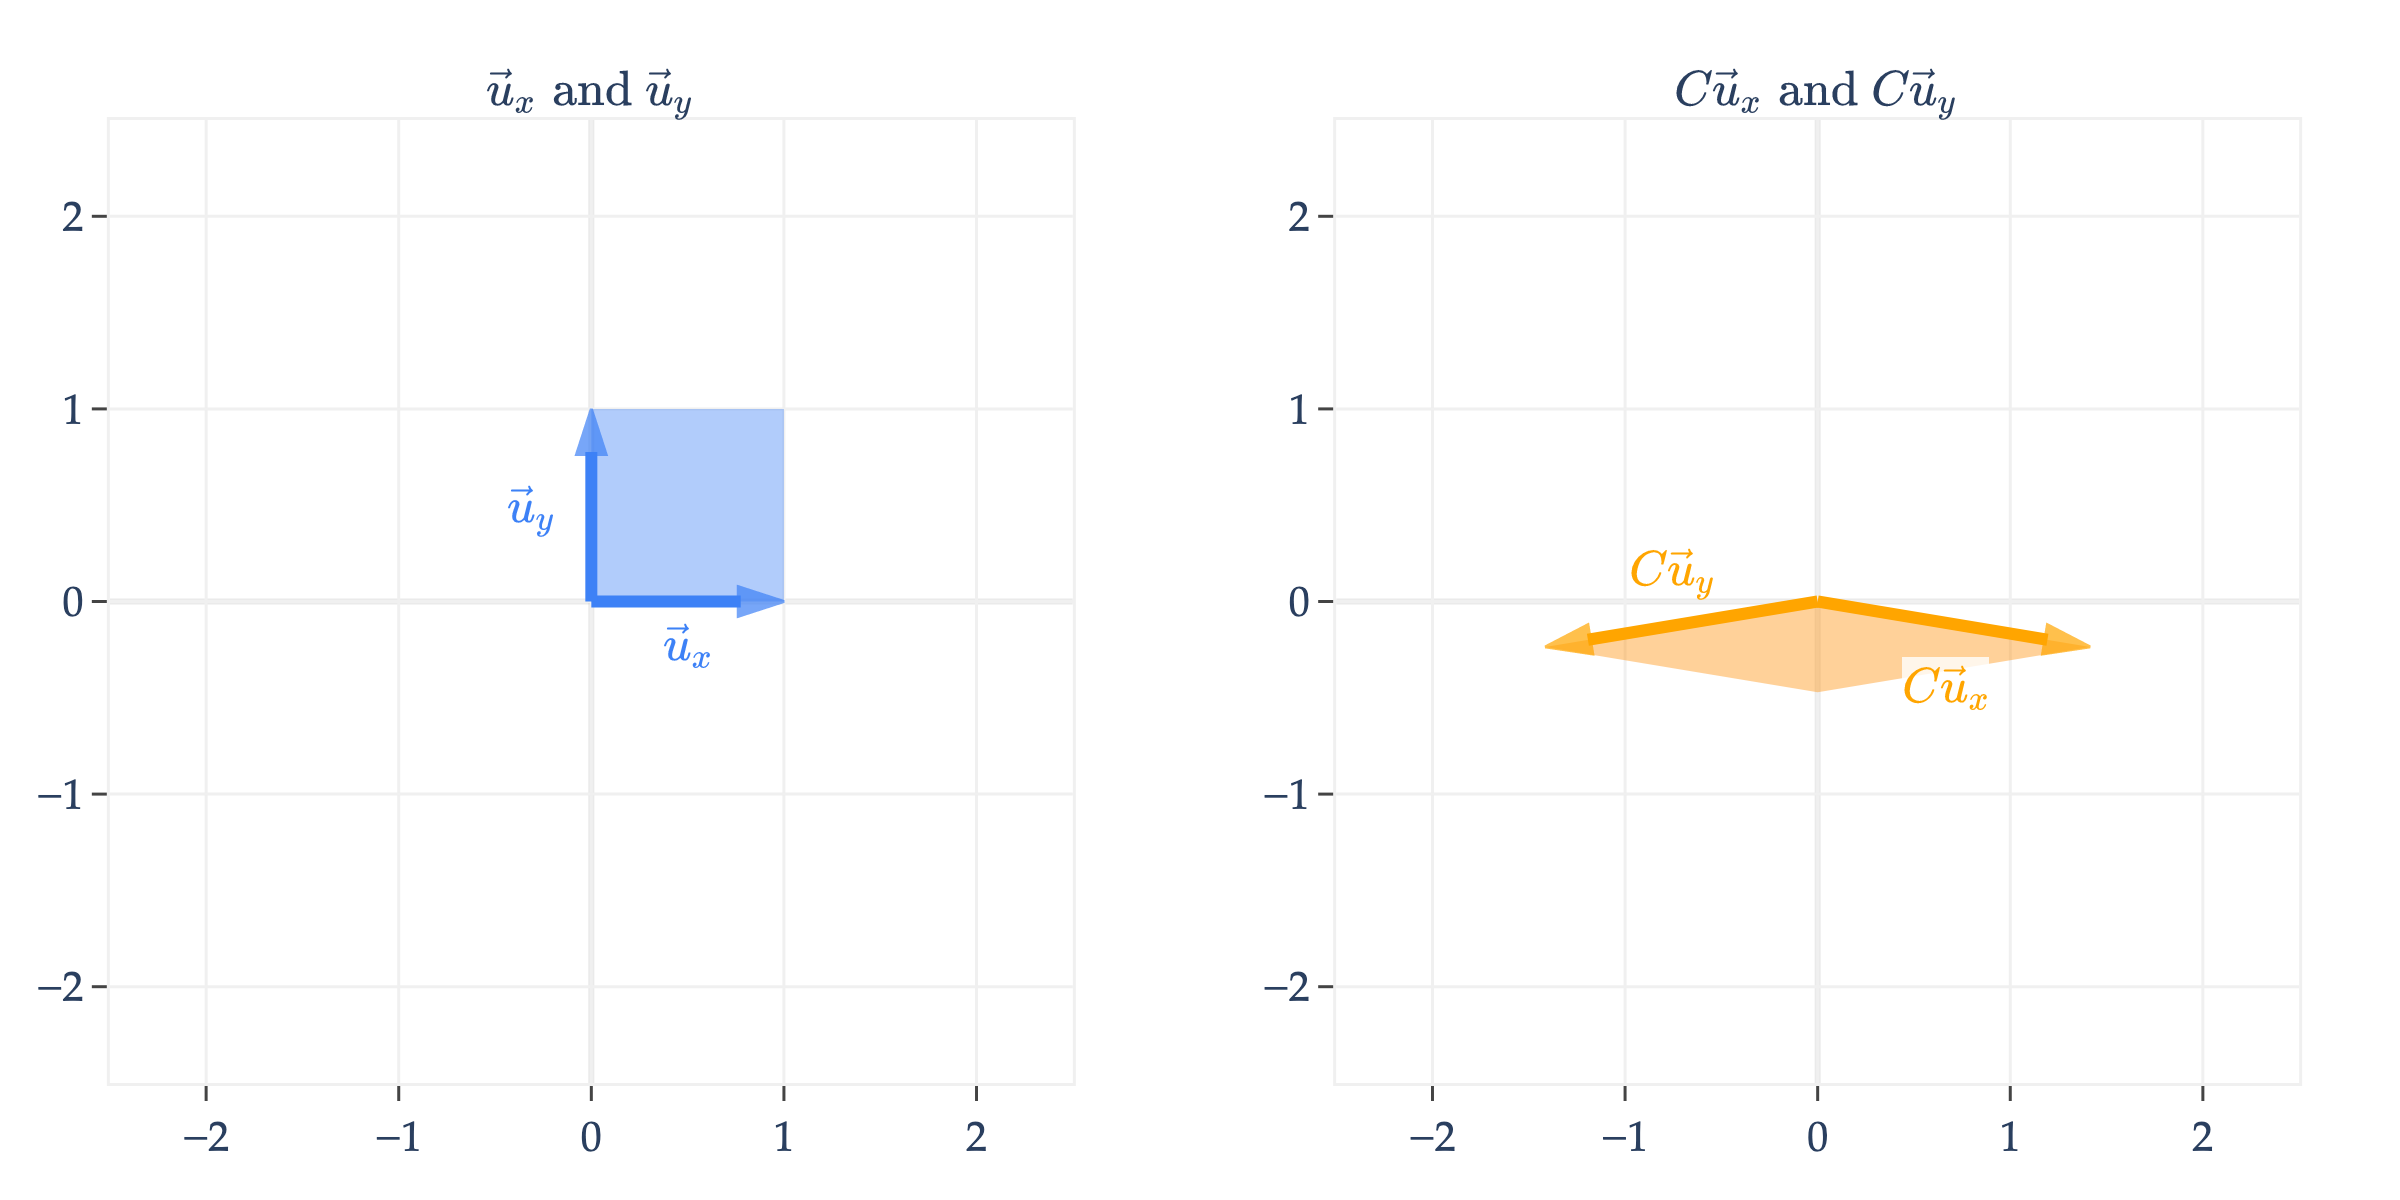

In [170]:
C = A @ B
plot_unit_square_and_transform(C, name="C", vdeltay=-0.3)

Note that $C$ rotates the input vector, **and then** scales it. Read the operations from right to left, since $C\vec x = AB \vec x = A(B \vec x)$.

$C = AB$ is different from

$$D = \begin{bmatrix} \sqrt{2} & \sqrt{2} / 6 \\ \sqrt{2} & -\sqrt{2} / 6 \end{bmatrix} = B A$$

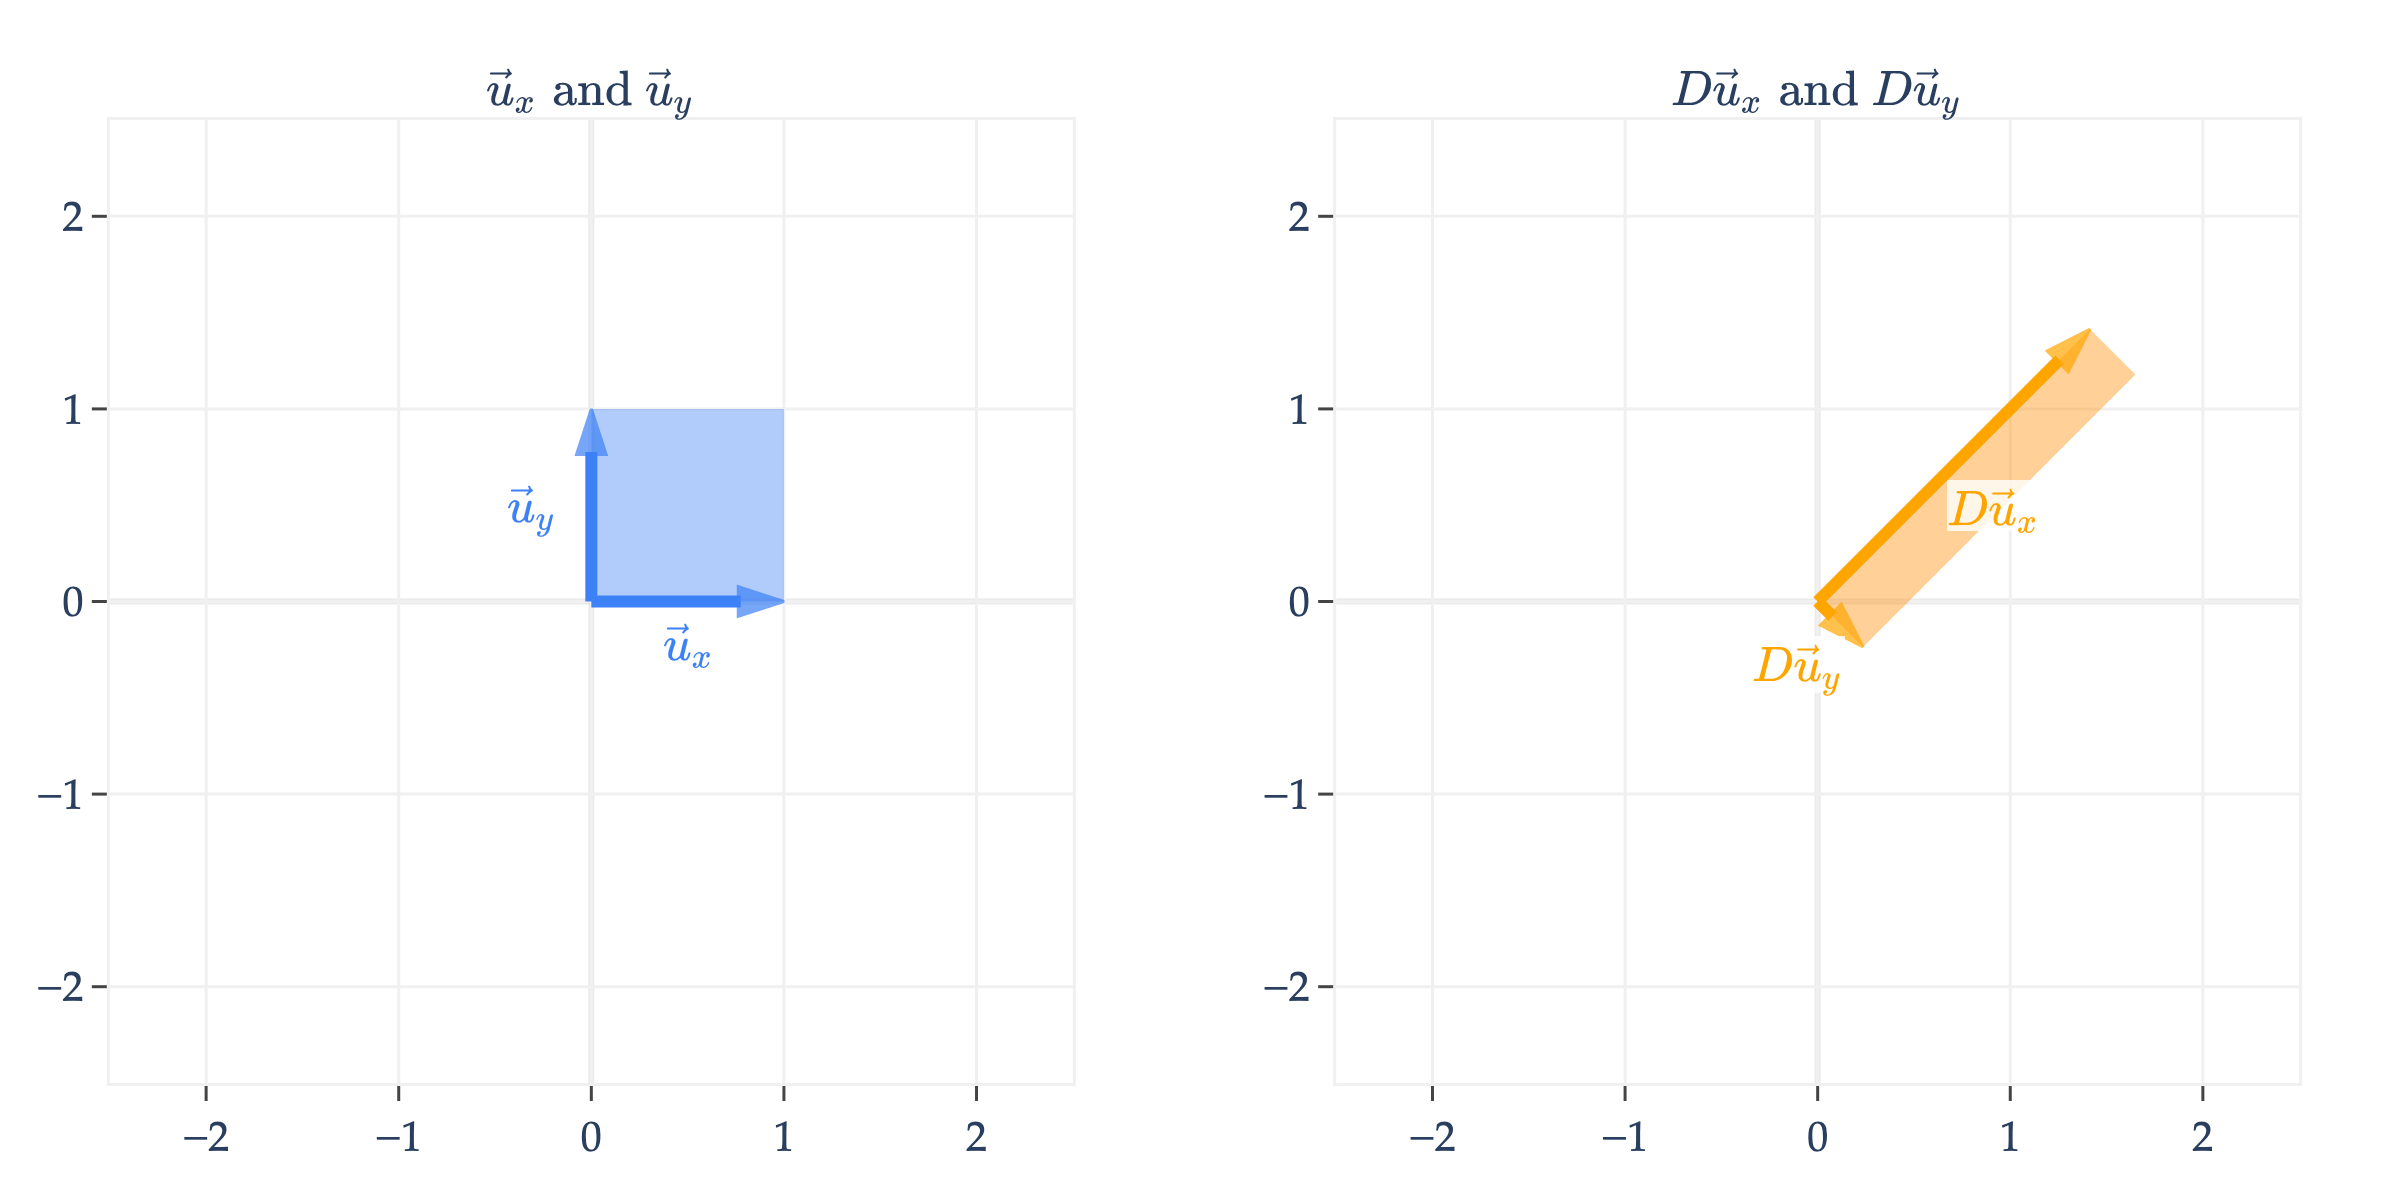

In [173]:
D = B @ A
plot_unit_square_and_transform(D, name="D", vdeltay=-0.3)

### Shears

$$E = \begin{bmatrix} 1 & -2/3 \\ 0 & 1 \end{bmatrix}$$

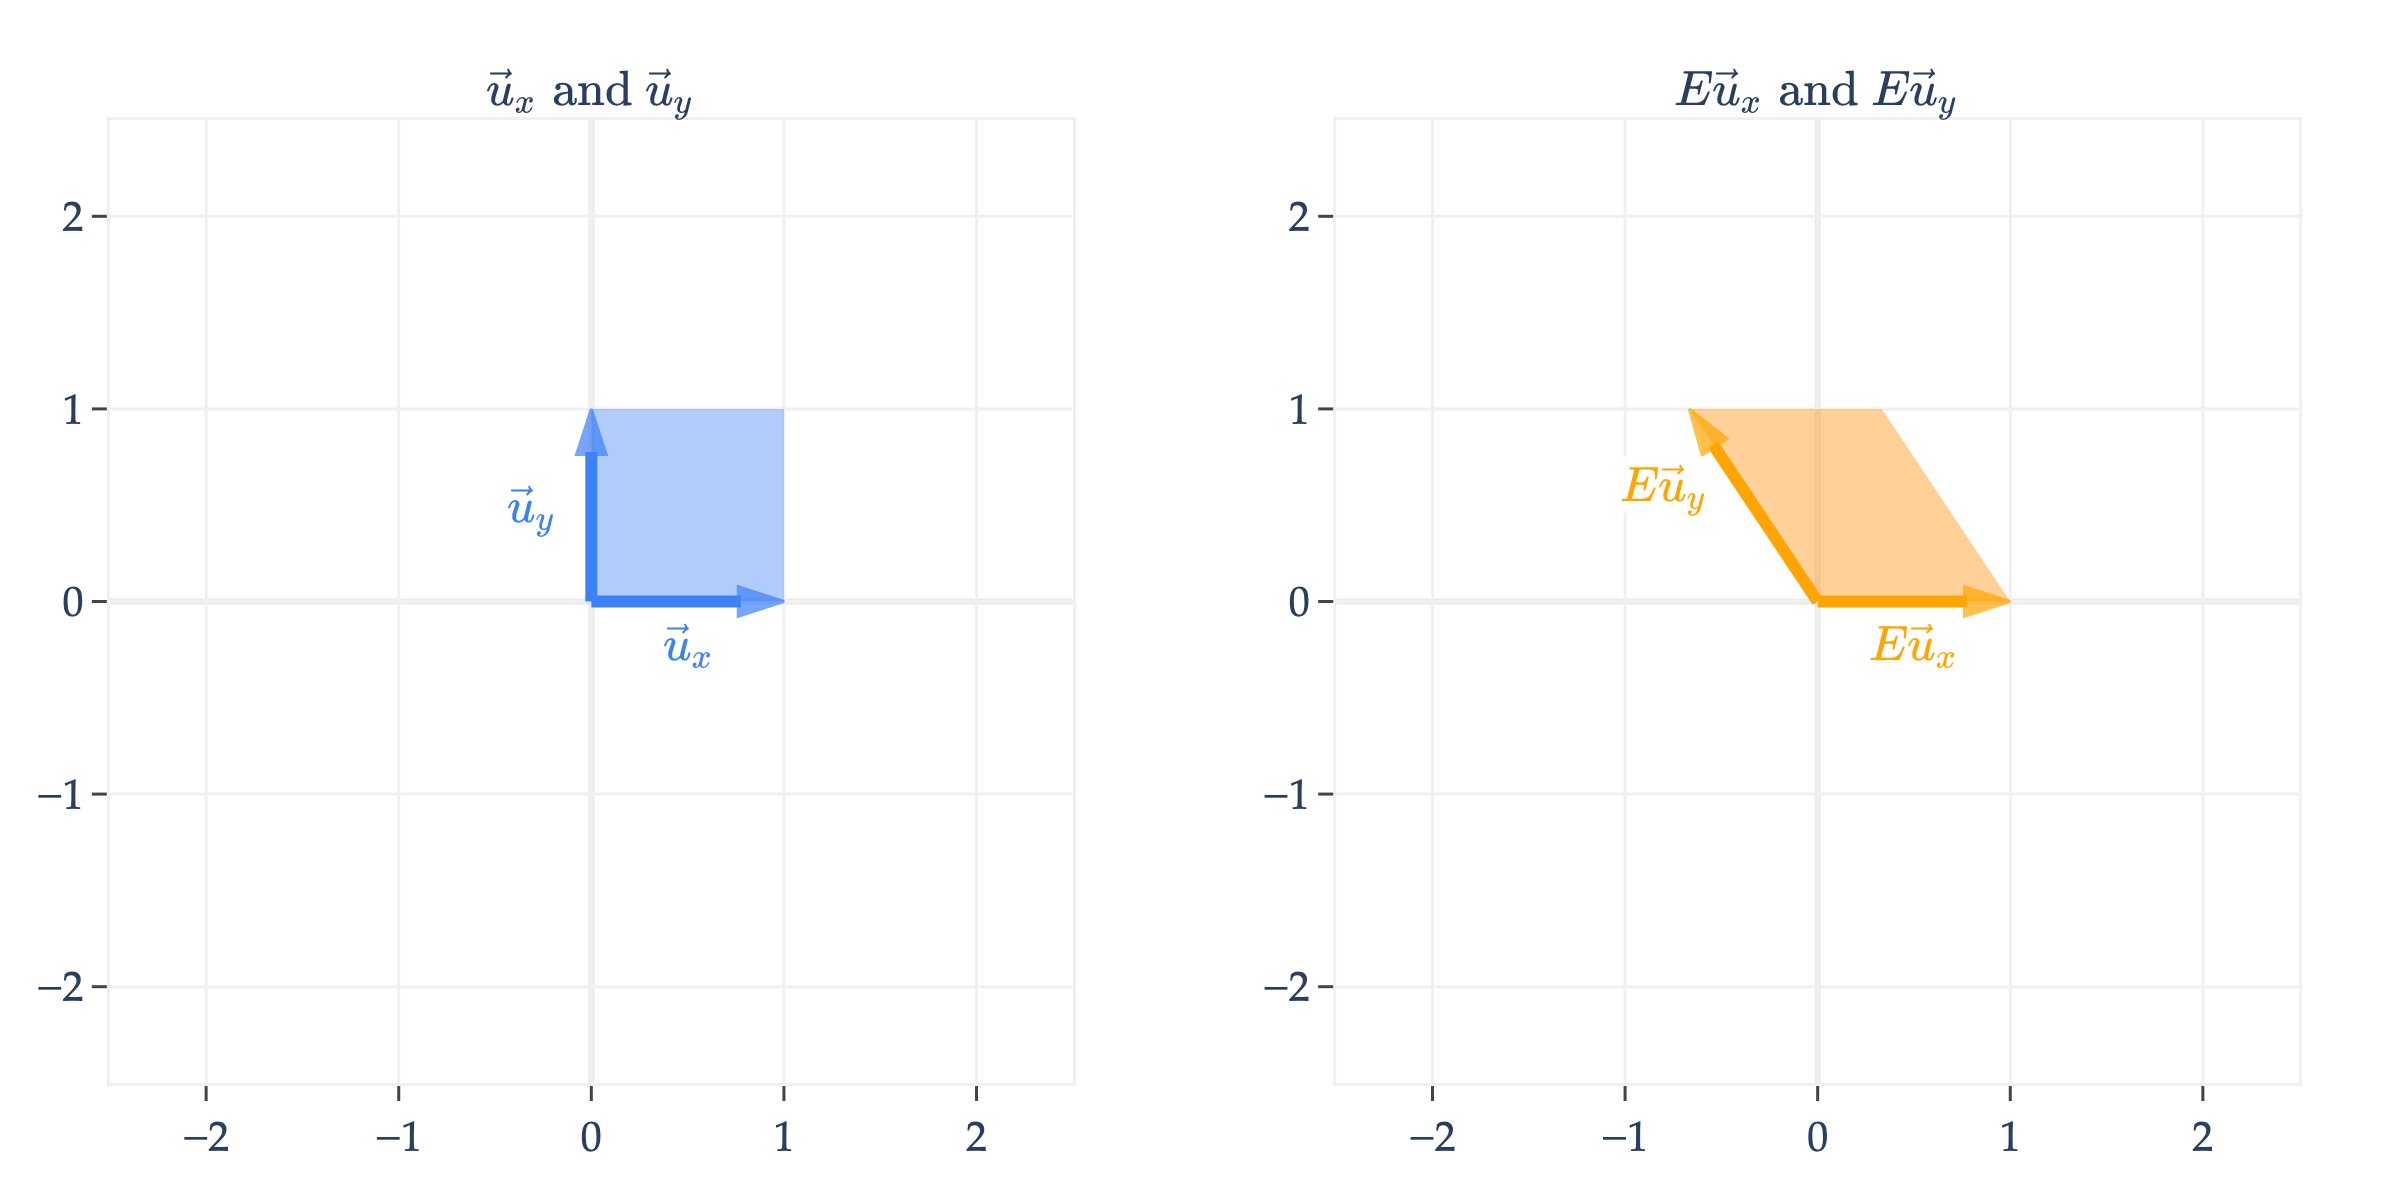

In [182]:
E = np.array([[1, -2 / 3], [0, 1]])
plot_unit_square_and_transform(E, name="E", vdeltay=-0.2, vdeltax=0.55)

$E$ is a **shear matrix**. Think of a shear as a transformation that slants the input space along one axis, while keeping the other axis fixed. What helps me interpret shears is looking at them formulaically.

$$E \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 1 & -2/3 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} x - 2/3 y \\ y \end{bmatrix}$$

Note that the $y$-coordinate of input vectors in $\mathbb{R}^2$ remain unchanged, while the $x$-coordinate is shifted by $-\frac{2}{3}y$, which results in a slanted shape.

Similarly, $F$ is a shear matrix that keeps the $x$-coordinate fixed, but shifts the $y$-coordinate, resulting in a slanted shape that is tilted downwards.

$$F = \begin{bmatrix} 1 & 0 \\ -5/4 & 1 \end{bmatrix}$$

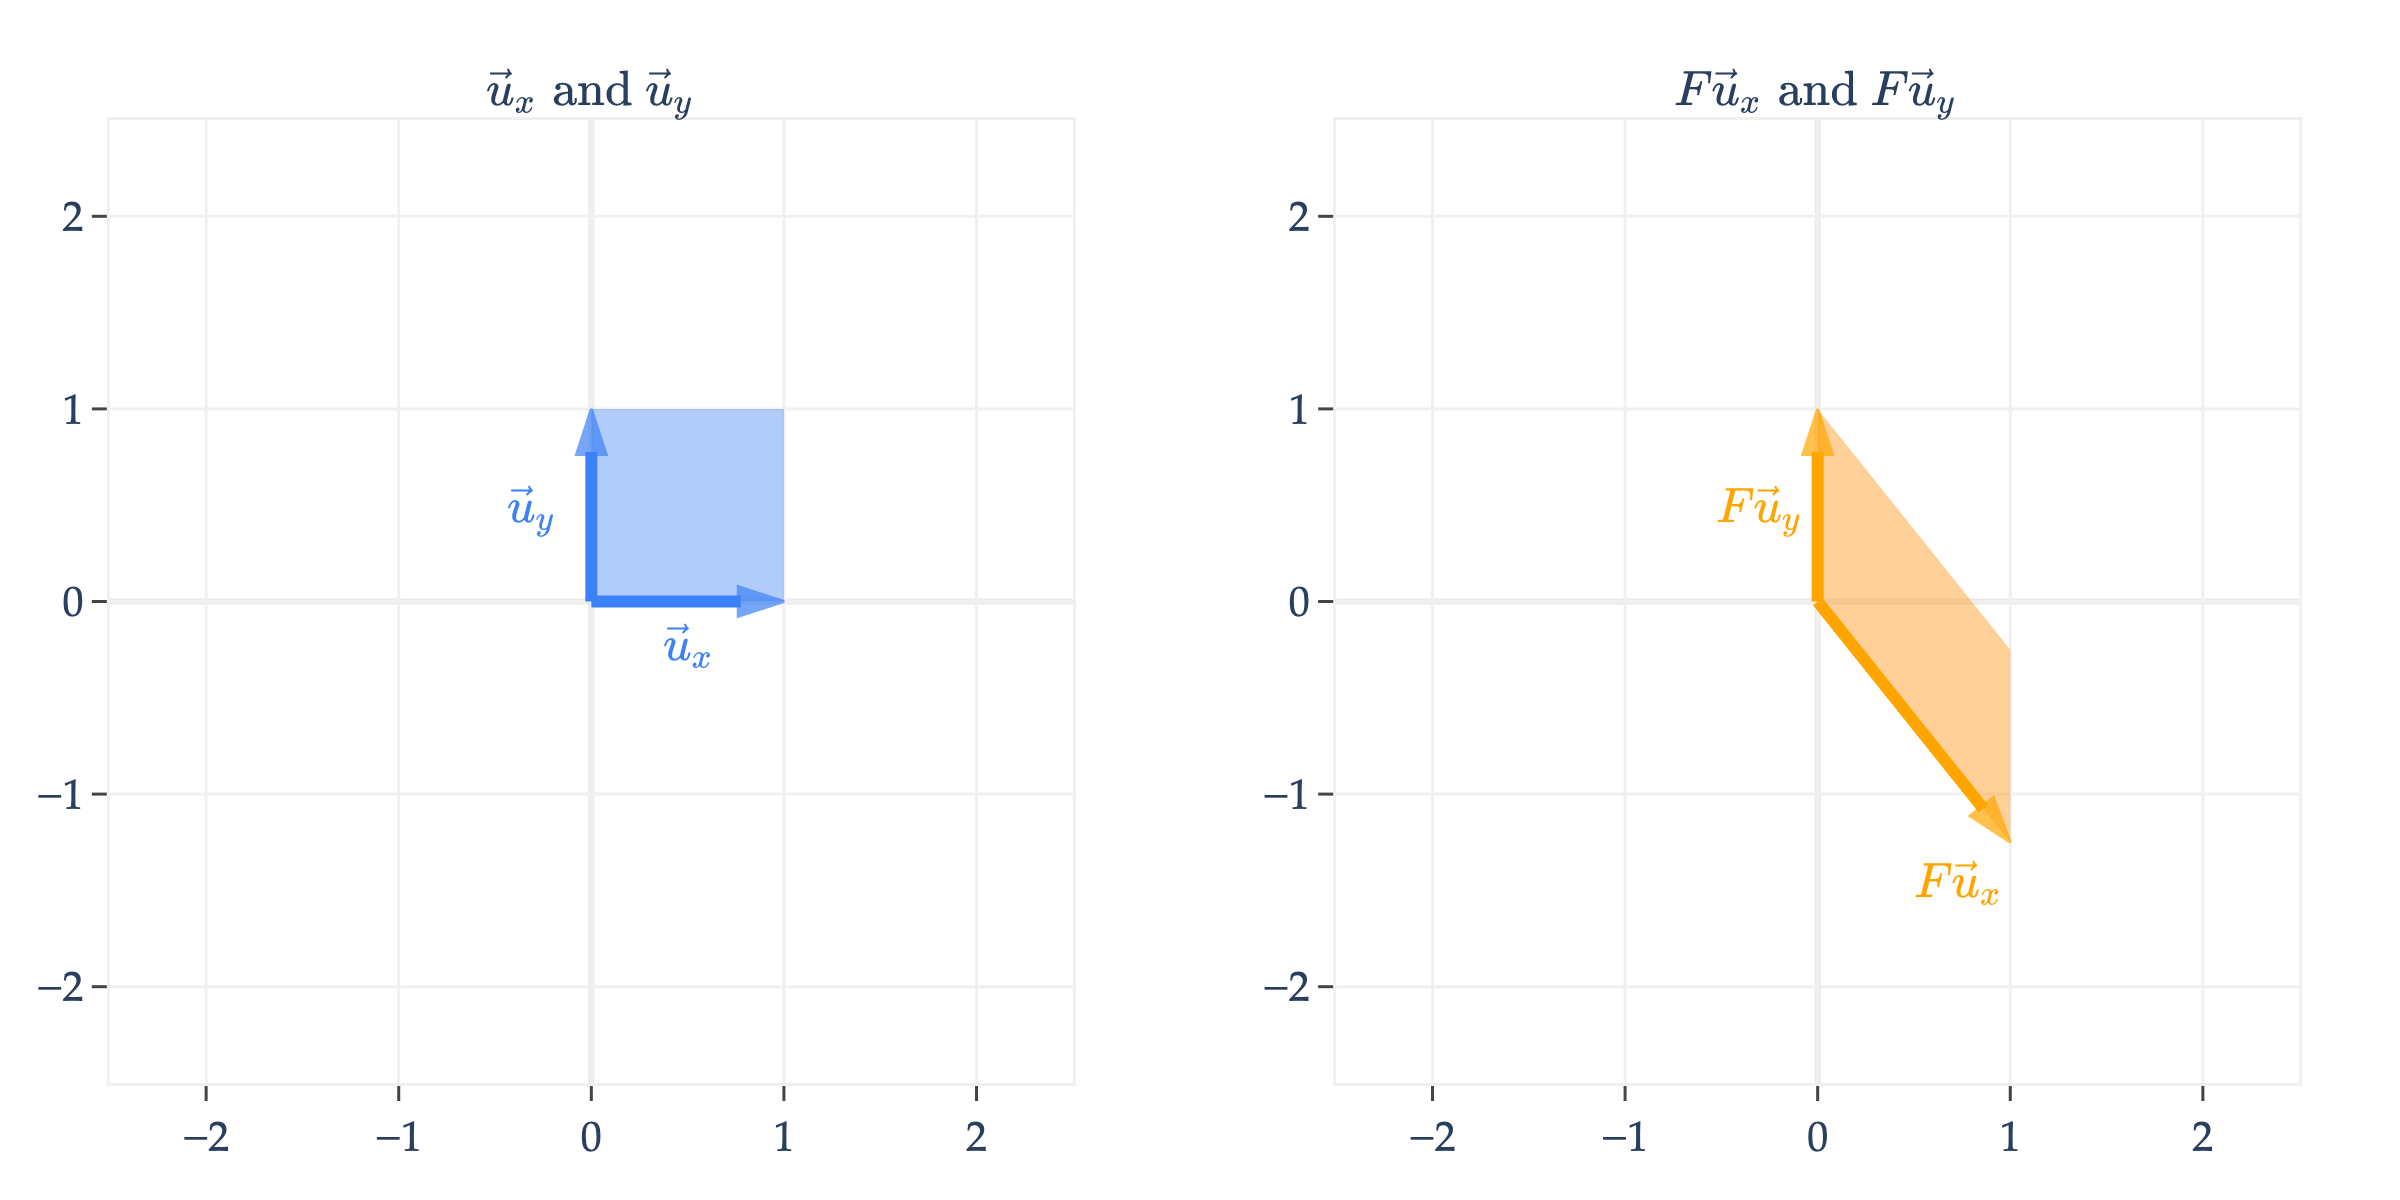

In [191]:
F = np.array([[1, 0], [-5 / 4, 1]])
plot_unit_square_and_transform(F, name="F", vdeltay=-1.3, vdeltax=0.3)

### Projections

So far we've looked at **scaling**, **rotation**, and **shear** matrices. Yet another type is a **projection matrix**.

$$G = \begin{bmatrix} 1 & 0 \\ 0 & 0 \end{bmatrix}$$

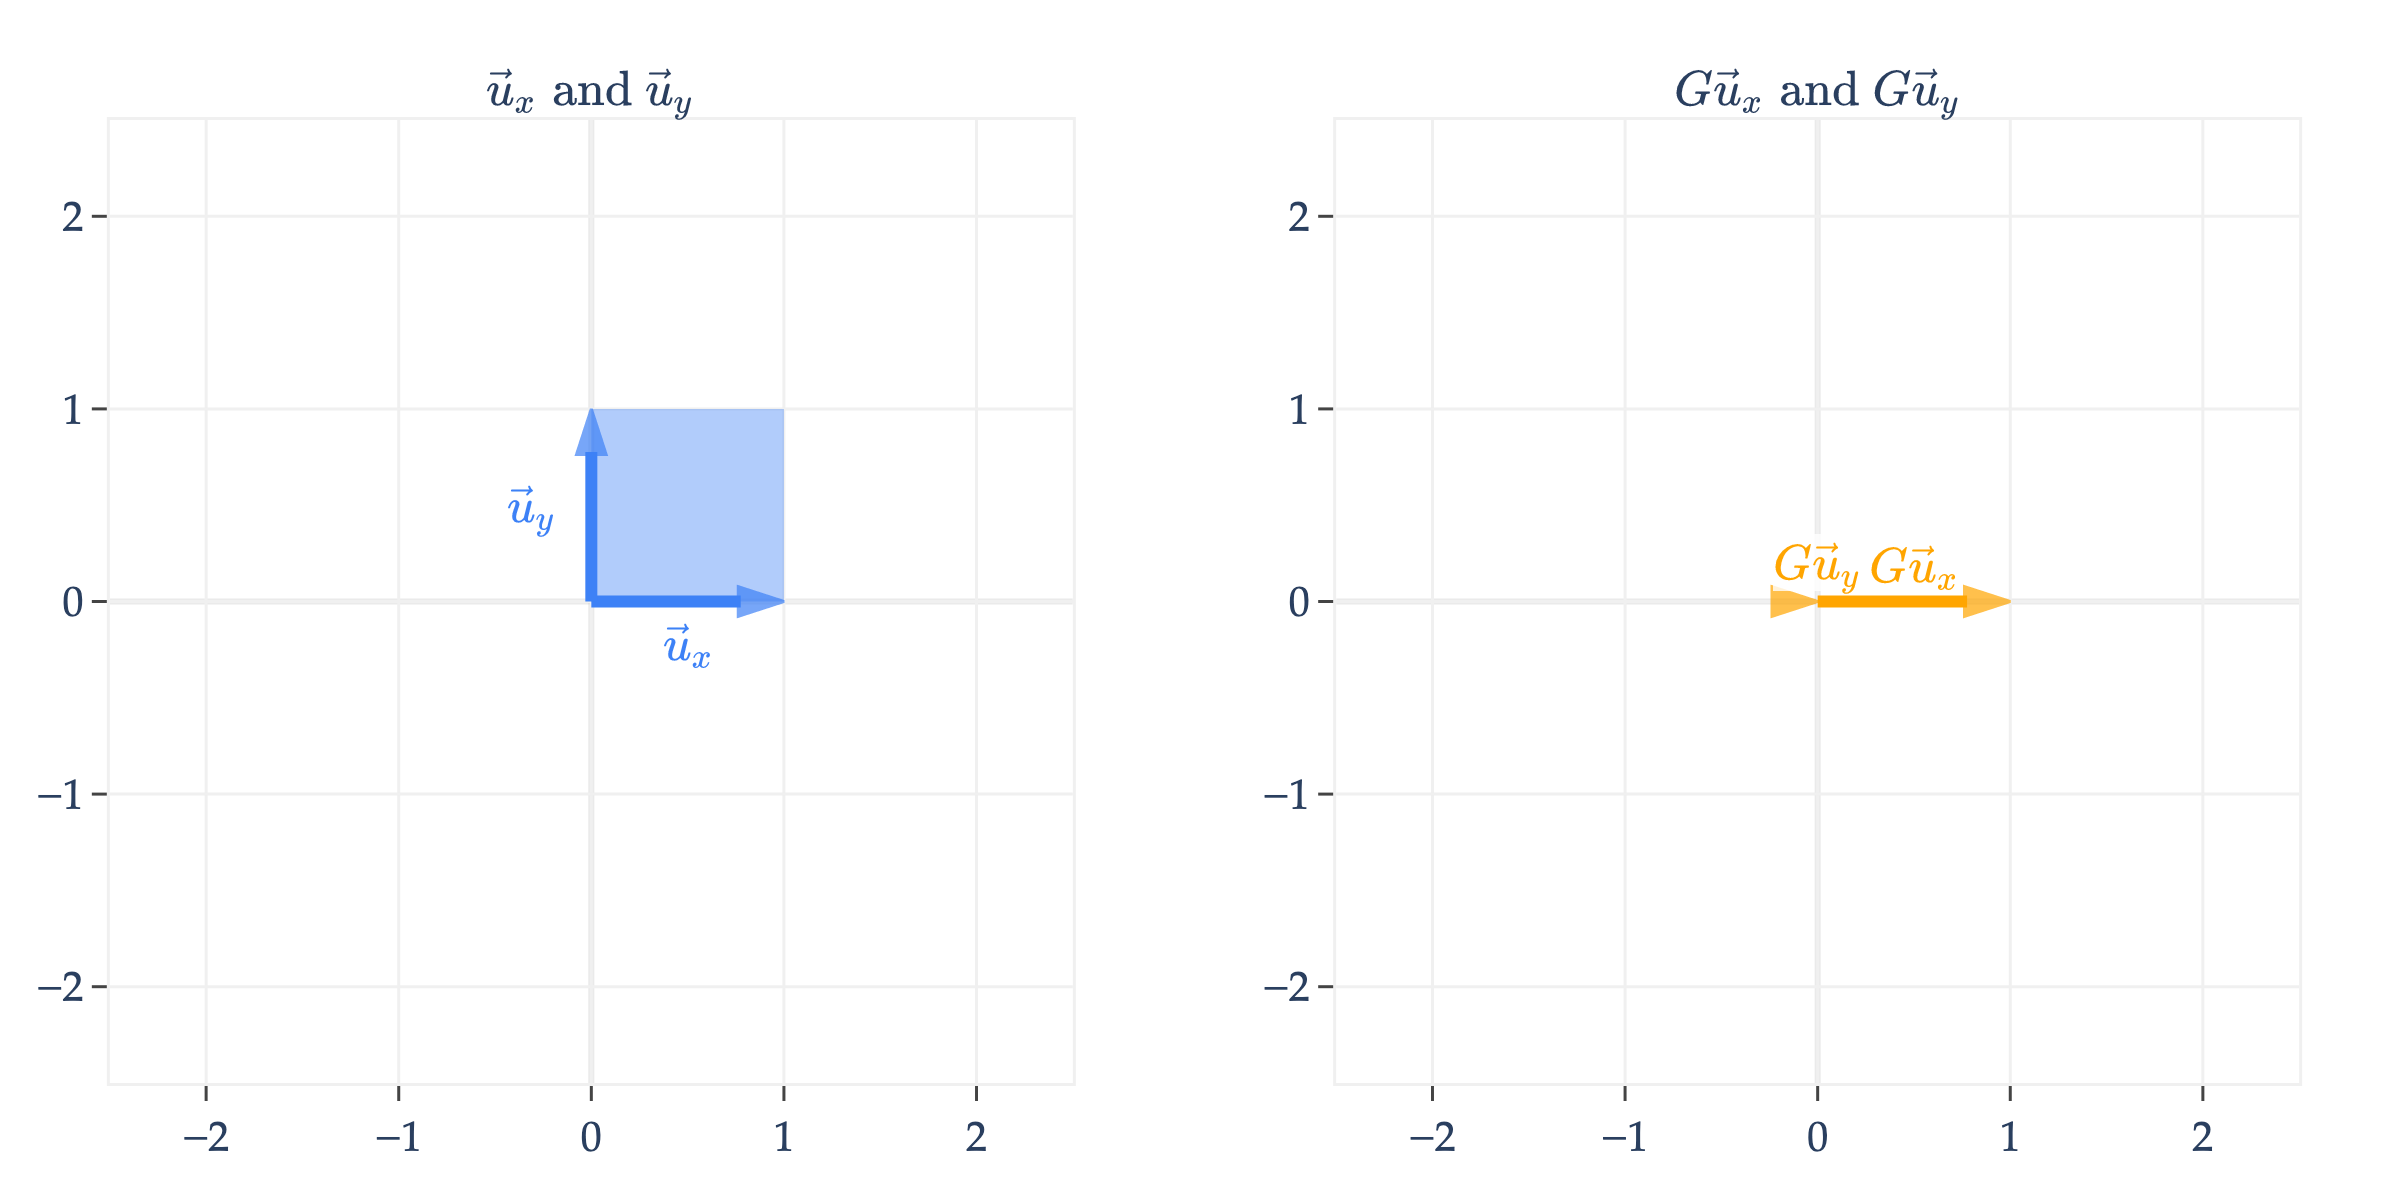

In [192]:
G = np.array([[1, 0], [0, 0]])
plot_unit_square_and_transform(G, name="G")

$G \vec x$ projects $\vec x$ onto the $x$-axis and throws away the $y$-coordinate. Note that $G$ maps the unit square to a **line**, not another four-sided shape. 

You might also notice that, unlike the matrices we've seen so far, $\text{colsp}(G)$ is **not** all of $\mathbb{R}^2$, but rather it's just a line in $\mathbb{R}^2$, since $G$'s columns are not linearly independent.

$H$ below works similarly.

$$H = \begin{bmatrix} 1 / 2 & -1 \\ 1 & -2 \end{bmatrix}$$

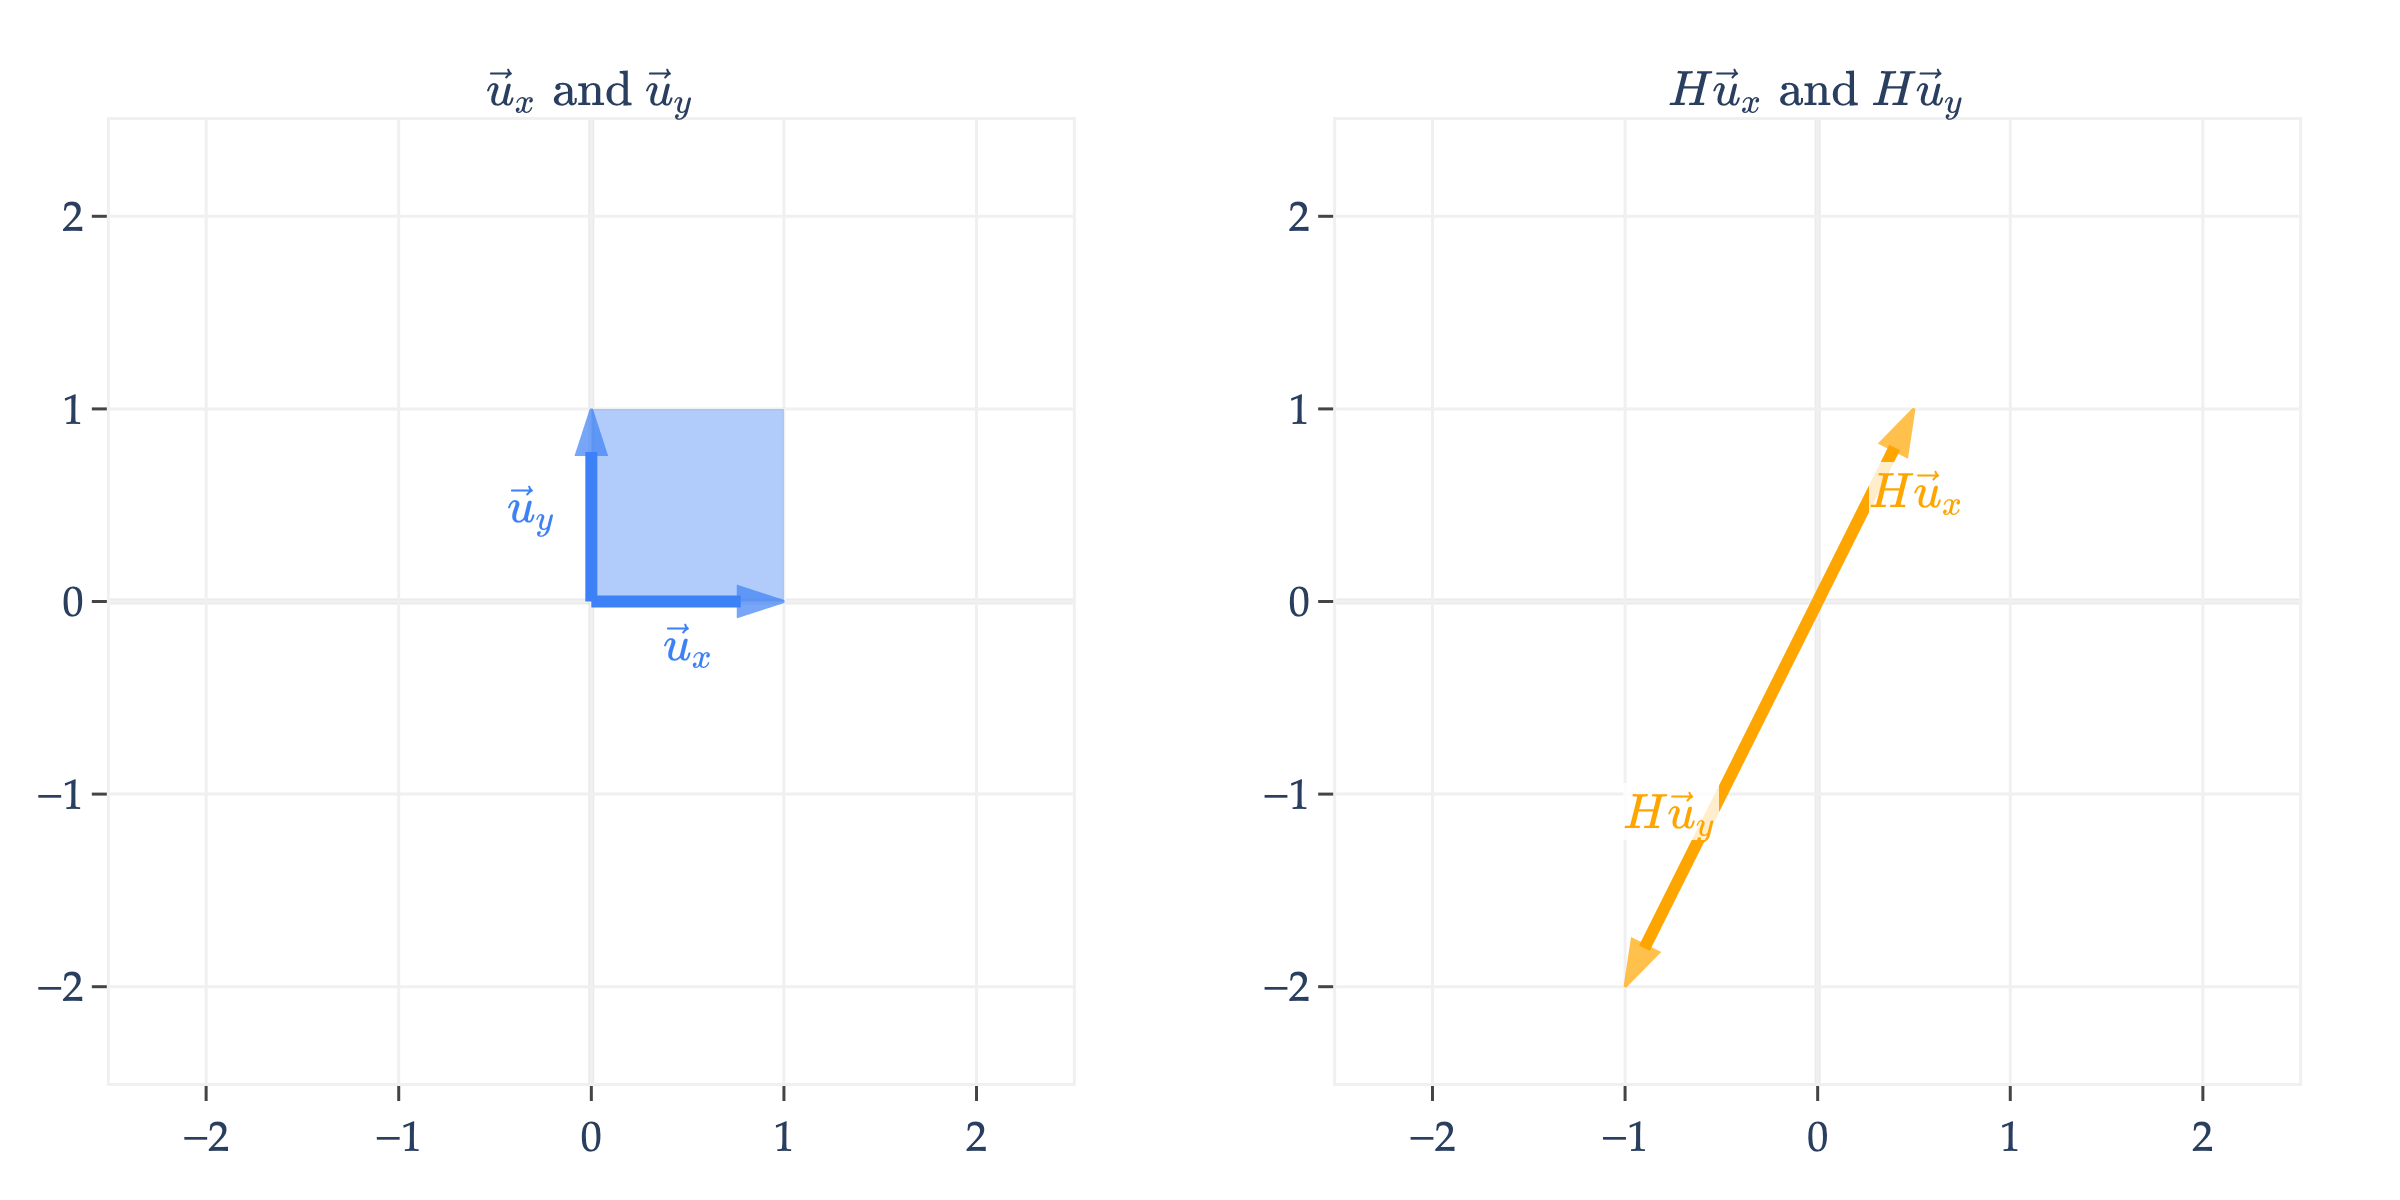

In [193]:
H = np.array([[1 / 2, -1], [1, -2]])
plot_unit_square_and_transform(H, name="H")

$\text{colsp}(H)$ is the line spanned by $\begin{bmatrix} 1 / 2 \\ 1 \end{bmatrix}$, so $H \vec x$ will always be some vector on this line.

Put another way, if $\vec v = \begin{bmatrix} x \\ y \end{bmatrix}$, then $H \vec v$ is

$$H \underbrace{\begin{bmatrix} x \\ y \end{bmatrix}}_{\vec v} = x ({\color{orange}{H \vec u_x}}) + y ({\color{orange}{H \vec u_y}})$$

but since $\color{orange}{H \vec u_x}$ and $\color{orange}{H \vec u_y}$ are both on the line spanned by $\begin{bmatrix} 1 / 2 \\ 1 \end{bmatrix}$, $H \vec v$ is really just a scalar multiple of $\begin{bmatrix} 1 / 2 \\ 1 \end{bmatrix}$.

### Arbitrary Matrices

Finally, I'll comment that not all linear transformations have a nice, intuitive interpretation. For instance, consider

$$J = \begin{bmatrix} 1 / 3 & -1 \\ 1 & -1 / 2 \end{bmatrix}$$

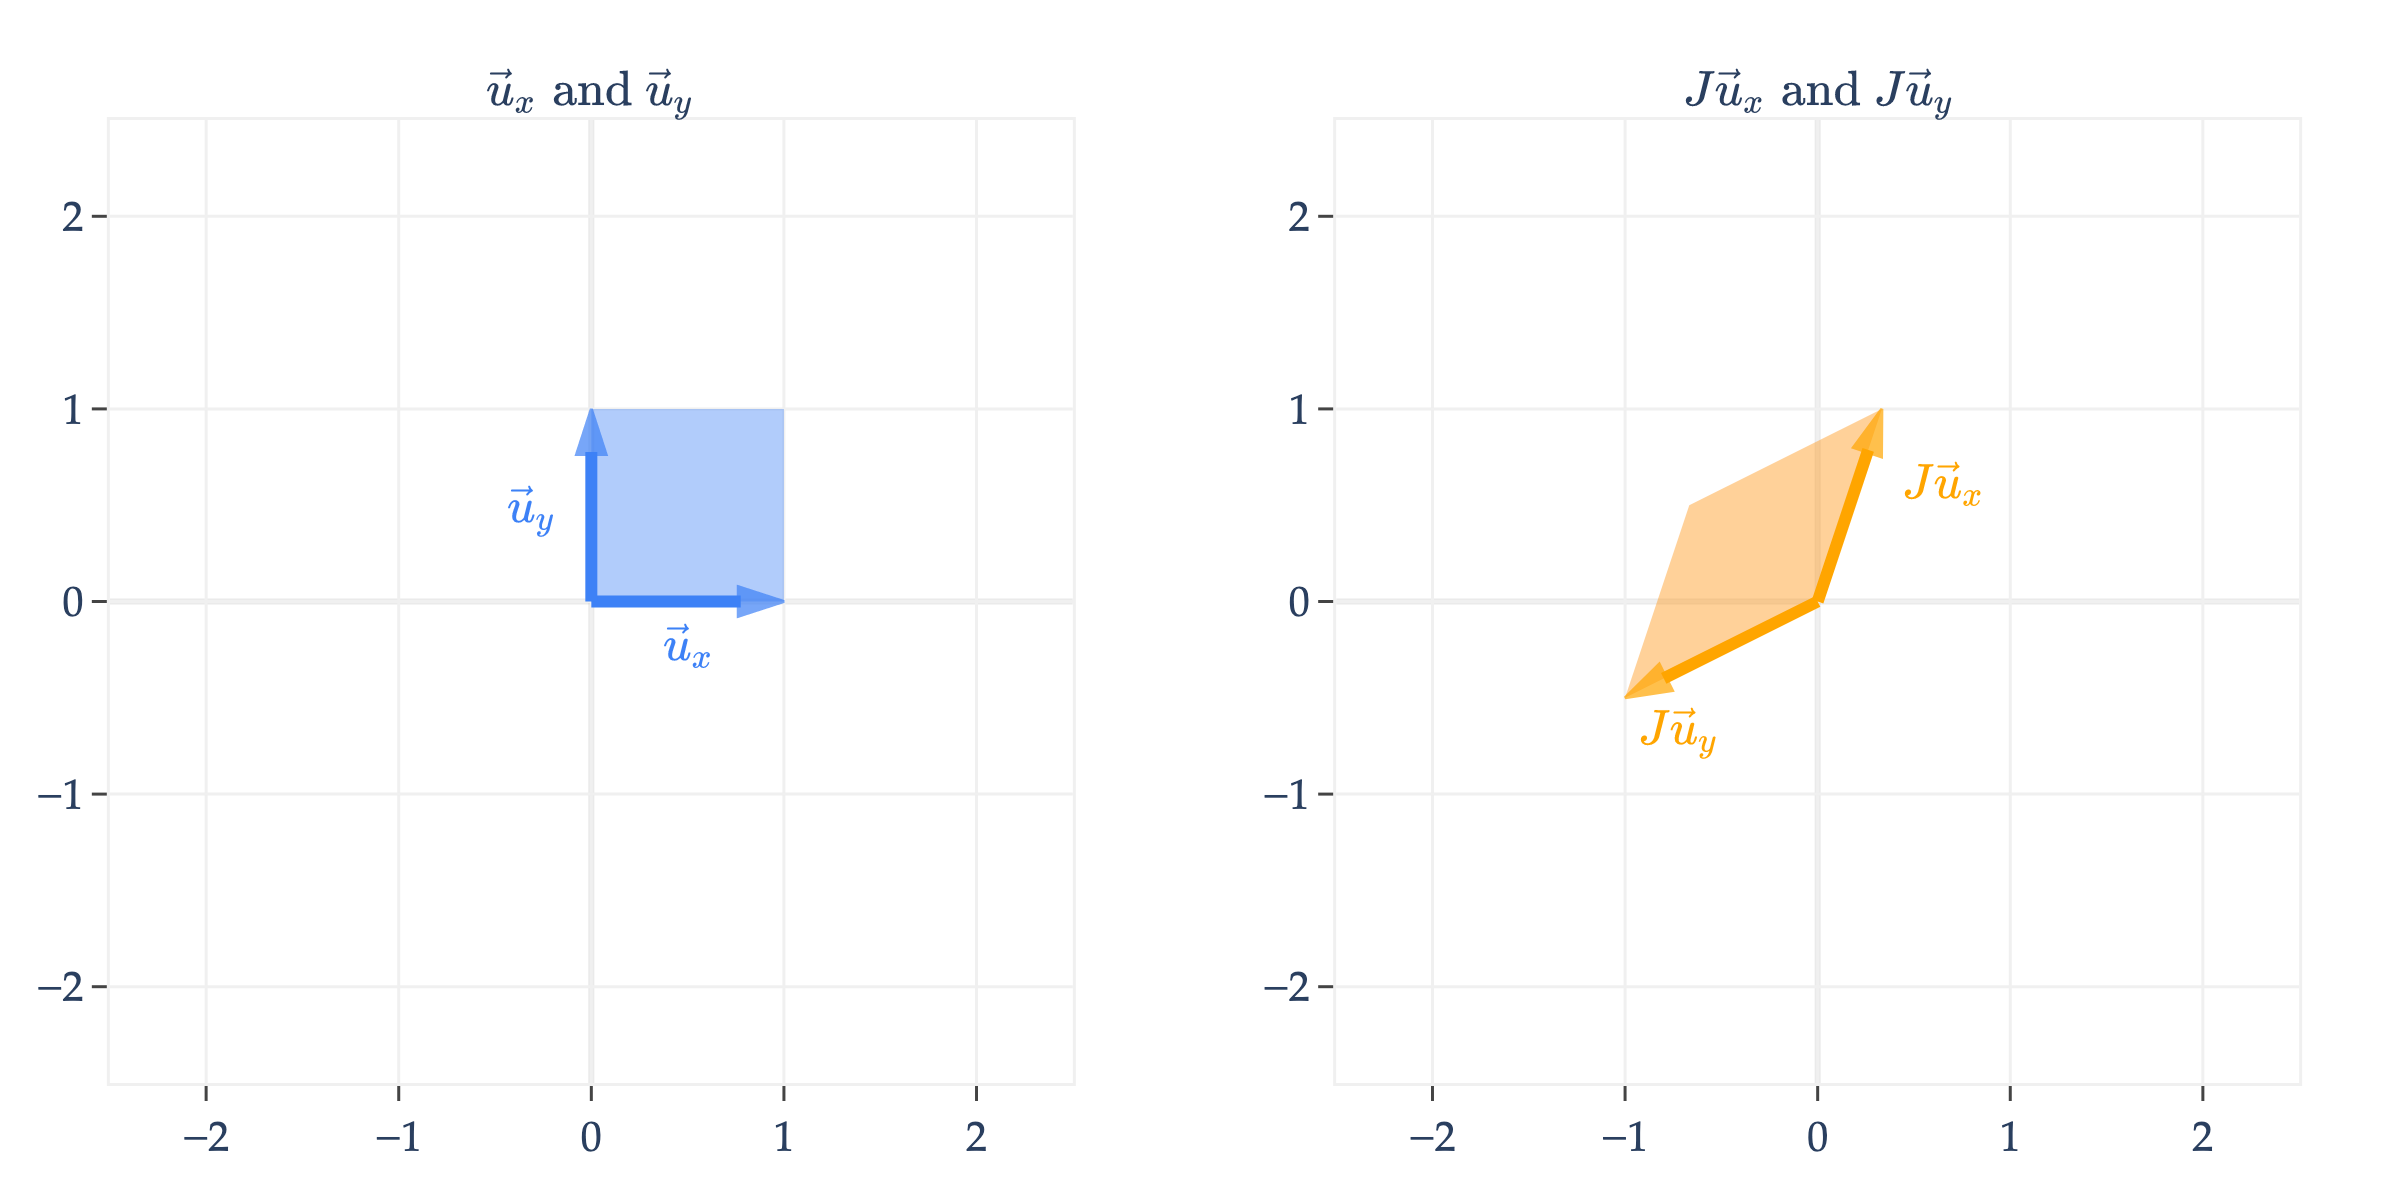

In [205]:
J = np.array([[1 / 3, -1], [1, -1 / 2]])
plot_unit_square_and_transform(J, name="J", vdeltay=0.45, vdeltax=-0.5)

$J$ turns the unit square into a **parallelogram**. In fact, so did $A$, $B$, $C$, $D$, $E$, and $F$; all of these transformations map the unit square to a parallelogram, with some additional properties (e.g. $A$'s parallelogram was a rectangle, $B$'s had equal sides, etc.).

There's no need to memorize the names of these transformations – after all, they only apply in $\mathbb{R}^2$ and perhaps $\mathbb{R}^3$ where we can visualize.

Speaking of $\mathbb{R}^3$, an arbitrary $3 \times 3$ matrix can be thought of as a transformation that maps the unit cube to a parallelepiped (the generalization of a parallelogram to three dimensions).

$$K = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 2 & 1/2 \\ 0 & -1 & 1 / 2 \end{bmatrix}$$

In [233]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from utils import plot_vectors

def plot_unit_cube_and_transform(S, name="Matrix", vdeltax=-0.3, vdeltay=0.2, vdeltaz=0.2):
    """
    Visualize the action of a 2x2 or 3x3 matrix S on the unit square/cube and basis vectors.
    For 2D, shows the unit square and its image; for 3D, shows the unit cube and its image.
    """
    S = np.asarray(S)
    dim = S.shape[0]
    assert S.shape[0] == S.shape[1], "Matrix must be square"
    assert dim in (2, 3), "Only 2D or 3D matrices supported"

    if dim == 2:
        # Vertices of the unit square (closed)
        square = np.array([
            [0, 0],  # A
            [1, 0],  # B
            [1, 1],  # C
            [0, 1],  # D
        ])
        square_closed = np.vstack([square, square[0]])  # for plotting outline if needed
        square_trans = (S @ square.T).T
        square_trans_closed = np.vstack([square_trans, square_trans[0]])

        fig = make_subplots(
            rows=1, cols=2,
            horizontal_spacing=0.08,
            subplot_titles=("Original Unit Square", f"Transformed by {name}")
        )

        axis_style = dict(
            showgrid=True,
            gridcolor="#eeeeee",
            zeroline=False,
            showline=True,
            linecolor="#eeeeee",
            mirror=True,
            ticks="",  # turn off axis ticks
            showticklabels=False,  # turn off axis tick labels
            tickfont=dict(family="Palatino, serif", size=14),
        )

        for i in [1, 2]:
            fig.update_xaxes(
                range=[-2.5, 2.5],
                constrain="domain",
                dtick=1,
                **axis_style,
                row=1, col=i
            )
            fig.update_yaxes(
                range=[-2.5, 2.5],
                scaleanchor=f"x{i}",
                dtick=1,
                **axis_style,
                row=1, col=i
            )

        # Draw gridlines at x=0 and y=0 in #ccc
        for i in [1, 2]:
            fig.add_shape(
                type="line",
                x0=-2.5, x1=2.5, y0=0, y1=0,
                line=dict(color="#cccccc", width=2, dash="solid"),
                row=1, col=i,
                layer="below"
            )
            fig.add_shape(
                type="line",
                x0=0, x1=0, y0=-2.5, y1=2.5,
                line=dict(color="#cccccc", width=2, dash="solid"),
                row=1, col=i,
                layer="below"
            )

        # Plot original unit square (shaded, no boundary)
        fig.add_trace(
            go.Scatter(
                x=square_closed[:,0], y=square_closed[:,1],
                fill="toself",
                fillcolor="rgba(61,129,246,0.25)",
                line=dict(color="rgba(0,0,0,0)", width=0),
                name="Unit Square",
                showlegend=False
            ),
            row=1, col=1
        )
        # Plot transformed square (shaded, no boundary)
        fig.add_trace(
            go.Scatter(
                x=square_trans_closed[:,0], y=square_trans_closed[:,1],
                fill="toself",
                fillcolor="rgba(255,140,0,0.25)",
                line=dict(color="rgba(0,0,0,0)", width=0),
                name="Transformed Square",
                showlegend=False
            ),
            row=1, col=2
        )

        # --- Draw vectors using plot_vectors ---
        u_x = np.array([1, 0])
        u_y = np.array([0, 1])
        Su_x = S @ u_x
        Su_y = S @ u_y

        # Only draw the border for the basis vectors
        left_vecs = [
            (tuple(u_x), '#3d81f6', None),
            (tuple(u_y), '#3d81f6', None)
        ]
        left_fig = plot_vectors(left_vecs, vdeltay=-0.2)
        left_fig.update_layout(
            plot_bgcolor="white",
            paper_bgcolor="white",
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            margin=dict(l=0, r=0, t=0, b=0)
        )
        for trace in left_fig.data:
            fig.add_trace(trace, row=1, col=1)

        right_vecs = [
            (tuple(Su_x), 'orange', None),
            (tuple(Su_y), 'orange', None)
        ]
        right_fig = plot_vectors(right_vecs, vdeltax=vdeltax, vdeltay=vdeltay)
        right_fig.update_layout(
            plot_bgcolor="white",
            paper_bgcolor="white",
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            margin=dict(l=0, r=0, t=0, b=0)
        )
        for trace in right_fig.data:
            fig.add_trace(trace, row=1, col=2)

        fig.update_layout(
            font=dict(family="Palatino, serif", size=16),
            plot_bgcolor="white",
            paper_bgcolor="white",
            margin=dict(l=20, r=20, t=40, b=20),
            width=600, height=300,
        )
        fig.show(renderer='png', scale=3)

    elif dim == 3:
        # Vertices of the unit cube (8 corners)
        cube = np.array([
            [0, 0, 0],  # 0
            [1, 0, 0],  # 1
            [1, 1, 0],  # 2
            [0, 1, 0],  # 3
            [0, 0, 1],  # 4
            [1, 0, 1],  # 5
            [1, 1, 1],  # 6
            [0, 1, 1],  # 7
        ])
        
        cube_trans = (S @ cube.T).T

        fig = make_subplots(
            rows=1, cols=2,
            specs=[[{'type': 'scene'}, {'type': 'scene'}]],
            horizontal_spacing=0.08,
            subplot_titles=("u<sub>x</sub>, u<sub>y</sub>, and u<sub>z</sub>", f"{name}u<sub>x</sub>, {name}u<sub>y</sub>, and {name}u<sub>z</sub>")
        )

        # Draw gridlines at x=0, y=0, z=0 in #ccc for both scenes
        for i in [1, 2]:
            # x=0 plane (y-z gridline)
            fig.add_trace(
                go.Scatter3d(
                    x=[0, 0], y=[-2.5, 2.5], z=[0, 0],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )
            fig.add_trace(
                go.Scatter3d(
                    x=[0, 0], y=[0, 0], z=[-2.5, 2.5],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )
            # y=0 plane (x-z gridline)
            fig.add_trace(
                go.Scatter3d(
                    x=[-2.5, 2.5], y=[0, 0], z=[0, 0],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )
            fig.add_trace(
                go.Scatter3d(
                    x=[0, 0], y=[0, 0], z=[-2.5, 2.5],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )
            # z=0 plane (x-y gridline)
            fig.add_trace(
                go.Scatter3d(
                    x=[-2.5, 2.5], y=[0, 0], z=[0, 0],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )
            fig.add_trace(
                go.Scatter3d(
                    x=[0, 0], y=[-2.5, 2.5], z=[0, 0],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )

        # Create mesh for the original cube (all vertices at once)
        # Define faces using vertex indices - i, j, k for triangulation
        i = [0, 0, 0, 0, 1, 1, 2, 2, 4, 4, 5, 5]
        j = [1, 3, 1, 3, 2, 5, 3, 6, 5, 7, 6, 7]
        k = [2, 7, 5, 4, 6, 6, 7, 7, 6, 6, 1, 4]
        
        fig.add_trace(
            go.Mesh3d(
                x=cube[:,0], y=cube[:,1], z=cube[:,2],
                i=i, j=j, k=k,
                color="rgba(61,129,246,0.25)",
                opacity=0.7,
                flatshading=True,
                showscale=False,
                hoverinfo='skip',
                name="Unit Cube",
                showlegend=False,
                lighting=dict(ambient=0.5, diffuse=0.7, specular=0.2, roughness=0.7, fresnel=0.1),
                lightposition=dict(x=2, y=2, z=4)
            ),
            row=1, col=1
        )
        
        # Create mesh for the transformed cube
        fig.add_trace(
            go.Mesh3d(
                x=cube_trans[:,0], y=cube_trans[:,1], z=cube_trans[:,2],
                i=i, j=j, k=k,
                color="rgba(255,140,0,0.25)",
                opacity=0.7,
                flatshading=True,
                showscale=False,
                hoverinfo='skip',
                name="Transformed Cube",
                showlegend=False,
                lighting=dict(ambient=0.5, diffuse=0.7, specular=0.2, roughness=0.7, fresnel=0.1),
                lightposition=dict(x=2, y=2, z=4)
            ),
            row=1, col=2
        )

        # --- Draw vectors using plot_vectors ---
        u_x = np.array([1, 0, 0])
        u_y = np.array([0, 1, 0])
        u_z = np.array([0, 0, 1])
        Su_x = S @ u_x
        Su_y = S @ u_y
        Su_z = S @ u_z

        # Only draw the border for the basis vectors
        left_vecs = [
            (tuple(u_x), '#3d81f6', None),
            (tuple(u_y), '#3d81f6', None),
            (tuple(u_z), '#3d81f6', None)
        ]
        left_fig = plot_vectors(left_vecs, vdeltay=-0.2, vdeltaz=-0.2)
        left_fig.update_layout(
            scene=dict(
                xaxis=dict(visible=False, showticklabels=False, ticks=""),
                yaxis=dict(visible=False, showticklabels=False, ticks=""),
                zaxis=dict(visible=False, showticklabels=False, ticks=""),
                bgcolor="white"
            ),
            margin=dict(l=0, r=0, t=0, b=0),
            paper_bgcolor="white",
            plot_bgcolor="white"
        )
        for trace in left_fig.data:
            fig.add_trace(trace, row=1, col=1)

        # Only draw the border for the transformed basis vectors
        right_vecs = [
            (tuple(Su_x), 'orange', None),
            (tuple(Su_y), 'orange', None),
            (tuple(Su_z), 'orange', None)
        ]
        right_fig = plot_vectors(right_vecs, vdeltax=vdeltax, vdeltay=vdeltay, vdeltaz=vdeltaz)
        right_fig.update_layout(
            scene=dict(
                xaxis=dict(visible=False, showticklabels=False, ticks=""),
                yaxis=dict(visible=False, showticklabels=False, ticks=""),
                zaxis=dict(visible=False, showticklabels=False, ticks=""),
                bgcolor="white"
            ),
            margin=dict(l=0, r=0, t=0, b=0),
            paper_bgcolor="white",
            plot_bgcolor="white"
        )
        for trace in right_fig.data:
            fig.add_trace(trace, row=1, col=2)

        # Set axis ranges and aspect for both scenes with WHITE background
        for i in [1, 2]:
            fig.update_scenes(
                xaxis=dict(range=[-2.5, 2.5], backgroundcolor="white", showgrid=True, gridcolor="#eeeeee", zeroline=False, showline=True, linecolor="#eeeeee", mirror=True, ticks="", showticklabels=False, dtick=1, tickfont=dict(family="Palatino, serif", size=14)),
                yaxis=dict(range=[-2.5, 2.5], backgroundcolor="white", showgrid=True, gridcolor="#eeeeee", zeroline=False, showline=True, linecolor="#eeeeee", mirror=True, ticks="", showticklabels=False, dtick=1, tickfont=dict(family="Palatino, serif", size=14)),
                zaxis=dict(range=[-2.5, 2.5], backgroundcolor="white", showgrid=True, gridcolor="#eeeeee", zeroline=False, showline=True, linecolor="#eeeeee", mirror=True, ticks="", showticklabels=False, dtick=1, tickfont=dict(family="Palatino, serif", size=14)),
                aspectmode="cube",
                row=1, col=i
            )

        fig.update_layout(
            font=dict(family="Palatino, serif", size=16),
            plot_bgcolor="white",
            paper_bgcolor="white",
            margin=dict(l=20, r=20, t=40, b=20),
            width=700, height=350,
        )
        fig.show()

# Example usage:
A3 = np.array([[1,0,0],
               [0,2,1/2],
               [0,-1,0.5]])
plot_unit_cube_and_transform(A3, name="K")

What do you notice about the transformation defined by $L$, and how it relates to $L$'s columns? (Drag the plot around to see the main point.)

$$L = \begin{bmatrix} 1 & 1/2 & 0 \\ 1 & 1/2 & 0 \\ 1 & 1/2 & 1 \end{bmatrix}$$

In [295]:
A3 = np.array([[1,1/2,0],
               [1,1/2,0],
               [1,1/2,1]])
plot_unit_cube_and_transform(A3, name="L")

Since $L$'s columns are linearly **dependent**, $L$ maps the unit cube to a flat parallelo**gram**.


### The Determinant

It turns out that there's a formula for

- **area of the parallelogram** formed by transforming the unit square by a $2 \times 2$ matrix $A$
- **volume of the parallelepiped** formed by transforming the unit cube by a $3 \times 3$ matrix $A$
- in general, the $n$-dimensional "volume" of the object formed by transforming the unit $n$-cube by an $n \times n$ matrix $A$

That formula is called the **determinant** of $A$, and is denoted $\text{det}(A)$.

Why do we care? Remember, the goal of this section is to find the inverse of a square matrix $A$, if it exists, and the determinant will give us one way to check if it does.

In the case of the projection matrices $G$ and $H$ above, we saw that their columns were linearly dependent, and so the transformations $G$ and $H$ mapped the unit square to a **line with no area**. Similarly above, $L$ mapped the unit cube to a flat parallelogram with **no volume**. In all other transformations, the matrices' columns were linearly independent, so the resulting object had a non-zero area (in the case of $2 \times 2$ matrices) or volume (in the case of $3 \times 3$ matrices).

:::{attention} If $\text{det}(A) = 0$, $A$'s columns are linearly **dependent**!
Equivalently, if $\text{det}(A) \neq 0$, $A$'s columns are linearly **independent**. This will help us check if $A$ is invertible in just a moment.
:::

So, how do we find $\text{det}(A)$? Unfortunately, the formula is only convenient for $2 \times 2$ matrices.

:::{note} Definition: Determinant of a $2 \times 2$ matrix
If $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$, its determinant is

$$\text{det}(A) = \begin{vmatrix} a & b \\ c & d \end{vmatrix} = ad - bc$$
:::

For example, in the transformation

$$J = \begin{bmatrix} 1 / 3 & -1 \\ 1 & -1 / 2 \end{bmatrix}$$

the area of the parallelogram formed by transforming the unit square is

$$\text{det}(J) = \frac{1}{3}\left(-\frac{1}{2}\right) - (-1)(1) = -\frac{1}{6} + 1 = \frac{5}{6}$$

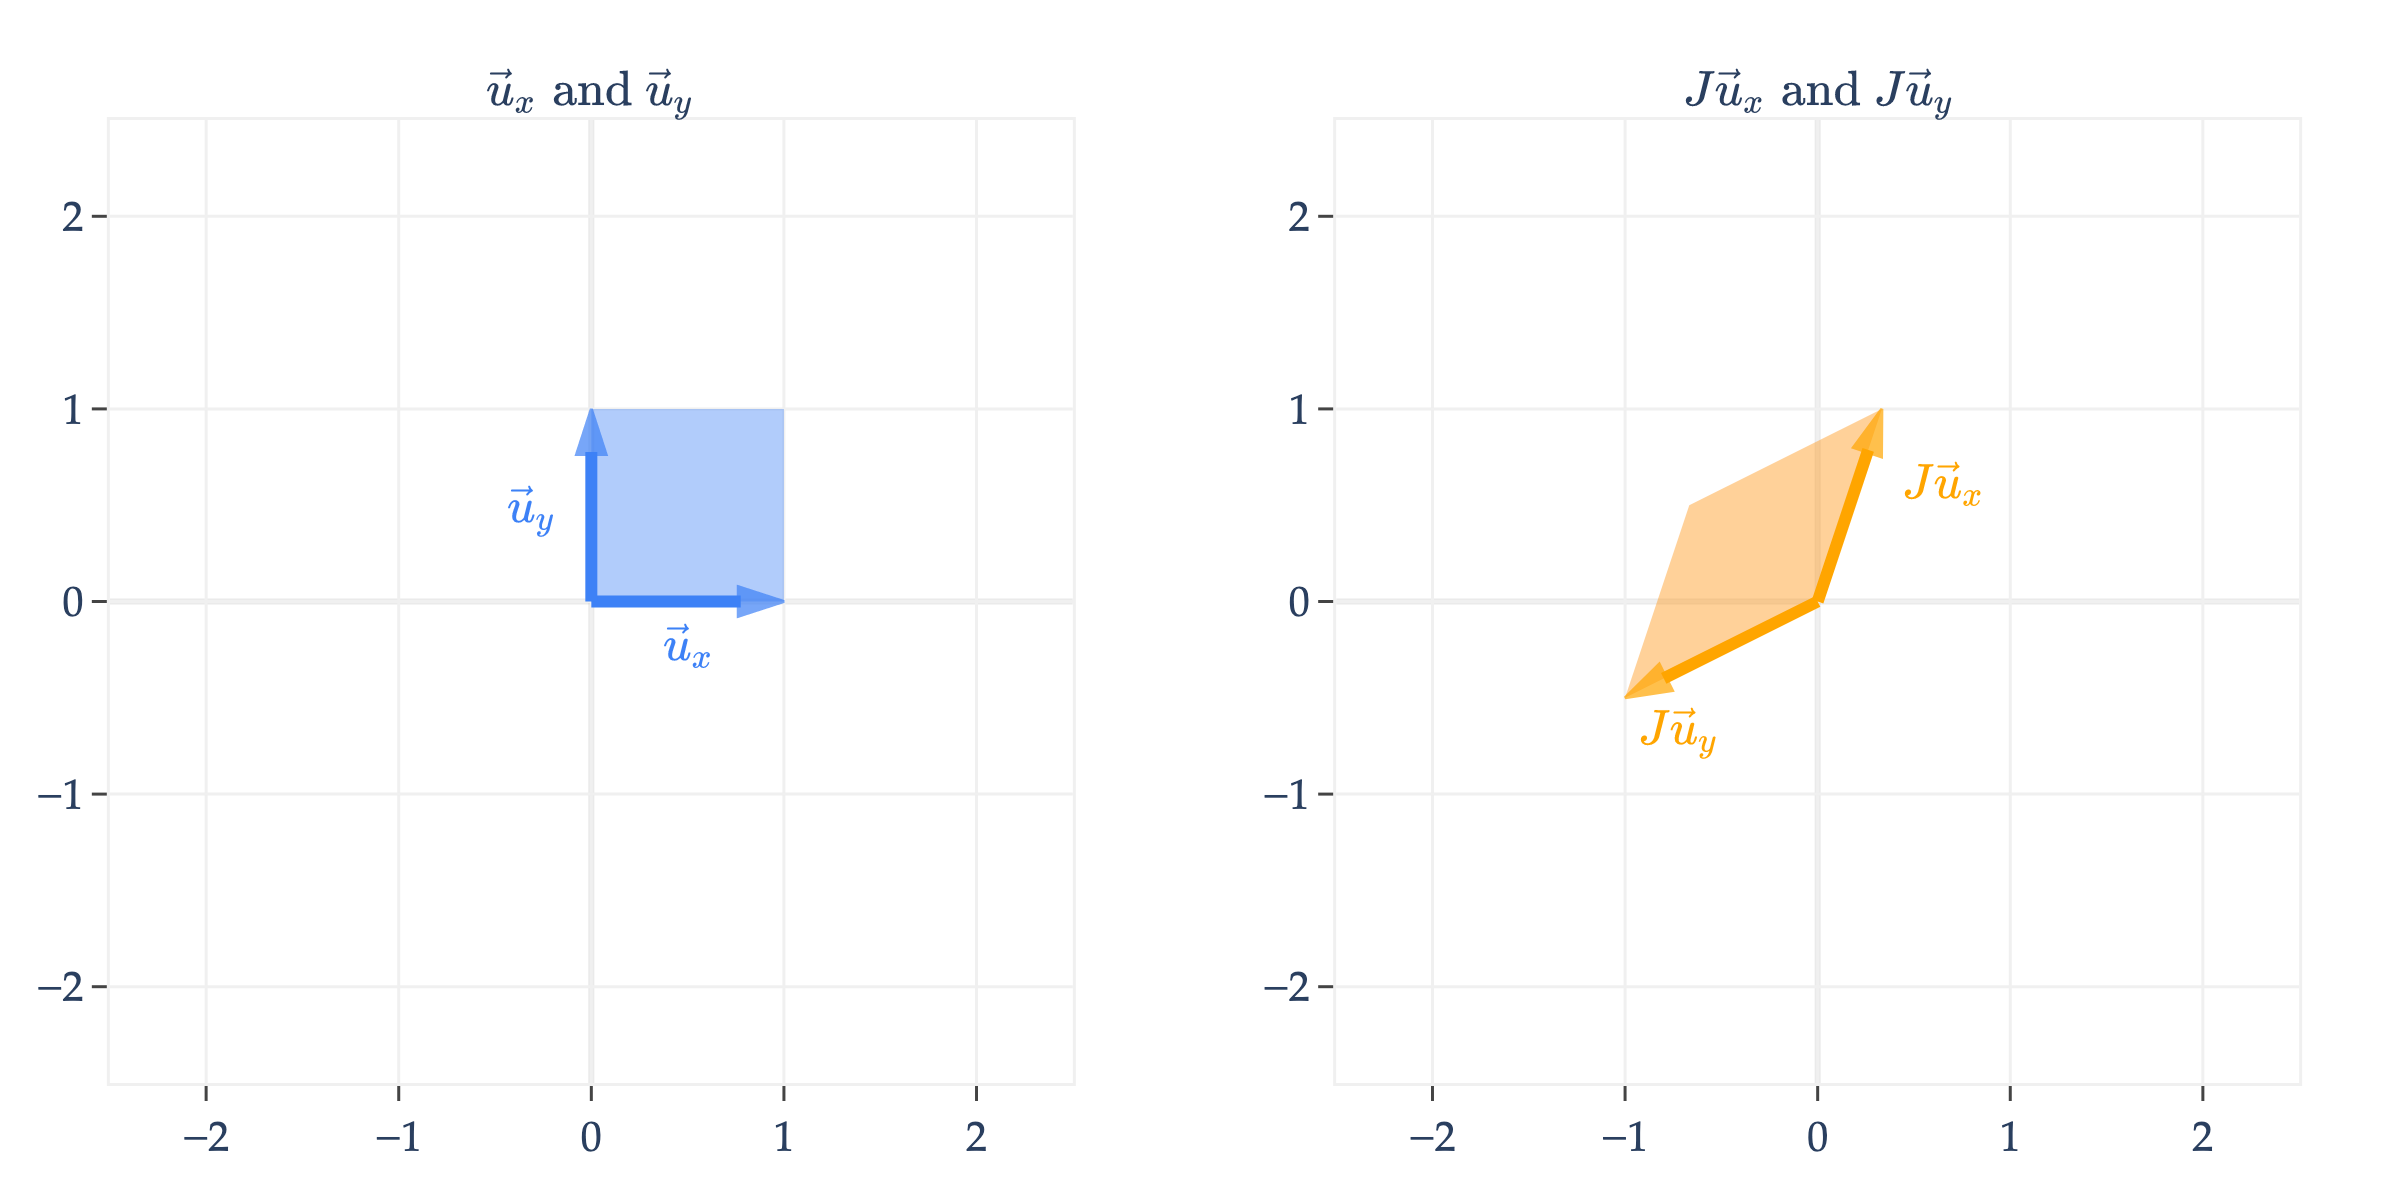

In [236]:
J = np.array([[1 / 3, -1], [1, -1 / 2]])
plot_unit_square_and_transform(J, name="J", vdeltay=0.45, vdeltax=-0.5)

Note that a determinant **can be negative**! So, to be precise, $|\text{det}(A)|$ describes the $n$-dimensional volume of the object formed by transforming the unit $n$-cube by $A$.

The sign of the determinant depends on the order of the columns of the matrix. For example, swap the columns of $J$ and its determinant would be $-\frac{5}{6}$. (If $A \vec u_x$ is "to the right" of $A \vec u_y$, the determinant is positive, like with the standard basis vectors; if $A \vec u_x$ is "to the left" of $A \vec u_y$, the determinant is negative.)

The determinant of an $n \times n$ matrix can be expressed recursively using a weighted sum of determinants of smaller $n-1 \times n-1$ matrices, called minors. For example, if $A$ is the $3 \times 3$ matrix

$$A = \begin{bmatrix} {\color{3d81f6} a} & {\color{3d81f6} b} & {\color{3d81f6} c} \\ {\color{orange} d} & {\color{d81a60}e } & {\color{004d40}f } \\ {\color{orange} g} & {\color{d81a60}h } & {\color{004d40}i } \end{bmatrix}$$

then $\text{det}(A)$ is

$$\text{det}(A) = {\color{3d81f6} a} \begin{vmatrix} {\color{d81a60}e } & {\color{004d40}f } \\ {\color{d81a60}h } & {\color{004d40}i } \end{vmatrix} - {\color{3d81f6} b} \begin{vmatrix} {\color{orange} d} & {\color{004d40}f } \\ {\color{orange} g} & {\color{004d40}i } \end{vmatrix} + {\color{3d81f6} c} \begin{vmatrix} {\color{orange} d} & {\color{d81a60}e } \\ {\color{orange} g} & {\color{d81a60}h } \end{vmatrix}$$

The matrix $\begin{bmatrix} e & f \\ h & i \end{bmatrix}$ is a minor of $A$; it's formed by deleting the first row and first column of $A$. Note the alternating signs in the formula. This formula generalizes to $n \times n$ matrices, but is not practical for anything larger than $3 \times 3$. (What is the runtime of this algorithm?)

The computation of the determinant is not super important. **The big idea is that the determinant of $A$ is a single number that tells us whether $A$'s transformation "loses a dimension" or not.**

Some useful properties of the determinant are that, for any $n \times n$ matrices $A$ and $B$,

1. $\text{det}(A) = \text{det}(A^T)$
1. $\text{det}(AB) = \text{det}(A) \text{det}(B)$
1. $\text{det}(cA) = c^n \text{det}(A)$ (notice the exponent!)
1. If $B$ results from swapping two of $A$'s columns (or rows), then $$\text{det}(B) = -\text{det}(A)$$

The proofs of these properties are beyond the scope of our course. But, it's worthwhile to think about what they mean in English in the context of linear transformations.

1. $\text{det}(A) = \text{det}(A^T)$ implies that the rows of $A$ (which are the columns of $A^T$) create the same "volume" as the columns of $A$.
1. $\text{det}(AB) = \text{det}(A) \text{det}(B)$ matches our intuition that linear transformations can be composed. $AB \vec x$ is the result of applying $B$ to $\vec x$, then $A$ to the result.
1. $\text{det}(cA) = c^n \text{det}(A)$ multiplies each column of $A$ by $c$, and so the volume of the resulting object is scaled by $c \times c \times \cdots \times c = c^n$.
1. If $B$ results from swapping two of $A$'s columns (or rows), then $$\text{det}(B) = -\text{det}(A)$ reflects that swapping two columns reverses the orientation of the transformation, flipping the signed volume from positive to negative (or vice versa) while preserving its magnitude.

:::{tip} Activity 2
:class: dropdown

**Activity 2.1**

Find the determinant of the following matrices:

1. $A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$
1. $A = \begin{bmatrix} 1 & 3 \\ 2 & 4 \end{bmatrix}$
1. $A = \begin{bmatrix} 2 & 1 \\ 4 & 3 \end{bmatrix}$
1. $A = \begin{bmatrix} 4 & 2 & 0 \\ 3 & 1 & 1 \\ -6 & 2 & 5 \end{bmatrix}$

**Activity 2.2**

Suppose $A$ and $B$ are both $n \times n$ matrices. Is $\text{det}(A + B) = \text{det}(A) + \text{det}(B)$ in general?

**Activity 2.3**

Suppose we multiply $A$'s 2nd column by 3. What happens to $\text{det}(A)$?

**Activity 2.4**

If $A$'s columns are linearly dependent, then find $\text{det}(AB)$.

**Activity 2.5**

1. Find the determinant of $R(\theta) = \begin{bmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{bmatrix}$ (Hint: The answer does not depend on $\theta$!).
1. $R(\theta)$ is a $2 \times 2$ orthogonal matrix. If $Q$ is an $n \times n$ orthogonal matrix, then what is $\text{det}(Q)$?

:::

---

## Inverting a Transformation

Remember, the big goal of this section is to find the inverse of a square matrix $A$. 

Since a square matrix $A$ corresponds to a linear transformation, we can think of $A^{-1}$ as "reversing" or "undoing" the transformation.

For example, if $A$ scales vectors, $A^{-1}$ should scale by the reciprocal, so that applying $A$ and then $A^{-1}$ returns the original vector.

The simplest case involves a diagonal matrix, like

$$A = \begin{bmatrix} 2 & 0 \\ 0 & -1/3 \end{bmatrix}$$

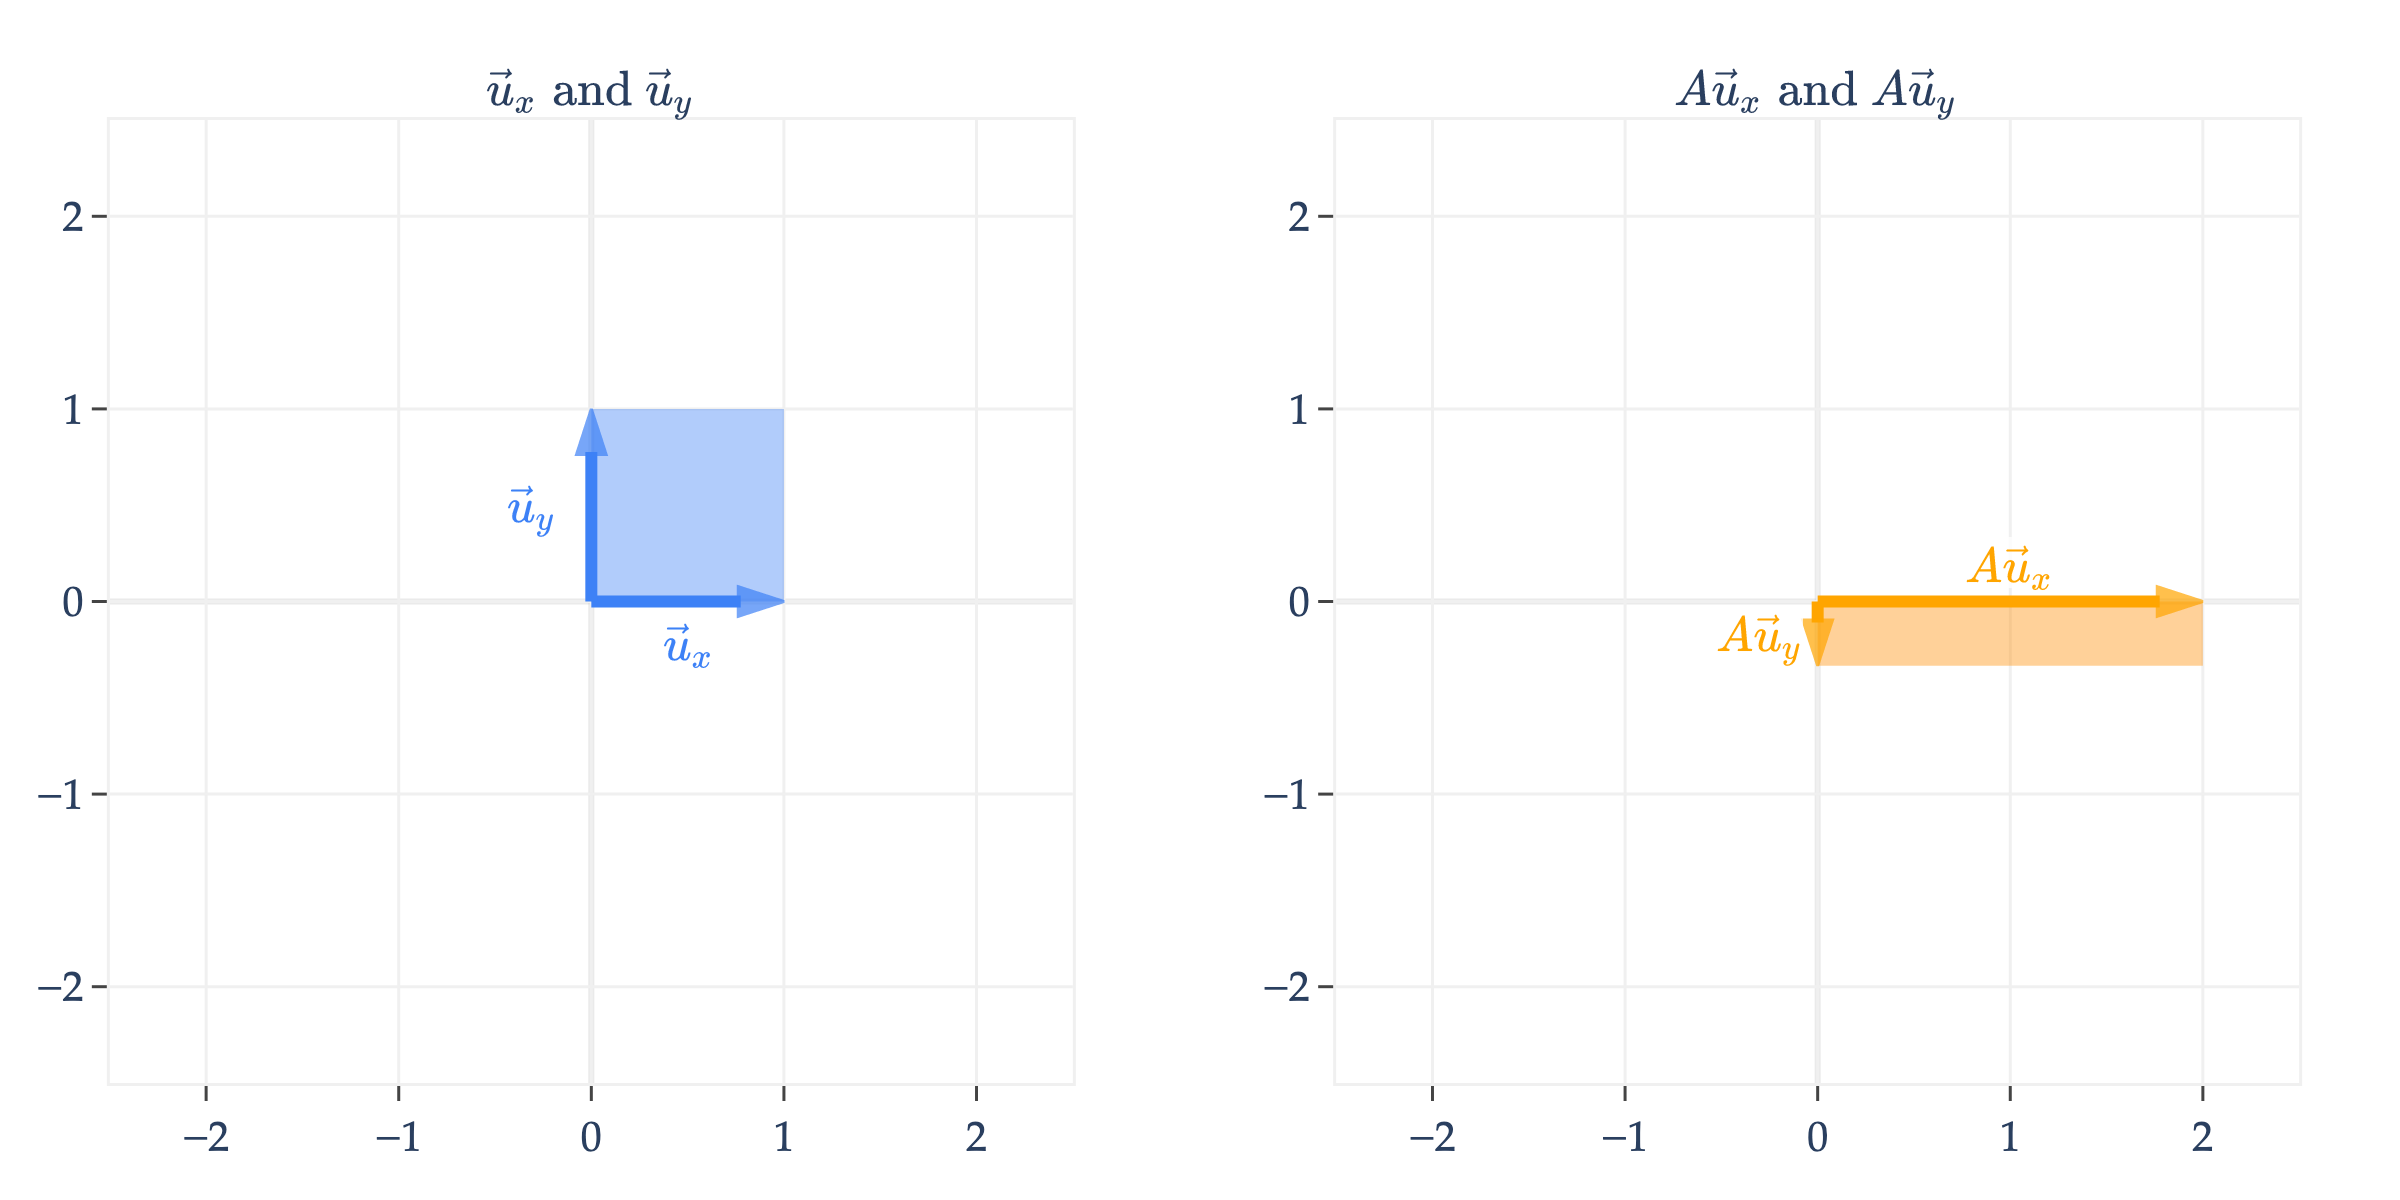

In [237]:
A = np.array([[2, 0], [0, -1/3]])
plot_unit_square_and_transform(A, name="A")

To undo the effect of $A$, we can apply the transformation

$$A^{-1} = \begin{bmatrix} 1/2 & 0 \\ 0 & -3 \end{bmatrix}$$

Many of the transformations we looked at involving $2 \times 2$ matrices are reversible, and hence the corresponding matrices are invertible. If the matrix rotates by $\theta$, the inverse is a rotation by $-\theta$. If the matrix shears by "dragging to the right", the inverse is a shear by "dragging to the left".

Another way of visualizing whether a transformation is reversible is whether <span style="color:#d81a60; font-weight:bold">given a vector on the right</span>, there is <span style="color:#d81a60; font-weight:bold">exactly one corresponding vector on the left</span>. By exactly one, I mean not 0, and not multiple.

Here, we visualize

$$F = \begin{bmatrix} 1 & 0 \\ -5/4 & 1 \end{bmatrix}$$

Given any vector $\vec b$ of the form $\vec b = F \vec x$, there is **exactly one** vector $\vec x$ that satisfies this equation.

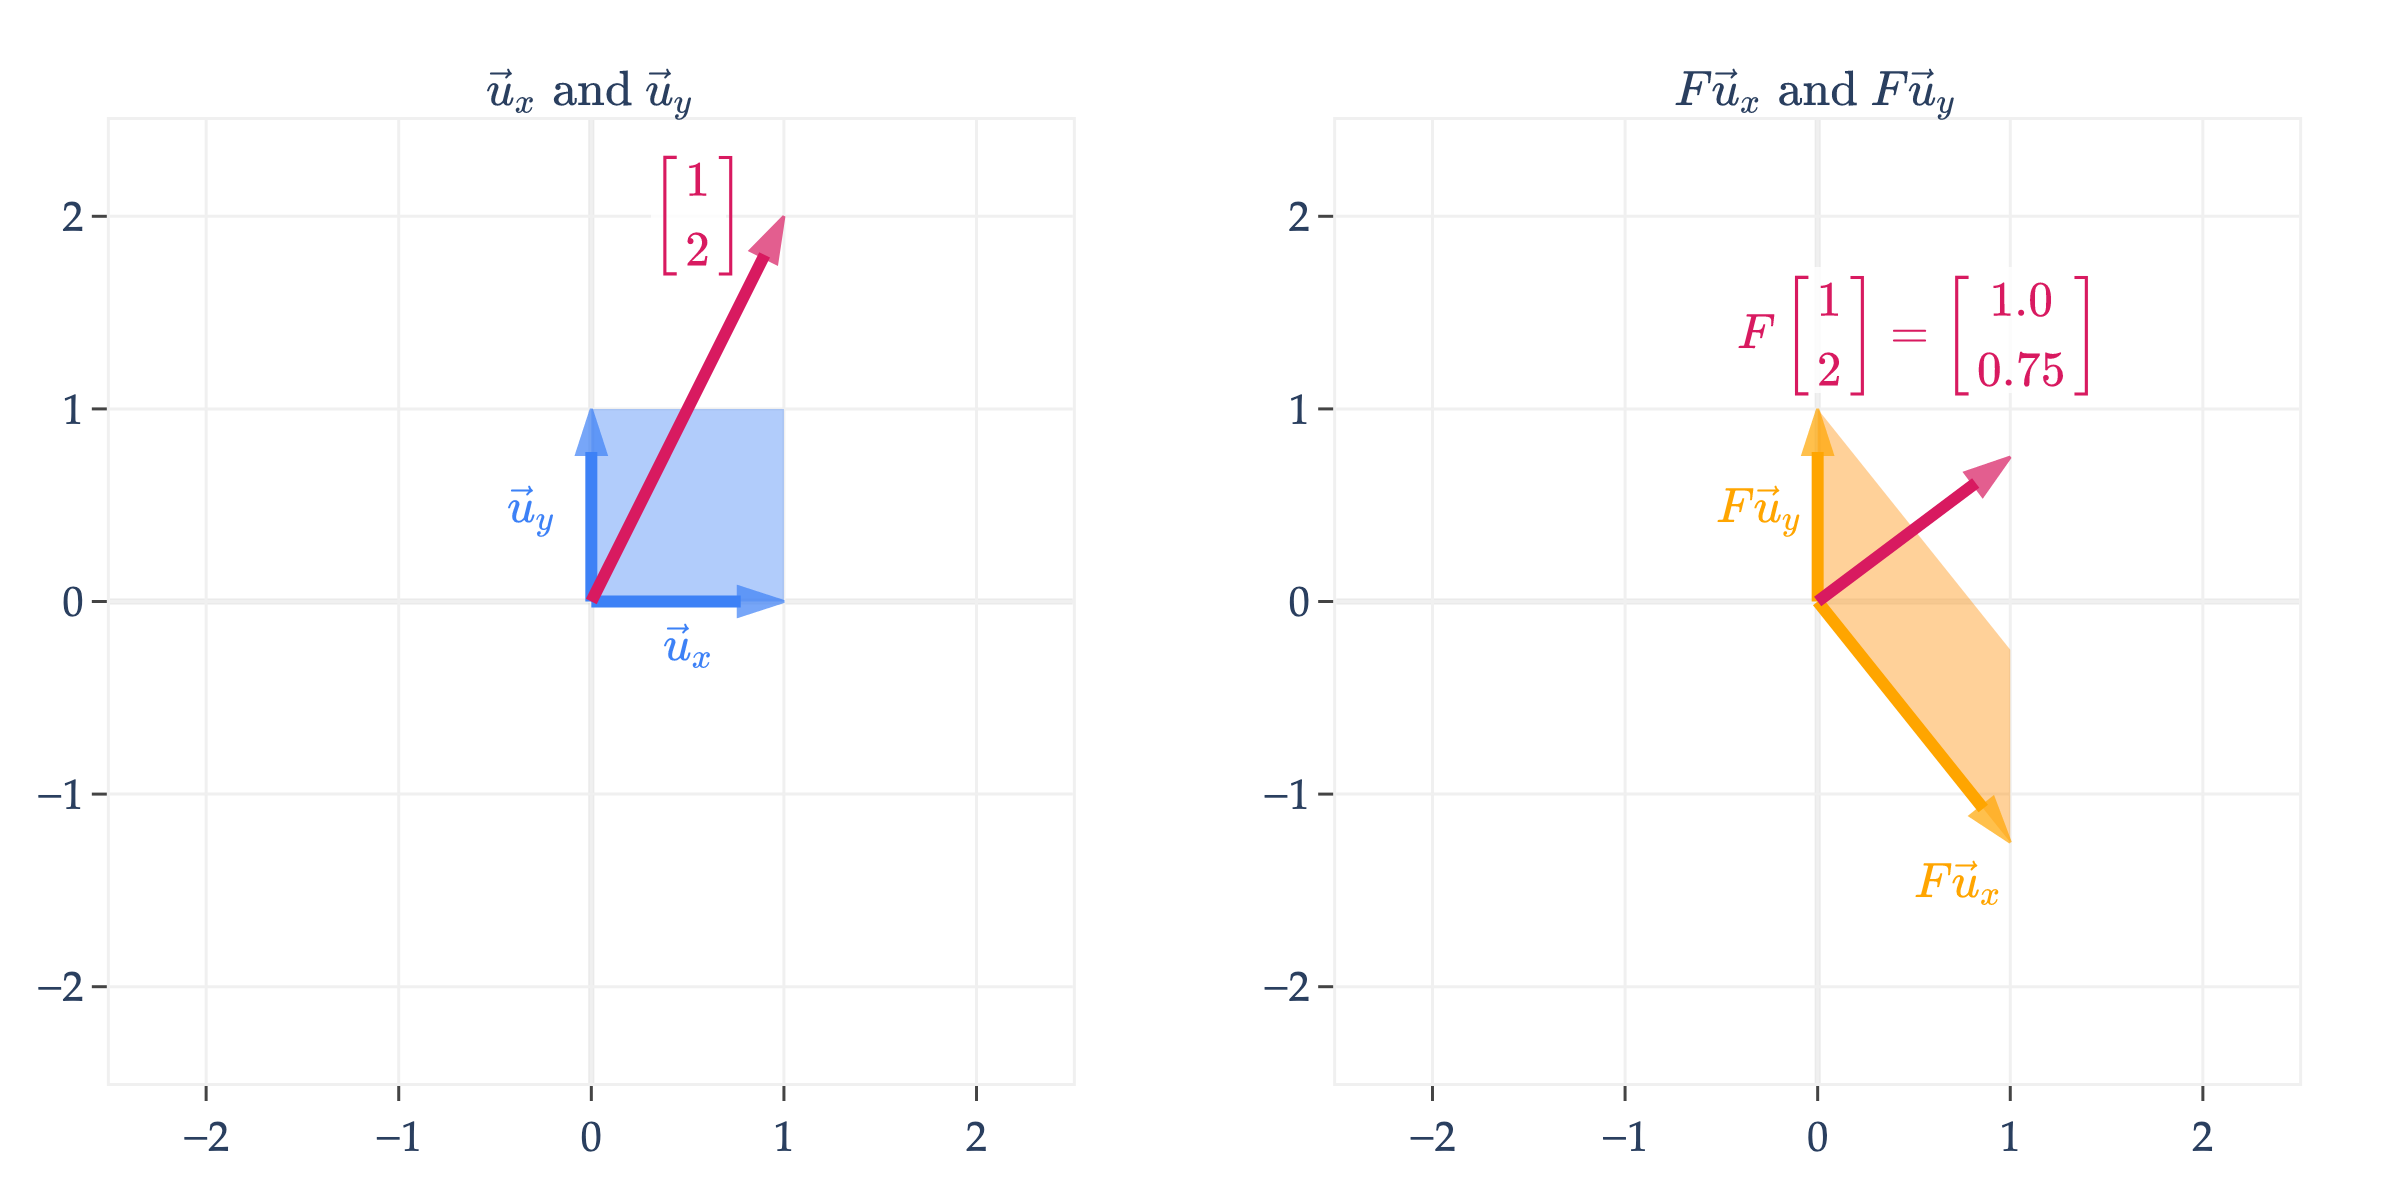

In [42]:
F = np.array([[1, 0], [-5 / 4, 1]])
# The vector to highlight
vec = np.array([1, 2])
# Its transformed position as a vector (i.e. F @ vec)
vec_trans = F @ vec

# Plot the transformation and get the figure object
fig = plot_unit_square_and_transform(
    F, 
    name="F", 
    vdeltay=-1.3, 
    vdeltax=0.3,
    return_fig=True
)

# Use add_vectors_to_subplot to overlay the original and transformed vectors
add_vectors_to_subplot(
    fig,
    list_of_vecs=[vec],
    start_points=[np.array([0, 0])],
    colors=["#d81a60"],
    labels=[fr"$\begin{{bmatrix}} {vec[0]} \\ {vec[1]} \end{{bmatrix}}$"],
    row=1, col=1,
    vdeltay=2.3
)

add_vectors_to_subplot(
    fig,
    list_of_vecs=[vec_trans],
    start_points=[np.array([0, 0])],
    colors=["#d81a60"],
    labels=[fr"$F\begin{{bmatrix}} {vec[0]} \\ {vec[1]} \end{{bmatrix}} = \begin{{bmatrix}} {vec_trans[0]} \\ {vec_trans[1]} \end{{bmatrix}}$"],
    row=1, col=2,
    vdeltay=1.3
)

fig.show(renderer='png', scale=3)

On the other hand, if we look at

$$H = \begin{bmatrix} 1 / 2 & -1 \\ 1 & -2 \end{bmatrix}$$

the same does not hold true. Given any vector $\vec b \in \text{colsp}(H)$ on the right, there are infinitely many vectors $\vec x$ such that $H \vec x = \vec b$. <span style="color:#d81a60; font-weight:bold">The vectors in pink on the left are all sent to the same vector on the right,</span> $\color{#d81a60}{\begin{bmatrix} -1 \\\\ -2 \end{bmatrix}}$.

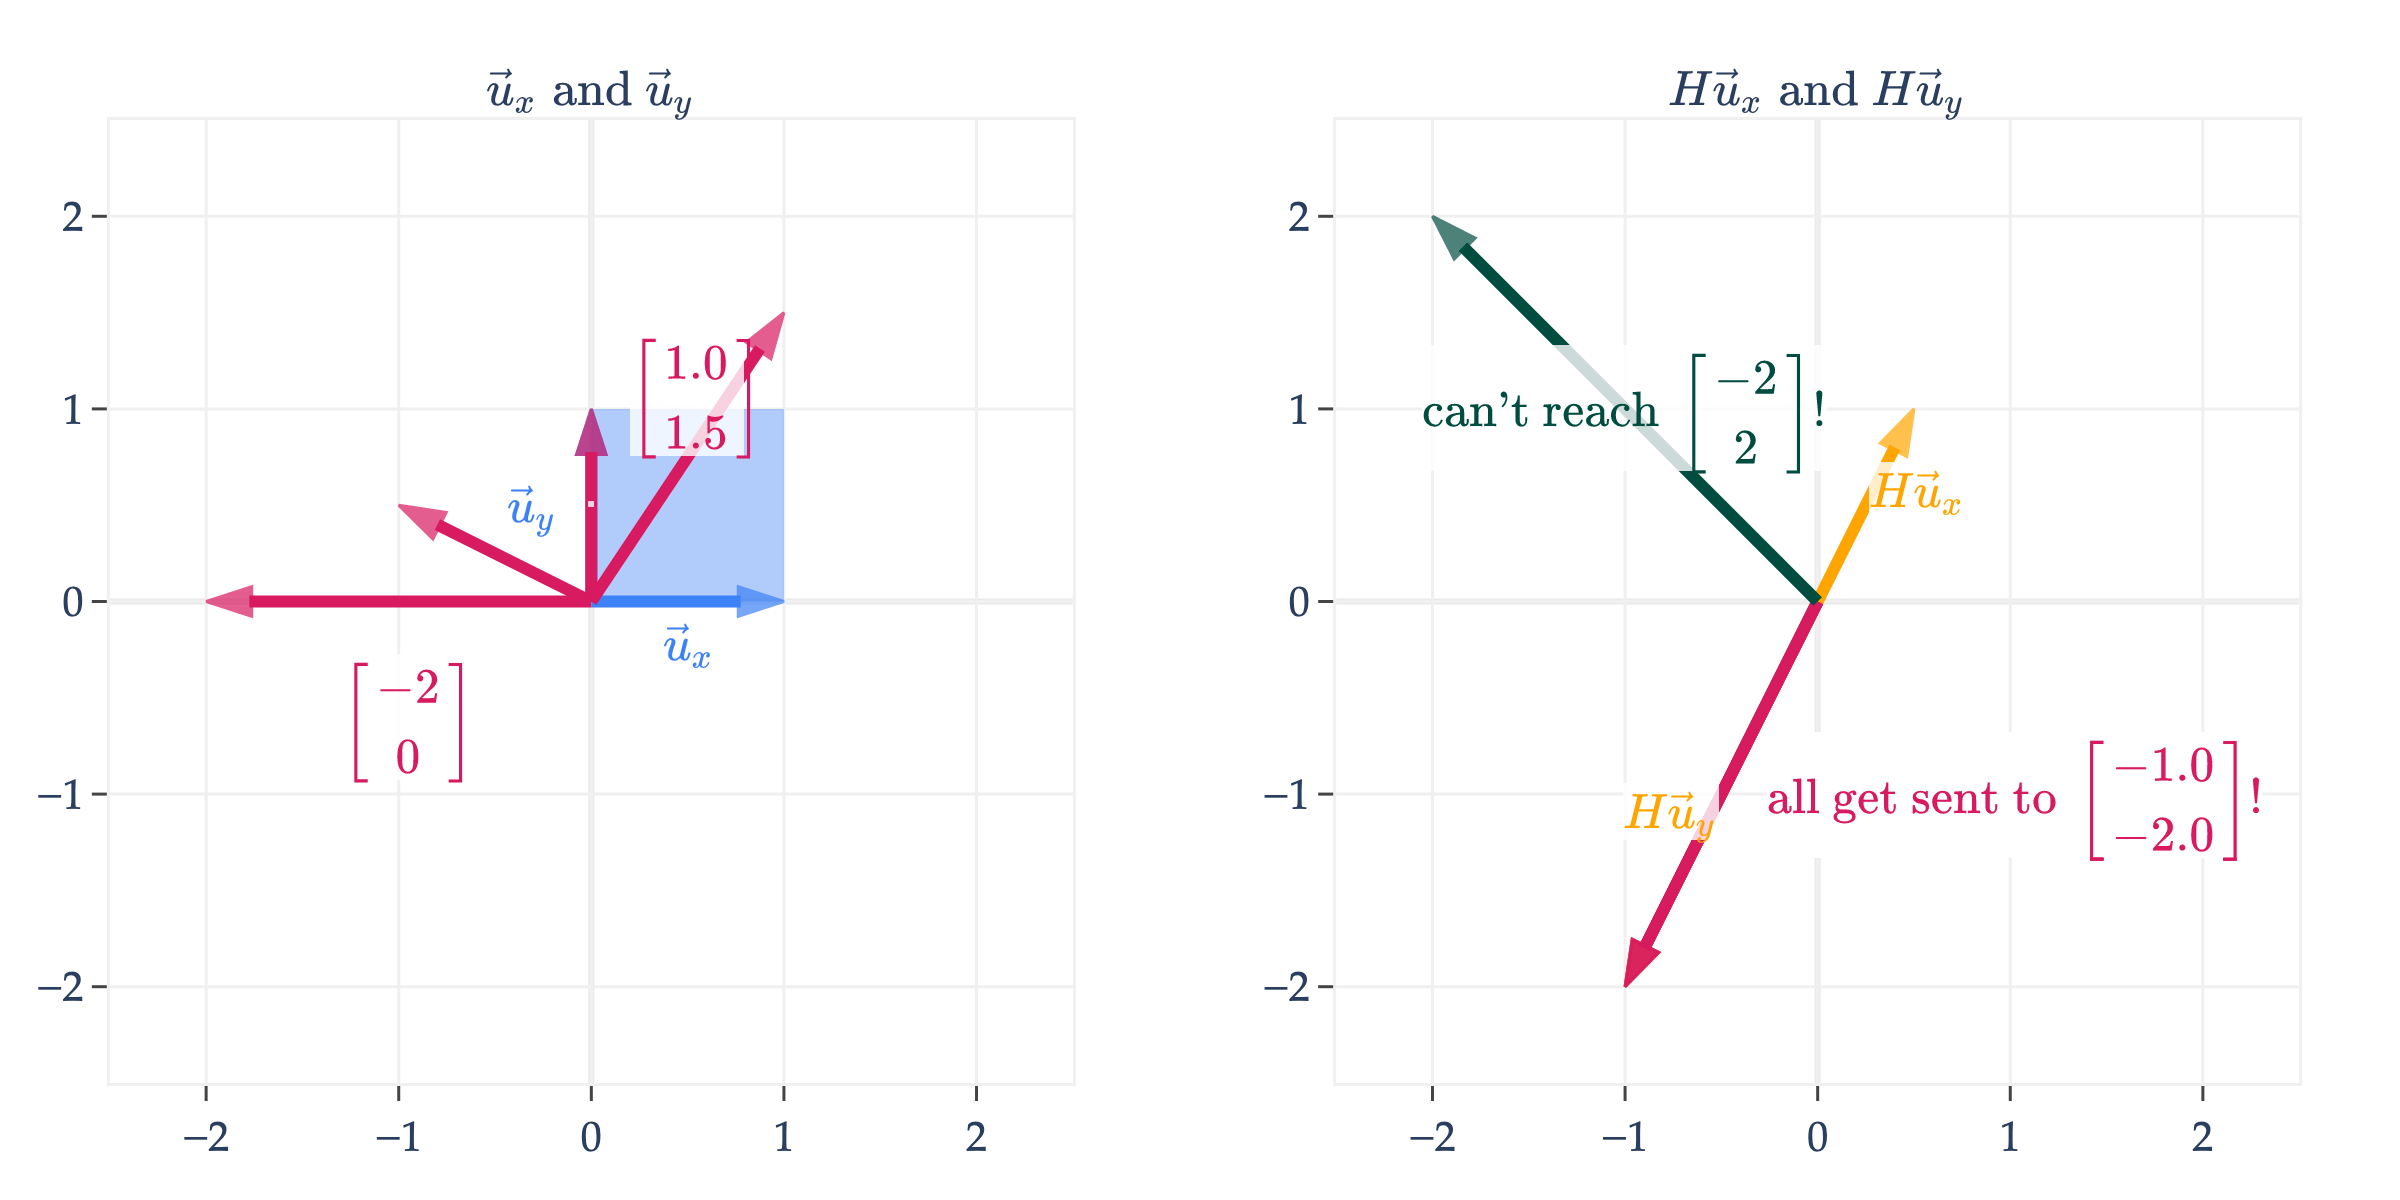

In [67]:
H = np.array([[1 / 2, -1], [1, -2]])

# Points to highlight
pts = [np.array([0, 1]), np.array([1, 1.5]), np.array([-1, 0.5]), np.array([-2, 0])]
# Their transformed positions
pts_trans = [H @ pt for pt in pts]

# Plot the transformation and get the figure object
fig = plot_unit_square_and_transform(
    H, 
    name="H", 
    return_fig=True
)

# Use add_vectors_to_subplot to overlay the original points on the left (input) subplot
add_vectors_to_subplot(
    fig,
    list_of_vecs=pts,
    start_points=[np.array([0, 0]) for _ in pts],
    colors=["#d81a60"] * len(pts),
    labels=[
        fr"$\begin{{bmatrix}} {pt[0]} \\ {pt[1]} \end{{bmatrix}}$" if i in [3, 1] else ""
        for i, pt in enumerate(pts)
    ],
    row=1, col=1,
    vdeltay=0.6
)

# Use add_vectors_to_subplot to overlay the transformed points on the right (output) subplot
# We want to show that all points get sent to the same output
labels_right = [
    fr"$\text{{all get sent to }} \begin{{bmatrix}} {pt_t[0]} \\ {pt_t[1]} \end{{bmatrix}}!$"
    for pt_t in pts_trans
]
add_vectors_to_subplot(
    fig,
    list_of_vecs=pts_trans,
    start_points=[np.array([0, 0]) for _ in pts_trans],
    colors=["rgba(216, 26, 96, 0.7)"] * len(pts_trans),
    labels=labels_right,
    row=1, col=2,
    vdeltay=0,
    vdeltax=1.7
)

# Show a point that can't be reached
add_vectors_to_subplot(
    fig,
    list_of_vecs=[np.array([-2, 2])],
    start_points=[np.array([0, 0])],
    colors=["#004d40"],
    labels=[r"$\text{can't reach } \begin{bmatrix} -2 \\ 2 \end{bmatrix}!$"],
    row=1, col=2,
    vdeltay=0
)

fig.show(renderer='png', scale=3)

And, there are <span style="color:#004d40; font-weight:bold">no vectors</span> on the left that get sent to $\begin{bmatrix} -2 \\\\ 2 \end{bmatrix}$ on the right. Any vector in $\mathbb{R}^2$ that isn't on the line spanned by $\begin{bmatrix} -1 \\ -2 \end{bmatrix}$ is <span style="color:#004d40; font-weight:bold">unreachable</span>.

You may recall the following key ideas from discrete math:
- A function is **invertible** if and only if it is both **one-to-one** (injective) and **onto** (surjective).
- A function is **one-to-one** if and only if no two inputs get sent to the same output, i.e. $f(x_1) = f(x_2)$ implies $x_1 = x_2$.
- A function is **onto** if every element of the codomain is an output of the function, i.e. for every $y \in Y$, there exists an $x \in X$ such that $f(x) = y$.

The transformation represented by $H$ is neither one-to-one (because $\begin{bmatrix} 0 \\ 1 \end{bmatrix}$ and $\begin{bmatrix} 1 \\ 1.5 \end{bmatrix}$ get sent to the same point) nor onto (because $\begin{bmatrix} -2 \\ 0 \end{bmatrix}$ isn't mapped to by any vector in $\mathbb{R}^2$).

In order for a linear transformation to be invertible, it must be **both one-to-one and onto**, i.e. it must be a **bijection**. Again, don't worry if these terms seem foreign: I've provided them here to help build connections to other courses _if_ you've taken them. If not, the rest of my coverage should still be sufficient.

---

## Inverting a Matrix

The big idea I'm trying to get across is that an $n \times n$ matrix $A$ is invertible if and only if the corresponding linear transformation can be "undone".

That is, $A$ is invertible if and only if given any vector $\vec b \in \mathbb{R}^n$, **there is** <span style="color:#d81a60; font-weight: bold">exactly one</span> **vector $\vec x \in \mathbb{R}^n$ such that $A \vec x = \vec b$**. If the visual intuition from earlier didn't make this clear, here's another concrete example. Consider

$$A = \begin{bmatrix} 1 & 2 & 0 \\ 1 & 2 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

$\text{rank}(A) = 2$, since $A$'s first two columns are scalar multiples of one another. Let's consider two possible $\vec b$'s, each depicting a different case.

1. $\vec b = \begin{bmatrix} 3 \\ 3 \\ 3 \end{bmatrix}$. This $\vec b$ is in $\text{colsp}(A)$. The issue with $A$ is that there are infinitely many linear combinations of the columns of $A$ that equal this $\vec b$.

$$\underbrace{\begin{bmatrix} 1 & 2 & 0 \\ 1 & 2 & 0 \\ 1 & 2 & 1 \end{bmatrix}}_{A} \underbrace{\begin{bmatrix} 2 \\ 1 \\ 0 \end{bmatrix}}_{\text{an } \vec x} = \underbrace{\begin{bmatrix} 1 & 2 & 0 \\ 1 & 2 & 0 \\ 1 & 2 & 1 \end{bmatrix}}_{A} \underbrace{\begin{bmatrix} -5 \\ 4 \\ 0 \end{bmatrix}}_{\text{another } \vec x} = ... = \underbrace{\begin{bmatrix} 3 \\ 3 \\ 3 \end{bmatrix}}_{\vec b}$$

2. $\vec b = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}$. This $\vec b$ is **not** in $\text{colsp}(A)$, meaning there is no $\vec x \in \mathbb{R}^3$ such that $A \vec x = \vec b$.

$$\underbrace{\begin{bmatrix} 1 & 2 & 0 \\ 1 & 2 & 0 \\ 1 & 2 & 1 \end{bmatrix}}_{A} \underbrace{\begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix}}_{\text{no such } \vec x} = \underbrace{\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}}_{\vec b}$$

But, if $A$'s columns were linearly independent, they'd span all of $\mathbb{R}^3$, and so $A \vec x = \vec b$ would have a **unique** solution $\vec x$ for any $\vec b$ we think of.

### Definition

:::{note} Definition: Inverse of a Matrix
An $n \times n$ matrix $A$ is **invertible** if and only if $A$'s columns are linearly independent.

The sentence above is enough to define invertibility, but there are plenty of other equivalent conditions that guarantee invertibility:

- $\text{rank}(A) = n$ (i.e., $A$ is **full rank**)
- $A$'s columns are linearly independent (and hence $\text{colsp}(A) = \mathbb{R}^n$)
- $A$'s rows are linearly independent (and hence $\text{rowsp}(A) = \text{colsp}(A^T) = \mathbb{R}^n$)
- $A$'s null space contains only the zero vector
- $\text{det}(A) \neq 0$

If one of the above properties hold, they all hold. If one doesn't, they all don't.

If $A$ is invertible, its inverse $A^{-1}$ is the **unique** $n \times n$ matrix such that $$A A^{-1} = I = A^{-1} A$$

If $A$ is not invertible, we say that $A$ is **singular**.
:::

The properties in the box above are sometimes together called the **invertible matrix theorem**. This is not an exhaustive list, either, and we'll see other equivalent properties as time goes on.

### Inverse of a $2 \times 2$ Matrix

As was the case with the determinant, the general formula for the inverse of a matrix is only convenient for $2 \times 2$ matrices.

:::{note} Definition: Inverse of a $2 \times 2$ matrix
If $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$ and $A$ is invertible, then

$$A^{-1} = \frac{1}{ad - bc} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$
:::

You could solve for this formula by hand, by finding scalars $e$, $f$, $g$, and $h$ such that

$$\underbrace{\begin{bmatrix} a & b \\ c & d \end{bmatrix}}_A \begin{bmatrix} e & f \\ g & h \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

Note that the formula above involves division by $ad - bc$. If $ad - bc = 0$, then $A$ is not invertible, but $ad - bc$ is just the determinant of $A$! This should give you a bit more confidence in the equivalence of the statements "$A$ is invertible" and "$\text{det}(A) \neq 0$".

Let's test out the $2 \times 2$ formula on some examples. If

$$A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$$

then

$$A^{-1} = \frac{1}{1 \cdot 4 - 2 \cdot 3} \begin{bmatrix} 4 & -2 \\ -3 & 1 \end{bmatrix} = \frac{1}{-2} \begin{bmatrix} 4 & -2 \\ -3 & 1 \end{bmatrix} = \begin{bmatrix} -2 & 1 \\ 3/2 & -1/2 \end{bmatrix}$$

and indeed both

$$\begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix} \begin{bmatrix} -2 & 1 \\ 3/2 & -1/2 \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

and

$$\begin{bmatrix} -2 & 1 \\ 3/2 & -1/2 \end{bmatrix} \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

hold.

On the other hand,

$$B = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}$$

is not invertible, since its columns are linearly dependent.

:::{tip} Activity 3
:class: dropdown

Suppose $A$ is an invertible $n \times n$ matrix.

1. Is $A^T$ invertible? If so, what is its inverse?
2. What is $\text{det}(A^{-1})$?
3. Is $A^2$ invertible? If so, what is its inverse?
:::

### Beyond $2 \times 2$ Matrices

For matrices larger than $2 \times 2$, the calculation of the inverse is not as straightforward; there's no simple formula. In the $3 \times 3$ case, we'd need to find 9 scalars $c_{ij}$ such that

$$\underbrace{\begin{bmatrix} 3 & 7 & 1 \\ -2 & 5 & 0 \\ 4 & 2 & 0 \end{bmatrix}}_A \underbrace{\begin{bmatrix} {\color{#3d81f6}c_{11}} & {\color{orange}c_{12}} & {\color{#d81a60}c_{13}} \\ {\color{#3d81f6}c_{21}} & {\color{orange}c_{22}} & {\color{#d81a60}c_{23}} \\ {\color{#3d81f6}c_{31}} & {\color{orange}c_{32}} & {\color{#d81a60}c_{33}} \end{bmatrix}}_{C = A^{-1}} = \underbrace{\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}}_{I}$$

This involves solving a system of 3 equations in 3 unknowns, 3 times – one per column of the identity matrix. One such system is

$$
\begin{align*}
3 {\color{#3d81f6}c_{11}} + 7 {\color{#3d81f6}c_{21}} + {\color{#3d81f6}c_{31}} &= 1 \\
-2 {\color{#3d81f6}c_{11}} + 5 {\color{#3d81f6}c_{21}} &= 0 \\
4 {\color{#3d81f6}c_{11}} + 2 {\color{#3d81f6}c_{21}} &= 0
\end{align*}
$$

You can quickly see how this becomes a pain to solve by hand. Instead, we can use one of two strategies:

1. Using **row reduction**, also known as **Gaussian elimination**, which is an efficient method for solving systems of linear equations without needing to write out each equation explicitly. Row reduction can be used to both find the rank and inverse of a matrix, among other things. More traditional linear algebra courses spend a considerable amount of time on this concept, though I've intentionally avoided it in this course to instead spend time on conceptual ideas most relevant to machine learning. That said, you'll get some practice with it in a future homework.
2. Using a **pre-built function** in `numpy` that does the row reduction for us.

At the end of this section, I give you some advice on how to (and not to) compute the inverse of a matrix in code.

---

## More Examples

As we've come to expect, let's work through some examples that illustrate important ideas.

### Example: Inverting a Product

1. Suppose $A$ and $B$ are both invertible $n \times n$ matrices. Is $AB$ invertible? If so, what is its inverse?
1. Suppose $A = BC$, and $A$, $B$, and $C$ are all invertible $n \times n$ matrices. What is the inverse of $B$?
1. If $A$, $B$, and $AB$ are all $n \times n$ matrices, and $AB$ is invertible, must $A$ and $B$ both be invertible?
1. In general, if $AB$ is invertible, must $A$ and $B$ both be invertible?

:::{seealso} Solutions
:class: dropdown

1. If $A$ and $B$ are both invertible $n \times n$ matrices, then $AB$ is indeed invertible, with inverse

    $$(AB)^{-1} = B^{-1}A^{-1}$$

    To confirm, we should check that $B^{-1}A^{-1}$ is both the left inverse of $AB$, meaning $B^{-1}A^{-1}AB = I$, and that it is the right inverse of $AB$, meaning $ABB^{-1}A^{-1} = I$.

    $$B^{-1}\underbrace{A^{-1}A}_{I}B = B^{-1}B = I$$
    $$ABB^{-1}A^{-1} = AA^{-1} = I$$

1. Continuing the logic,

    $$(ABC)^{-1} = C^{-1}B^{-1}A^{-1}$$

1. If $A$, $B$, and $AB$ are all $n \times n$ matrices, and $AB$ is invertible, then $A$ and $B$ must individually be invertible, too. One way to argue about this is using facts about determinants. Earlier, we learned

    $$\text{det}(AB) = \text{det}(A) \text{det}(B)$$

    If $AB$ is invertible, $\text{det}(AB) \neq 0$, but that must mean $\text{det}(A) \text{det}(B) \neq 0$ too, and so neither $\text{det}(A)$ nor $\text{det}(B)$ can be 0 either, meaning $A$ and $B$ are both invertible.

1. In general, if $AB$ is invertible, but we don't know anything about the shapes of $A$ and $B$, it's not necessarily true that $A$ and $B$ are individually invertible, because they may not be square! Consider

    $$AB = \underbrace{\begin{bmatrix} 3 & 0 & 0 \\ 0 & 2 & 0 \end{bmatrix}}_A \underbrace{\begin{bmatrix} 3 & 0 \\ 0 & 2 \\ 0 & 0 \end{bmatrix}}_B = \begin{bmatrix} 9 & 0 \\ 0 & 4 \end{bmatrix}$$

    $AB$ is an invertible $2 \times 2$ matrix, but neither $A$ nor $B$ are individually invertible, since neither is square.

:::

### Example: Inverting a Sum

Suppose $A$ and $B$ are both invertible $n \times n$ matrices. Is $A + B$ invertible? If so, what is its inverse?

:::{seealso} Solution
:class: dropdown

In general, **no**, $A + B$ is not guaranteed to be invertible.

As a counterexample, suppose $A$ is invertible, and that $B = -A$. Then, $B^{-1} = -A^{-1}$, but

$$A + B = 0$$

and a matrix of all 0's is not invertible (since it's columns don't span all of $\mathbb{R}^n$).

:::

### Example: Inverting $X^TX$

Suppose $X$ is an $n \times d$ matrix. Note that $X$ is not square, and so it is not invertible. However, $X^TX$ is a square matrix, and so it is possible that it is invertible.

Explain why $X^TX$ is invertible if and only if $X$'s columns are linearly independent.

:::{seealso} Solution
:class: dropdown

Recall that if $X$ is $n \times d$, then $X^TX$ is $d \times d$.

In [Chapter 2.8](./rank#example-rank-of-x-tx), we proved that $$\text{rank}(X^TX) = \text{rank}(X)$$

The only way for $X^TX$ to be invertible is if $\text{rank}(X^TX) = d$. But, $\text{rank}(X^TX) = d$ if and only if $\text{rank}(X) = d$, which happens when all $d$ of $X$'s columns are linearly independent.

:::

### Example: Orthogonal Matrices

Recall, an $n \times n$ matrix $Q$ is **orthogonal** if $Q^T Q = QQ^T = I$.

What is the inverse of $Q$? Explain how this relates to the formula for rotation matrices in $\mathbb{R}^2$ from earlier,

$$R(\theta) = \begin{bmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{bmatrix}$$

:::{seealso} Solution
:class: dropdown

Looking at $Q^TQ = QQ^T = I$, we see that

$$Q^{-1} = Q^T$$

since multiplying $Q$ by $Q^T$ on either side gets us back to $I$.

In $\mathbb{R}^2$, if

$$Q = R(\theta) = \begin{bmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{bmatrix}$$

then

$$Q^T = \begin{bmatrix} \cos(\theta) & \sin(\theta) \\ -\sin( \theta) & \cos(\theta) \end{bmatrix} = \begin{bmatrix} \cos(-\theta) & -\sin(-\theta) \\ \sin(- \theta) & \cos(-\theta) \end{bmatrix} = R(-\theta)$$

since $\cos(-\theta) = \cos(\theta)$ and $\sin(-\theta) = -\sin(\theta)$. In English, if $Q$ corresponds to rotating by $\theta$ in the counterclockwise direction, $Q^T$ corresponds to rotating by $-\theta$ in the counterclockwise direction, i.e. by $\theta$ in the opposite direction.

:::

### Example: Householder Reflection

Suppose $\vec u \in \mathbb{R}^n$ is a **unit vector**. Let

$$P = I - 2 \vec u \vec u^T$$

$P$ is called the **Householder** matrix. $f(\vec x) = P \vec x$ reflects $\vec x$ across the line in $\mathbb{R}^2$ (or plane in $\mathbb{R}^3$, or in general, hyperplane in $\mathbb{R}^n$)  $\vec u^T \vec x = 0$.

For example, suppose $\vec u = \begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix}$. Then,

$$P = I - 2 \begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix} \begin{bmatrix} 3/5 & 4/5 \end{bmatrix} = \begin{bmatrix} 7/25 & -24/25 \\ -24/25 & 7/25 \end{bmatrix}$$

reflects $\vec x$ across the line $\begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix} \cdot \vec x = 0$, i.e. $\frac{3}{5}x_1 + \frac{4}{5}x_2 = 0$, or $x_2 = -\frac{3}{4}x_1$, or in more interpretable syntax, $y = -\frac{3}{4}x$.

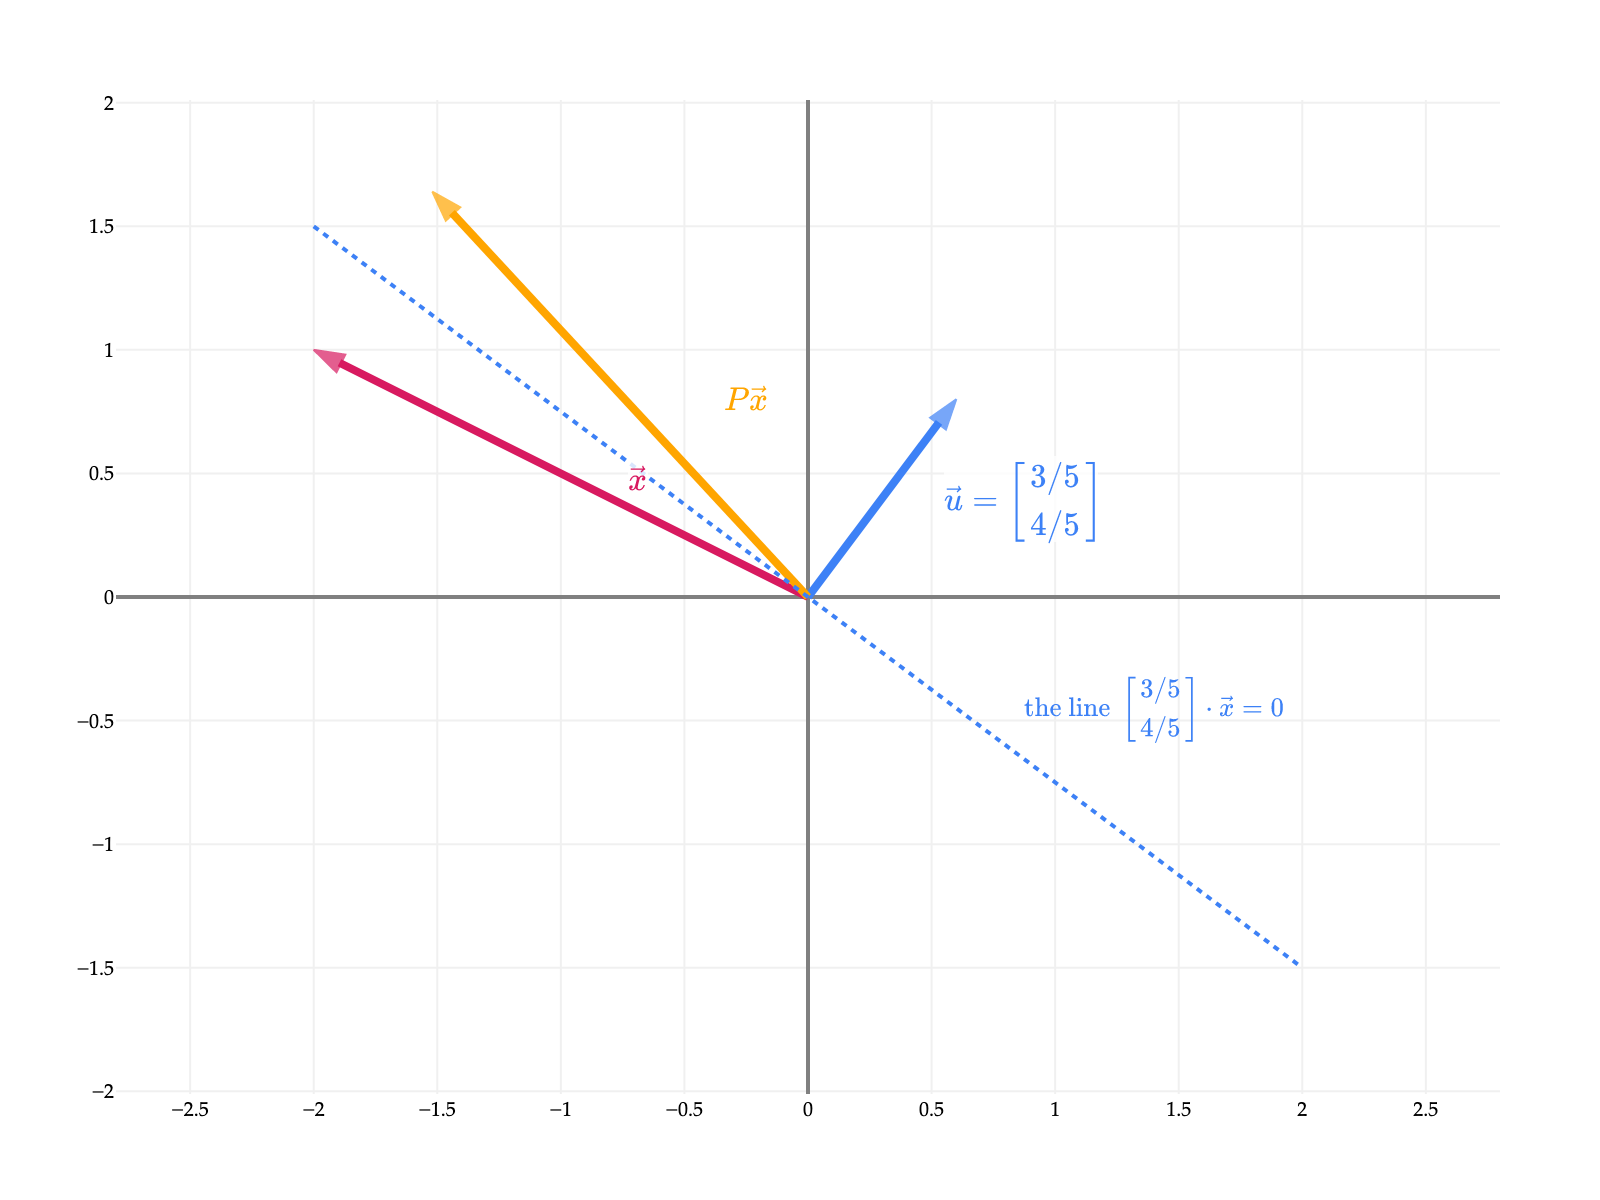

In [25]:
from utils import plot_vectors
import numpy as np

# Define normal vector (unit)
n = np.array([3 / 5, 4 / 5])

# Line normal to n: 3x + 4y = 0 (i.e., n • x = 0)
# Let's find two points on the line: choose x=-2 and x=2
# Then, 3x + 4y = 0 --> y = -(3/4)x
xs = np.array([-2, 2])
ys = -(3 / 4) * xs
line_points = np.column_stack([xs, ys])

# x and its reflection P(x)
x = np.array([-2, 1])

# Householder reflection matrix P = I - 2 n n^T
P = np.eye(2) - 2 * np.outer(n, n)
Px = P @ x

elements = [
    (tuple(n), '#3d81f6', r"$\vec u = \begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix}$"),  # Plot n (unit vector) in blue
    (tuple(x), '#d81a60', r"$\vec x$"),
    (tuple(Px), 'orange', r"$P\vec x$"),
]

fig = plot_vectors(elements, vdeltay=0, vdeltax=-0.7)

# Draw the dotted line x=y (normal to n) and label it
fig.add_trace({
    'type': 'scatter',
    'x': line_points[:, 0],
    'y': line_points[:, 1],
    'mode': 'lines',
    'line': {'color': '#3d81f6', 'dash': 'dot'},
})

# Annotate the line as "line" (at x=1.3, y=1.3)
fig.add_annotation(
    x=1.4, y=-0.5, 
    text=r"$\text{the line } \begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix} \cdot \vec x = 0$",
    showarrow=False,
    yshift=8,
    font=dict(size=13, color='#3d81f6')
)

# Adjust plot range and aspect ratio
fig.update_layout(
    xaxis=dict(range=[-2, 2], dtick=0.5),
    yaxis=dict(scaleanchor="x", range=[-2, 2], dtick=0.5),
    showlegend=False
)

fig.show(scale=2, renderer='png')


1. Show, just using the definition $P = I - 2 \vec u \vec u^T$, that $P$ is an orthogonal matrix.
1. Find $P^{-1}$. (Why does the fact that $P$ is orthogonal imply that $P$ is invertible?)

:::{seealso} Solution
:class:dropdown

1. If $P$ is orthogonal, then $P^TP = PP^T = I$. Let's start by showing that $P^TP = I$. Note that $(\vec u \vec u^T)^T = \vec u \vec u^T$.

    \begin{align*}
    P^T P &= (I - 2 \vec u \vec u^T)^T (I - 2 \vec u \vec u^T) \\
    &= (I^T - 2 (\vec u \vec u^T)^T) (I - 2 \vec u \vec u^T) \\
    &= (I - 2 (\vec u^T)^T \vec u^T) (I - 2 \vec u \vec u^T) \\
    &= (I - 2 \vec u \vec u^T) (I - 2 \vec u \vec u^T) \\
    &= I - 2 \vec u \vec u^T - 2 \vec u \vec u^T + 4 (\vec u \vec u^T) (\vec u \vec u^T) \\
    &= I - 4 \vec u \vec u^T + 4 (\vec u \vec u^T) (\vec u \vec u^T) \\
    &= I - 4 \vec u \vec u^T + 4 \vec u \underbrace{\vec u^T \vec u}_\text{unit vector!} \vec u^T \\
    & = I - 4 \vec u \vec u^T + 4 \vec u (1) \vec u^T \\
    &= I
    \end{align*}

    To be thorough, we'd need to show that $PP^T = I$, but I'll save that for you to do.

    Note that in the final step, the $-4 \vec u \vec u^T$ and $4 \vec u \vec u^T$ cancelled out. But, the $-4$ came from $-2 - 2$, while the $4$ came from $(-2) \cdot (-2)$. All of this is to say that if we changed the $-2$ to some other number in the definition of the Householder matrix, we'd no longer have $P^TP = I$, because $-2$ is the only non-zero solution to $-(c + c) = c \cdot c$.

1. Since $P$ is orthogonal, all of $P$'s columns are orthogonal, implying that they're linearly independent, meaning that $P$ is invertible. Since $P$ is orthogonal, $P^{-1} = P^T$, and above, we already showed that

    $$P^T = (I - \vec u \vec u^T)^T = I - \vec u \vec u^T = P$$

Intuitively, $P$ involves reflecting across a line, so $P^{-1} = P^T$ involves reflecting back.
:::

---

## Computing the Inverse in Code

Recall that if $A$ is an $n \times n$ matrix and $\vec b \in \mathbb{R}^n$, then 
$$A \vec x = \vec b$$

is a system of $n$ equations in $n$ unknowns. One of the big (conceptual) usages of the inverse is to solve such a system, as I mentioned at the start of this section. If $A$ is invertible, then we can solve for $\vec x$ by multiplying both sides on the left by $A^{-1}$:

$$A \vec x = \vec b \implies A^{-1} A \vec x = A^{-1} \vec b \implies \vec x = A^{-1} \vec b$$

$A^{-1}$ has encoded within it the solution to $A \vec x = \vec b$, no matter what $\vec b$ is. This makes $A^{-1}$ very powerful. But, that power doesn't come for free: in practice, finding $A^{-1}$ is **less efficient and more prone to floating point errors** than solving the **one** system of $n$ equations in $n$ unknowns directly for the specific $\vec b$ we care about. 

- Solving $A \vec x = \vec b$ involves solving just one system of $n$ equations in $n$ unknowns.
- Finding $A^{-1}$ involves solving a system of $n$ equations in $n$ unknowns, $n$ times! Each system has the same coefficient matrix $A$ but a different right-hand side $\vec b$, corresponding to the columns of the identity matrix (which are the standard basis vectors in $\mathbb{R}^n$).

The more floating point operations we need to do, the more error is introduced into the final results.

Let's run an experiment. Suppose we'd like to find the solution to the system

\begin{align*}
x_1 + x_2 &= 7 \\
x_1 + 1.000000001 x_2 &= 7.000000004
\end{align*}

This corresponds to $A \vec x = \vec b$, with

$$A = \begin{bmatrix} 1 & 1 \\ 1 & 1.000000001 \end{bmatrix}, \quad \vec b = \begin{bmatrix} 7 \\ 7.000000004 \end{bmatrix}$$

Here, we can eyeball the solution as being $\vec x = \begin{bmatrix} 3 \\ 4 \end{bmatrix}$. How close to this "true" $\vec x$ do each of the following techniques get?

**Option 1**: Using `np.linalg.inv`

As we saw at the start of the section, `np.linalg.inv(A)` finds the inverse of `A`, assuming it exists. The following cell finds the solution to $A \vec x = \vec b$ by first computing $A^{-1}$, and then $A^{-1} \vec b = \vec x$.

In [83]:
# Prevents unnecessary rounding.
np.set_printoptions(precision=16, suppress=True)

A = np.array([[1, 1],
              [1, 1.000000001]])

b = np.array([[7],
              [7.000000004]])

x_inv = np.linalg.inv(A) @ b
x_inv

array([[2.9999998807907104],
       [4.0000001192092896]])

**Option 2**: Using `np.linalg.solve`

The following cell solves the same problem as the previous cell, but rather than asking for the inverse of $A$, it asks for the solution to $A \vec x = \vec b$, which doesn't inherently require inverting $A$.

In [91]:
x_solve = np.linalg.solve(A, b)
x_solve

array([[3.],
       [4.]])

This small example already illustrates the big idea: inverting can introduce more numerical error than is necessary. If we cast the problem more abstractly, consider the matrix

$$A = \begin{bmatrix} 1 & 1 \\ 1 & 1 + \epsilon \end{bmatrix}$$

where $\epsilon$ is a small constant, e.g. $\epsilon = 0.000000001$ in the example above. The inverse of $A$ is

$$A^{-1} = \frac{1}{1(1 + \epsilon) - 1 \cdot 1} \begin{bmatrix} 1 + \epsilon & -1 \\ -1 & 1 \end{bmatrix} = \frac{1}{\epsilon} \begin{bmatrix} 1 + \epsilon & -1 \\ -1 & 1 \end{bmatrix} $$

The closer $\epsilon$ is to 0, the larger $\frac{1}{\epsilon}$ becomes, making any floating point errors all the more costly.

:::{warning} Use `np.linalg.solve` instead of `np.linalg.inv`!
Conceptually, both
`x = np.linalg.inv(A) @ b`
and
`x = np.linalg.solve(A, b)`
do the same thing, but we **much prefer** the latter.
:::